Got it. Here's a **template** you can reuse for every imputation column analysis — like `flat_on_floor`, `costpersqft`, etc.

---

### ✅ 1st: Quick Comparison — `column_name_here`

| Method            | Mean | Std Dev | Median | 75%  | Notes                                     |
| ----------------- | ---- | ------- | ------ | ---- | ----------------------------------------- |
| **Original**      | xxxx | xxxx    | xxxx   | xxxx | — Baseline                                |
| **KNN Imputed**   | xxxx | xxxx    | xxxx   | xxxx | ✅ Very close to original, preserves shape |
| **Iterative**     | xxxx | xxxx    | xxxx   | xxxx | ✅ Similar, but possible noise or shift    |
| **Mean**          | xxxx | xxxx    | xxxx   | xxxx | ⚠️ Median/shape may shift slightly        |
| **Median**        | xxxx | xxxx    | xxxx   | xxxx | ✅ Stable, generally safe                  |
| **Constant**      | xxxx | xxxx    | xxxx   | xxxx | ❌ Not reliable, distorts distribution     |
| **Most Frequent** | xxxx | xxxx    | xxxx   | xxxx | ⚠️ Redundant or risky if not categorical  |

---

### ✅ 2nd: Final Recommendation for `column_name_here`:

Use **KNN Imputation** — best preserves distribution and aligns closely with original data.

**Alternative:** Iterative or Median — both **safe** and **stable**.

🚫 **Avoid:**

* **Mean** (can distort median and flatten distribution)
* **Constant** (high risk of unrealistic values)
* **Most Frequent** (not suitable for numeric/ordinal)

👉 **Final pick:** `KNN > Iterative ≈ Median`

---

Would you like me to fill this out for your `flat_on_floor` column now?


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split



from sklearn.preprocessing import PowerTransformer, OneHotEncoder, MultiLabelBinarizer, OrdinalEncoder, MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer, MissingIndicator
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import make_column_transformer





#libraries not req in vscode
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# functions

`print the .describe() and .isna().sum() for that column`

In [2]:
def describe_and_missing(data, column_name):
    print(f"\n--- Description for '{column_name}' ---")
    print(data[column_name].describe())
    print('-'*100)
    print(f"\nMissing values in '{column_name}': {data[column_name].isna().sum()}")

`plots the KDE plot with different imputations`

In [3]:
def get_simple_imputations(data, column_name, constant_value=9999):
    col_data = data[[column_name]].astype(float)  # Ensure numeric

    mean_imputed = np.array(SimpleImputer(strategy='mean').fit_transform(col_data)).ravel()
    median_imputed = np.array(SimpleImputer(strategy='median').fit_transform(col_data)).ravel()
    most_frequent_imputed = np.array(SimpleImputer(strategy='most_frequent').fit_transform(col_data)).ravel()
    constant_imputed = np.array(SimpleImputer(strategy='constant', fill_value=constant_value).fit_transform(col_data)).ravel()

    return mean_imputed, median_imputed, most_frequent_imputed, constant_imputed

def plot_kde_imputations(data, column_name, constant_value=9999):
    original = data[column_name].dropna()
    mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(data, column_name, constant_value)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # Mean Imputation
    sns.kdeplot(original, label='Original', ax=axes[0])
    sns.kdeplot(mean_imputed, label='Mean Imputed', ax=axes[0])
    axes[0].set_title('Mean Imputation')
    axes[0].legend()

    # Median Imputation
    sns.kdeplot(original, label='Original', ax=axes[1])
    sns.kdeplot(median_imputed, label='Median Imputed', ax=axes[1])
    axes[1].set_title('Median Imputation')
    axes[1].legend()

    # Most Frequent Imputation
    sns.kdeplot(original, label='Original', ax=axes[2])
    sns.kdeplot(most_frequent_imputed, label='Most Frequent Imputed', ax=axes[2])
    axes[2].set_title('Most Frequent Imputation')
    axes[2].legend()

    # Constant Imputation
    sns.kdeplot(original, label='Original', ax=axes[3])
    sns.kdeplot(constant_imputed, label='Constant Imputed', ax=axes[3])
    axes[3].set_title('Constant Imputation')
    axes[3].legend()

    plt.suptitle(f"KDE Plots for '{column_name}' (Before and After Imputation)", fontsize=16)
    plt.tight_layout()
    plt.show()


`Visualize original vs iterative imputed values for any numeric column`

In [4]:
def plot_iterative_imputation_kde(data, column_name):
    # 1. Save original column
    original = data[column_name].copy()

    # 2. Select numeric columns
    numeric_data = data.select_dtypes(include='number').copy()

    # 3. Apply IterativeImputer
    imputer = IterativeImputer(random_state=0)
    numeric_imputed = pd.DataFrame(imputer.fit_transform(numeric_data), columns=numeric_data.columns)

    # 4. Replace the imputed column in original data
    data_iter_imputed = data.copy()
    data_iter_imputed[column_name] = numeric_imputed[column_name]

    # 5. Plot KDE
    plt.figure(figsize=(10, 6))
    sns.kdeplot(original.dropna(), label='original', color='blue')
    sns.kdeplot(data_iter_imputed[column_name], label='iterative imputed (full)', color='orange')
    plt.xlabel(column_name)
    plt.ylabel('Density')
    plt.title(f"KDE Plot: Original vs Iterative Imputed ({column_name})")
    plt.legend()
    plt.show()
    
    return original, data_iter_imputed

In [5]:
# #i am confuse in this iterative + clipping and above only iterative method 
# #so i have ask this to sir in doubt on 23-7-25 lets see 
# #so after that keep any one function from above and this one  

# def plot_iterative_imputation_kde(data, column_name):
#     # 1. Save original column
#     original = data[column_name].copy()

#     # 2. Select numeric columns
#     numeric_data = data.select_dtypes(include='number').copy()

#     # 3. Apply IterativeImputer
#     imputer = IterativeImputer(random_state=0)
#     numeric_imputed = pd.DataFrame(imputer.fit_transform(numeric_data), columns=numeric_data.columns)

#     # 4. Replace the imputed column in original data
#     data_iter_imputed = data.copy()
    
#     # 4.1 Clip the imputed column to match original min/max
#     min_val = original.min()
#     max_val = original.max()
#     clipped_column = numeric_imputed[column_name].clip(lower=min_val, upper=max_val)

#     data_iter_imputed[column_name] = clipped_column

#     # 5. Plot KDE
#     plt.figure(figsize=(10, 6))
#     sns.kdeplot(original.dropna(), label='original', color='blue')
#     sns.kdeplot(clipped_column, label='iterative imputed (clipped)', color='orange')
#     plt.xlabel(column_name)
#     plt.ylabel('Density')
#     plt.title(f"KDE Plot: Original vs Iterative Imputed ({column_name})")
#     plt.legend()
#     plt.show()
    
#     return original, data_iter_imputed


`Visualize original vs KNN imputed values for any numeric column`

In [6]:
def plot_knn_imputation_kde(data, column_name, n_neighbors=5):
    # 1. Save original column
    original = data[column_name].copy()

    # 2. Select numeric columns
    numeric_data = data.select_dtypes(include='number').copy()

    # 3. Apply KNNImputer
    imputer = KNNImputer(n_neighbors=n_neighbors)
    numeric_imputed = pd.DataFrame(imputer.fit_transform(numeric_data), columns=numeric_data.columns)

    # 4. Replace the imputed column in original data
    data_knn_imputed = data.copy()
    data_knn_imputed[column_name] = numeric_imputed[column_name]

    # 5. Plot KDE
    plt.figure(figsize=(10, 6))
    sns.kdeplot(original.dropna(), label='original', color='blue')
    sns.kdeplot(data_knn_imputed[column_name], label='knn imputed (full)', color='green')
    plt.xlabel(column_name)
    plt.ylabel('Density')
    plt.title(f"KDE Plot: Original vs KNN Imputed ({column_name})")
    plt.legend()
    plt.show()

    return original, data_knn_imputed

`categorical imputation strategies: original vs most frequent vs constant`

In [7]:
def plot_categorical_imputations(data, column_name, constant_value="missing"):
    # 1. Copy the column
    original = data[column_name].copy()

    # 2. Check shape and missing values
    print("Data shape:", data.shape)
    print(f"Missing values in '{column_name}':", original.isna().sum())

    # 3. Impute using mode (most frequent)
    mode_value = original.mode()[0]
    print("Mode:", mode_value)

    # 4. Fill missing with mode
    most_frequent_imputed = original.fillna(mode_value)

    # 5. Fill missing with constant
    constant_imputed = original.fillna(constant_value)

    # 6. Plot all
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.countplot(x=original, ax=axes[0])
    axes[0].set_title("Original")

    sns.countplot(x=most_frequent_imputed, order=original.value_counts().index, ax=axes[1])
    axes[1].set_title("Most Frequent Imputed")

    order_for_constant = list(original.dropna().value_counts().index) + [constant_value]
    sns.countplot(x=constant_imputed, order=order_for_constant, ax=axes[2])
    axes[2].set_title("Constant Imputed")

    plt.tight_layout()
    plt.show()

`target encoding with i/p option as handle missing values using target encoding or not`

In [8]:
def apply_target_encoding_train_only(X_train, y_train, columns, handle_missing_option='value'):
    encoder = TargetEncoder(cols=columns, handle_missing=handle_missing_option)
    X_encoded = encoder.fit_transform(X_train, y_train)

    return X_encoded, encoder

#use
#handle missing value using target encoder     
#X_encoded, enc = apply_target_encoding_train_only(X_train, y_train, ['project_name'], handle_missing_option='value')
    
#do not handle missing values using target encoder means return nan values as it is after target encoding     
#X_encoded, enc = apply_target_encoding_train_only(X_train, y_train, ['project_name'], handle_missing_option='return_nan')

# Building a Baseline model 

In [9]:
#Here, I used the data saved using VS Code. This data has 184 columns, which means it is the result of merging df and am_df.
df = pd.read_csv(r'C:\Users\ABC\Desktop/bhushan/property_project/files_vscode/data/py_cleaned_data.csv')

C:\Users\ABC\AppData\Local\Temp\ipykernel_6820\610101231.py:2: DtypeWarning: Columns (106,128,134,135,136,137,138,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\ABC\Desktop/bhushan/property_project/files_vscode/data/py_cleaned_data.csv')


In [10]:
df.shape

(11857, 184)

In [11]:
#except amenities col lets analyze all other col
for col in df.columns:
  if col.startswith('am'):
    continue
  print(col)

id
price
flooring
available_units
towers
construction
ownership
emi
bed
bath
parking
area
costpersqft
flat_on_floor
total_floor
lift
balcony
lattitude
longitude
project_in_acres
builder
project_name
furnish
city
location
property_type
status
extra_rooms
facing
seller
price_category
overlooking
education_mean_km
education_min_km
education_within_2km
transport_mean_km
transport_min_km
transport_within_2km
shopping_centre_mean_km
shopping_centre_min_km
shopping_centre_within_2km
commercial_hub_mean_km
commercial_hub_min_km
commercial_hub_within_2km
hospital_within_2km
tourist_within_2km
overall_min_mean_km
overall_avg_mean_km
overall_min_min_km
overall_avg_min_km
total_within_2km


In [12]:
# drop columns not required for model input 
columns_to_drop = ['id','price_category']

df.drop(columns = columns_to_drop , inplace = True)
df.head()

,price,flooring,available_units,towers,am_12204,am_12226,am_12225,am_12229,am_12230,am_1404107,...,commercial_hub_mean_km,commercial_hub_min_km,commercial_hub_within_2km,hospital_within_2km,tourist_within_2km,overall_min_mean_km,overall_avg_mean_km,overall_min_min_km,overall_avg_min_km,total_within_2km
0,1.80,vitrified,1512.0,10.0,club house,cafeteria/food court,bar/lounge,jogging and strolling track,outdoor tennis courts,barbeque pit,...,NaN,NaN,0,0,0,1.833333,3.044444,1.2,2.100000,2
1,2.37,"vitrified, wooden, ceramic tiles",810.0,6.0,club house,cafeteria/food court,bar/lounge,jogging and strolling track,outdoor tennis courts,barbeque pit,...,6.0,2.3,0,0,0,2.760000,3.980000,1.1,1.900000,2
2,1.80,NaN,412.0,2.0,NaN,NaN,NaN,jogging and strolling track,NaN,barbeque pit,...,18.5,18.4,0,0,0,5.380000,10.417917,0.2,4.900000,8
3,1.64,vitrified,339.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,NaN,NaN,NaN,NaN,0
4,1.26,vitrified,174.0,1.0,club house,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0,0,0,1.200000,2.370000,1.2,1.566667,4


In [13]:
# combine all amenities and make one column
# Step 1: Filter columns that start with 'am_'
am_cols = [col for col in df.columns if col.startswith('am_')]

# Step 2: Combine values row-wise into a comma-separated string (not a list)
df['amenities'] = df[am_cols].apply(
    lambda row: ', '.join([str(val).strip() for val in row if isinstance(val, str) and val.strip() != ""]),
    axis=1
)

In [14]:
# Step 3: Drop original 'am_' columns
df.drop(columns=am_cols, inplace=True)

In [15]:
df['amenities'].head()

0    club house, cafeteria/food court, bar/lounge, ...
1    club house, cafeteria/food court, bar/lounge, ...
2    jogging and strolling track, barbeque pit, lif...
3    power back up, swimming pool, lift, security, ...
4    club house, swimming pool, banquet hall, gymna...
Name: amenities, dtype: object

In [16]:
# check for missing values 

df.isna().sum()

price                            0
flooring                      4430
available_units               5198
towers                        5005
construction                  1048
ownership                     3590
emi                              2
bed                              0
bath                            30
parking                       6152
area                             5
costpersqft                      6
flat_on_floor                 2287
total_floor                   2054
lift                          5419
balcony                       5801
lattitude                      464
longitude                      464
project_in_acres              5730
builder                       4255
project_name                  3479
furnish                         39
city                             0
location                       481
property_type                    2
status                          82
extra_rooms                   5275
facing                        3716
seller              

In [17]:
df.duplicated().sum()

224

`observation`
- after dreopping id column got 224 duplicate rows

In [18]:
#drop duplicate rows 
df.drop_duplicates(inplace=True)

<Axes: >

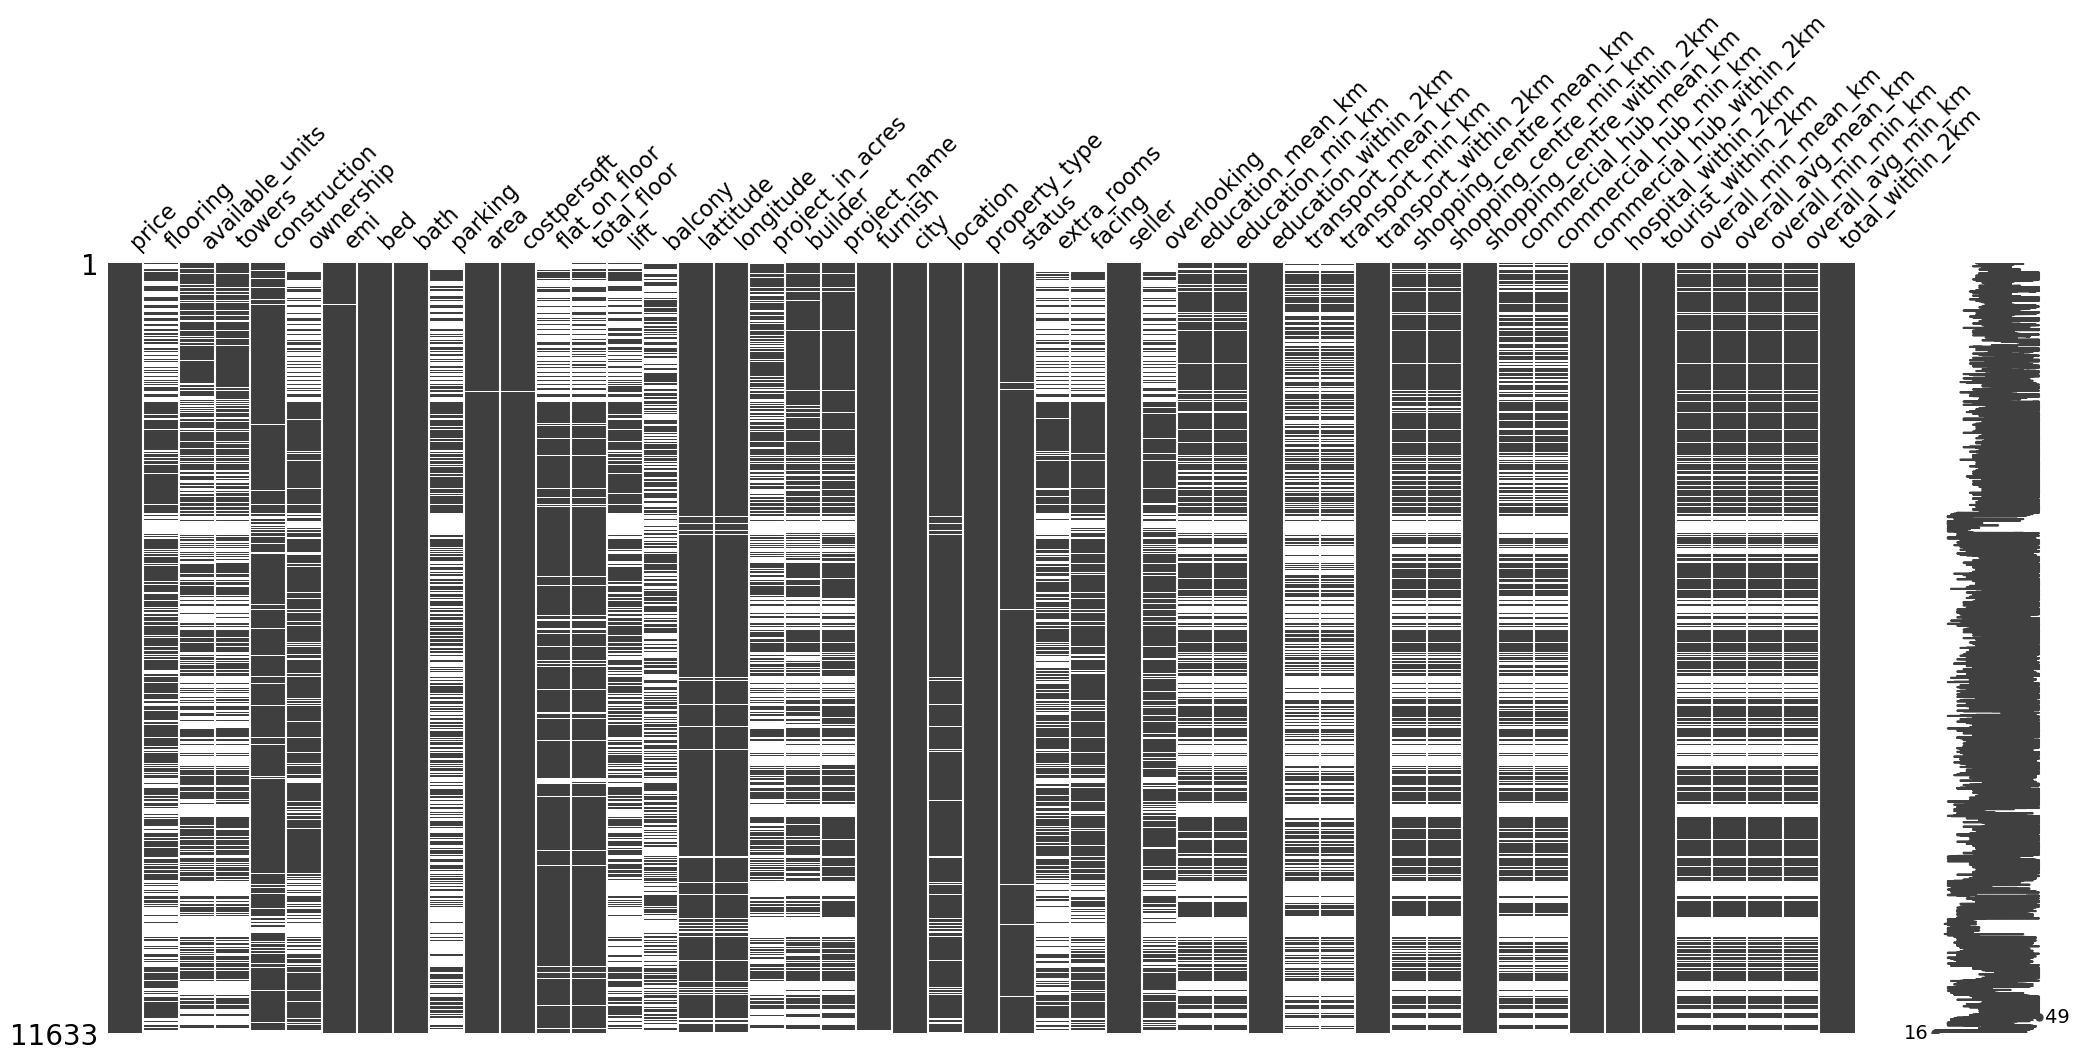

In [19]:
cols_to_check = [col for col in df.columns if not col.startswith('am')]
msno.matrix(df[cols_to_check])

In [20]:
# columns that have missing values

missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['flooring', 'available_units', 'towers', 'construction', 'ownership',
       'emi', 'bath', 'parking', 'area', 'costpersqft', 'flat_on_floor',
       'total_floor', 'lift', 'balcony', 'lattitude', 'longitude',
       'project_in_acres', 'builder', 'project_name', 'furnish', 'location',
       'property_type', 'status', 'extra_rooms', 'facing', 'overlooking',
       'education_mean_km', 'education_min_km', 'transport_mean_km',
       'transport_min_km', 'shopping_centre_mean_km', 'shopping_centre_min_km',
       'commercial_hub_mean_km', 'commercial_hub_min_km',
       'overall_min_mean_km', 'overall_avg_mean_km', 'overall_min_min_km',
       'overall_avg_min_km'],
      dtype='object')

# Data preparation 

In [21]:
temp_df = df.copy()

In [22]:
# split data 

X = temp_df.drop(columns = 'price')
y = temp_df['price']

In [23]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (9306, 49)
The shape of test data is (2327, 49)


`lets categorized the columns`

In [25]:
num_nominal_cols = ['project_in_acres','lattitude','longitude','area','costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km', 'transport_min_km',
                    'shopping_centre_mean_km', 'shopping_centre_min_km','commercial_hub_mean_km', 'commercial_hub_min_km','overall_min_mean_km', 'overall_avg_mean_km',
                    'overall_min_min_km', 'overall_avg_min_km','available_units','towers']

num_ordinal_cols = ['flat_on_floor','total_floor','bed','bath','balcony','lift','parking','education_within_2km','transport_within_2km','shopping_centre_within_2km',
                    'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

nominal_cat_cols = ['builder','project_name','location','city','property_type','ownership','overlooking','facing','flooring','extra_rooms','seller']

ordinal_cat_cols = ['status','construction','furnish']

#there are amenities columns also which starts from am


#status : 'under construction < ongoing < ready to move'
#construction : 'under construction → new construction → less than 5 years → 5 to 10 years → 10 to 15 years → 15 to 20 years → above 20 years'
#furnish : 'unfurnished < semi-furnished < furnished'

In [26]:
len(num_nominal_cols + num_ordinal_cols + nominal_cat_cols + ordinal_cat_cols)

48

In [27]:
df.shape

(11633, 50)

# Transform Target column

In [28]:
pt = PowerTransformer(method='yeo-johnson')
y_train_trans = pd.Series(
    pt.fit_transform(y_train.values.reshape(-1, 1)).ravel(),
    index=y_train.index
)
y_test_trans = pd.Series(
    pt.transform(y_test.values.reshape(-1, 1)).ravel(),
    index=y_test.index
)

In [29]:
missing_cols

Index(['flooring', 'available_units', 'towers', 'construction', 'ownership',
       'emi', 'bath', 'parking', 'area', 'costpersqft', 'flat_on_floor',
       'total_floor', 'lift', 'balcony', 'lattitude', 'longitude',
       'project_in_acres', 'builder', 'project_name', 'furnish', 'location',
       'property_type', 'status', 'extra_rooms', 'facing', 'overlooking',
       'education_mean_km', 'education_min_km', 'transport_mean_km',
       'transport_min_km', 'shopping_centre_mean_km', 'shopping_centre_min_km',
       'commercial_hub_mean_km', 'commercial_hub_min_km',
       'overall_min_mean_km', 'overall_avg_mean_km', 'overall_min_min_km',
       'overall_avg_min_km'],
      dtype='object')

In [30]:
# percentage of rows in data having missing values

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)


92.0

We are going to perform different experiments:

* **Experiment 1:** In this experiment, we are **not grouping rare categories** for any of the columns.

* **Experiment 2:** In this experiment, we are **grouping rare categories** in the relevant columns.


In [31]:
#o/p in daraframe
from sklearn import set_config
set_config(transform_output="pandas")

# Missing value Imputation 

## Analysis on num_nominal_cols

In [31]:
num_nominal_cols = ['project_in_acres','lattitude','longitude','area','costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km', 'transport_min_km',
                    'shopping_centre_mean_km', 'shopping_centre_min_km','commercial_hub_mean_km', 'commercial_hub_min_km','overall_min_mean_km', 'overall_avg_mean_km',
                    'overall_min_min_km', 'overall_avg_min_km','available_units','towers']

### project_in_acres

In [32]:
describe_and_missing(X_train, 'project_in_acres')


--- Description for 'project_in_acres' ---
count    4729.000000
mean       16.525708
std       127.551735
min         0.000000
25%         1.000000
50%         3.000000
75%         8.000000
max      4500.000000
Name: project_in_acres, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'project_in_acres': 4577


`observation`
- mean and median values are not similar still lets impute using simple imputer and check kdeplot
- missing values 4577

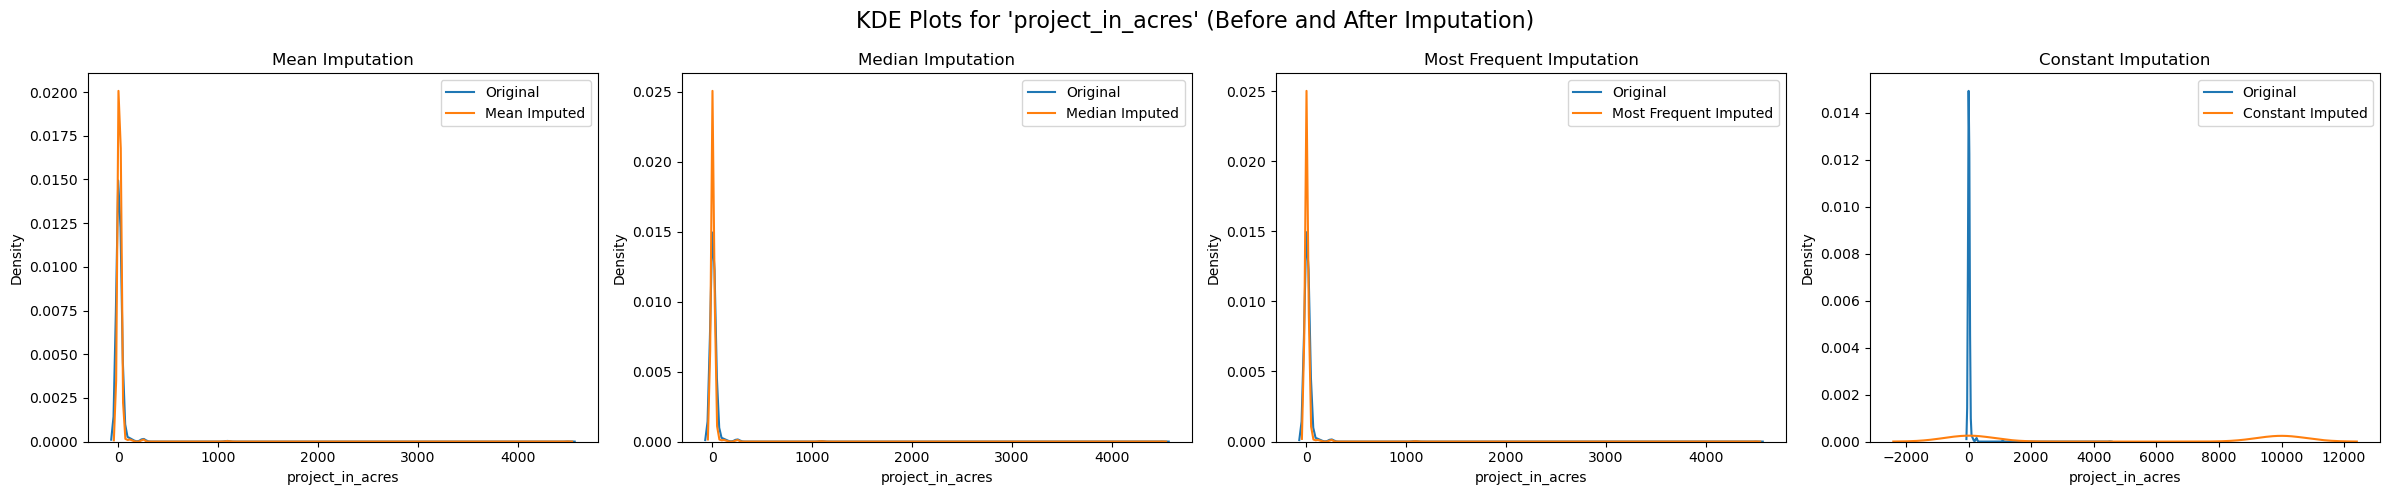

In [33]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'project_in_acres', constant_value=9999)
plot_kde_imputations(X_train, 'project_in_acres')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


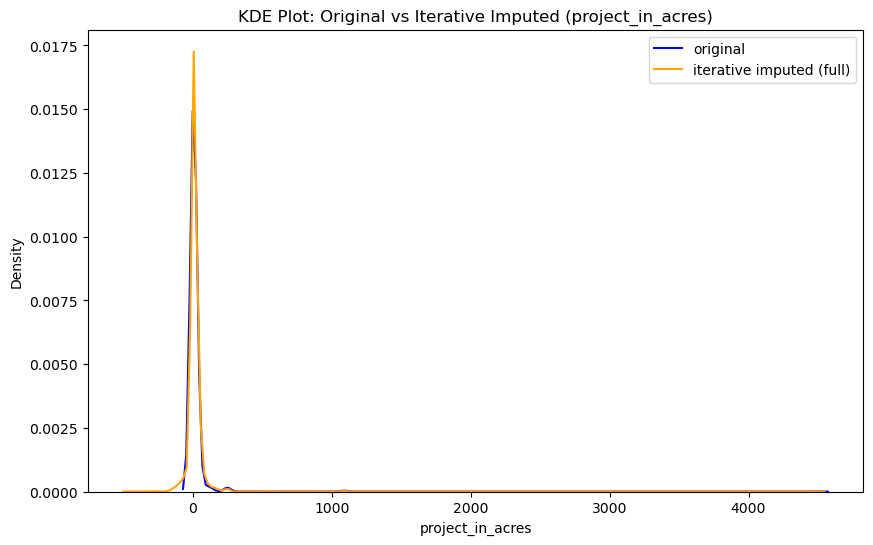

In [34]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'project_in_acres')

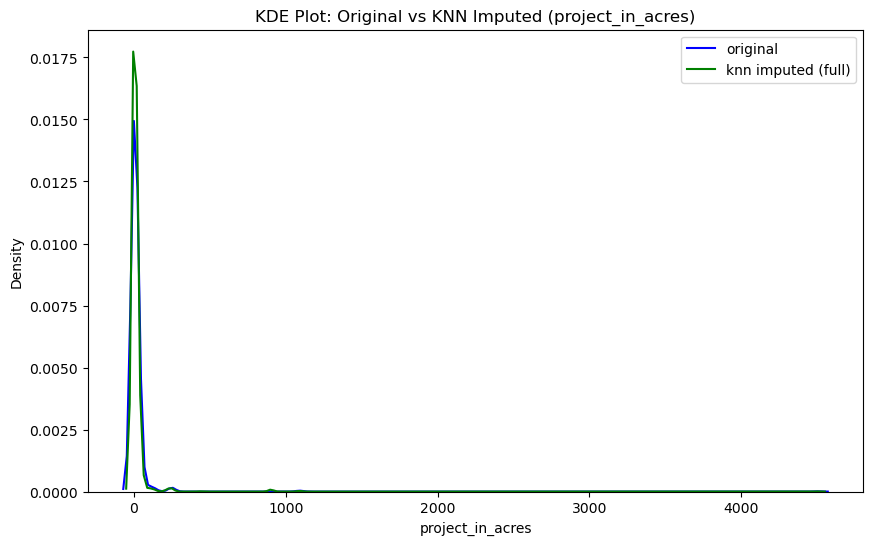

In [35]:
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'project_in_acres')

In [36]:
print("Original:\n", X_train['project_in_acres'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['project_in_acres'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['project_in_acres'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    4729.000000
mean       16.525708
std       127.551735
min         0.000000
25%         1.000000
50%         3.000000
75%         8.000000
max      4500.000000
Name: project_in_acres, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       16.089347
std       106.173291
min         0.000000
25%         2.000000
50%         4.000000
75%         8.009100
max      4500.000000
Name: project_in_acres, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       15.218447
std        98.156755
min      -453.209717
25%         1.000000
50%         6.000000
75%        22.000000
max      4500.000000
Name: project_in_acres, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       16.525708
std        90.921568
min         0.000000
25%         3.000000
50%        16.525708
75%        16.525708
max      4500.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        9.873316
std        91.172696
min         0.000000
25%         3.000000
50%   

`observation`

- KNN imputation is more reliable here.
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

In [37]:
# Apply KNN imputer
imputer = KNNImputer(n_neighbors=5)
X_train_acres_imputed = imputer.fit_transform(X_train[['project_in_acres']])

# 3. Replace original column
X_train['project_in_acres'] = X_train_acres_imputed

In [38]:
X_train['project_in_acres'].isna().sum()

0

### lattitude

In [39]:
describe_and_missing(X_train, 'lattitude')


--- Description for 'lattitude' ---
count    8935.000000
mean       19.146099
std         0.118896
min        18.795002
25%        19.062055
50%        19.143622
75%        19.210299
max        19.832738
Name: lattitude, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'lattitude': 371


`observation`
- mean and median values are almost similar lets impute using simple imputer and check kdeplot

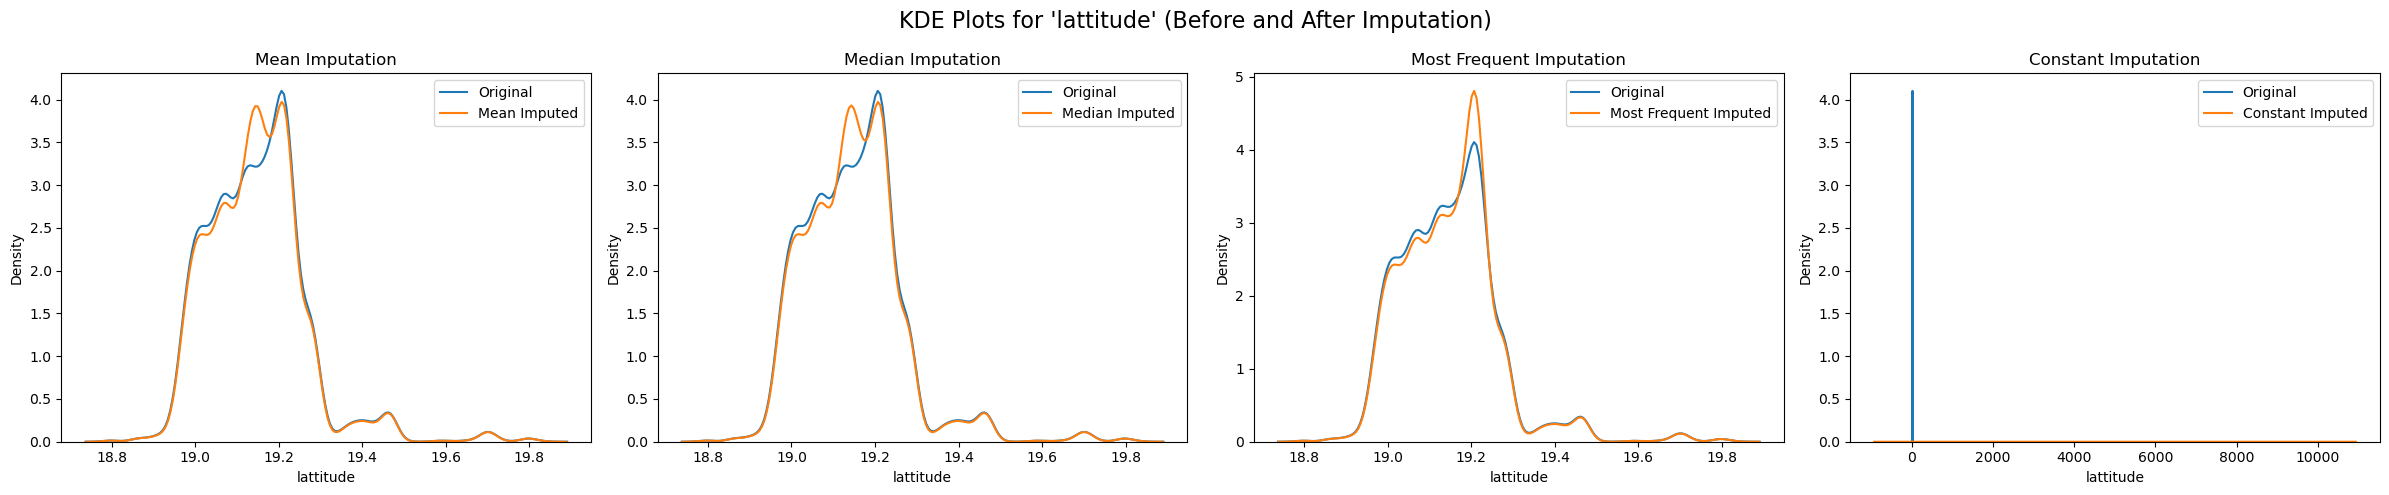

In [40]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'lattitude', constant_value=9999)
plot_kde_imputations(X_train, 'lattitude')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


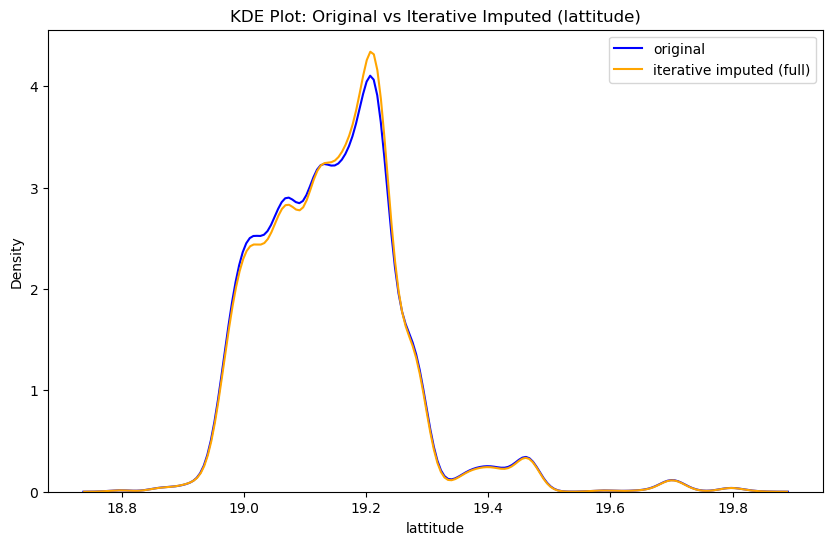

In [41]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'lattitude')

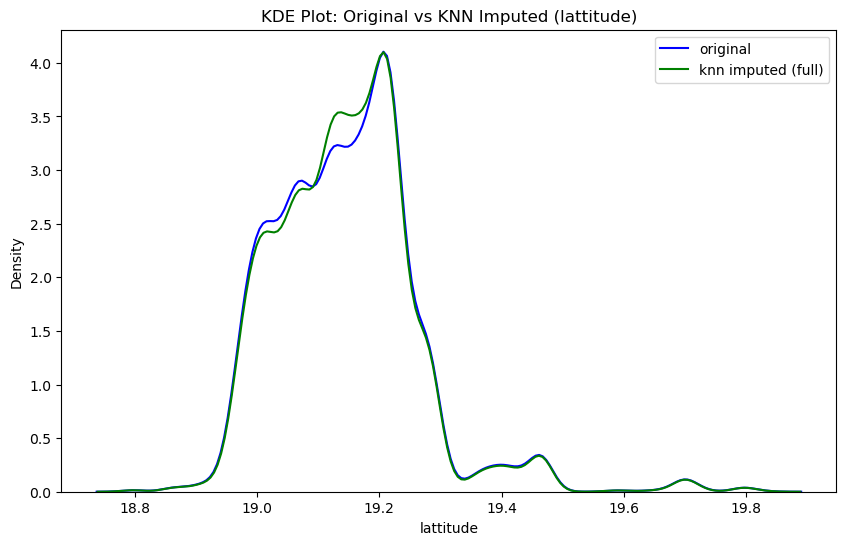

In [42]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'lattitude')

In [43]:
print("Original:\n", X_train['lattitude'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['lattitude'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['lattitude'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    8935.000000
mean       19.146099
std         0.118896
min        18.795002
25%        19.062055
50%        19.143622
75%        19.210299
max        19.832738
Name: lattitude, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       19.146334
std         0.116719
min        18.795002
25%        19.065672
50%        19.143882
75%        19.210131
max        19.832738
Name: lattitude, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       19.147510
std         0.117200
min        18.795002
25%        19.063918
50%        19.148366
75%        19.211267
max        19.832738
Name: lattitude, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       19.146099
std         0.116502
min        18.795002
25%        19.065672
50%        19.146099
75%        19.210131
max        19.832738
dtype: float64 

Median Imputed:
 count    9306.000000
mean       19.146001
std         0.116503
min        18.795002
25%        19.065672
50%        19.143622
75%   

`observation`

- both works almost same but iterative is slightly better than KNN 
- Try different max_iter and imputation_order': ['ascending', 'descending', 'roman', 'arabic'] and estimator': [BayesianRidge(), ExtraTreesRegressor(n_estimators=50, random_state=0), RandomForestRegressor(random_state=0)] to further improve iterative results.

### longitude

In [44]:
describe_and_missing(X_train, 'longitude')


--- Description for 'longitude' ---
count    8935.000000
mean       72.905286
std         0.086000
min        72.704548
25%        72.839809
50%        72.872695
75%        72.963282
max        73.337269
Name: longitude, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'longitude': 371


`observation`
- mean and median values are almost similar lets impute using simple imputer and check kdeplot

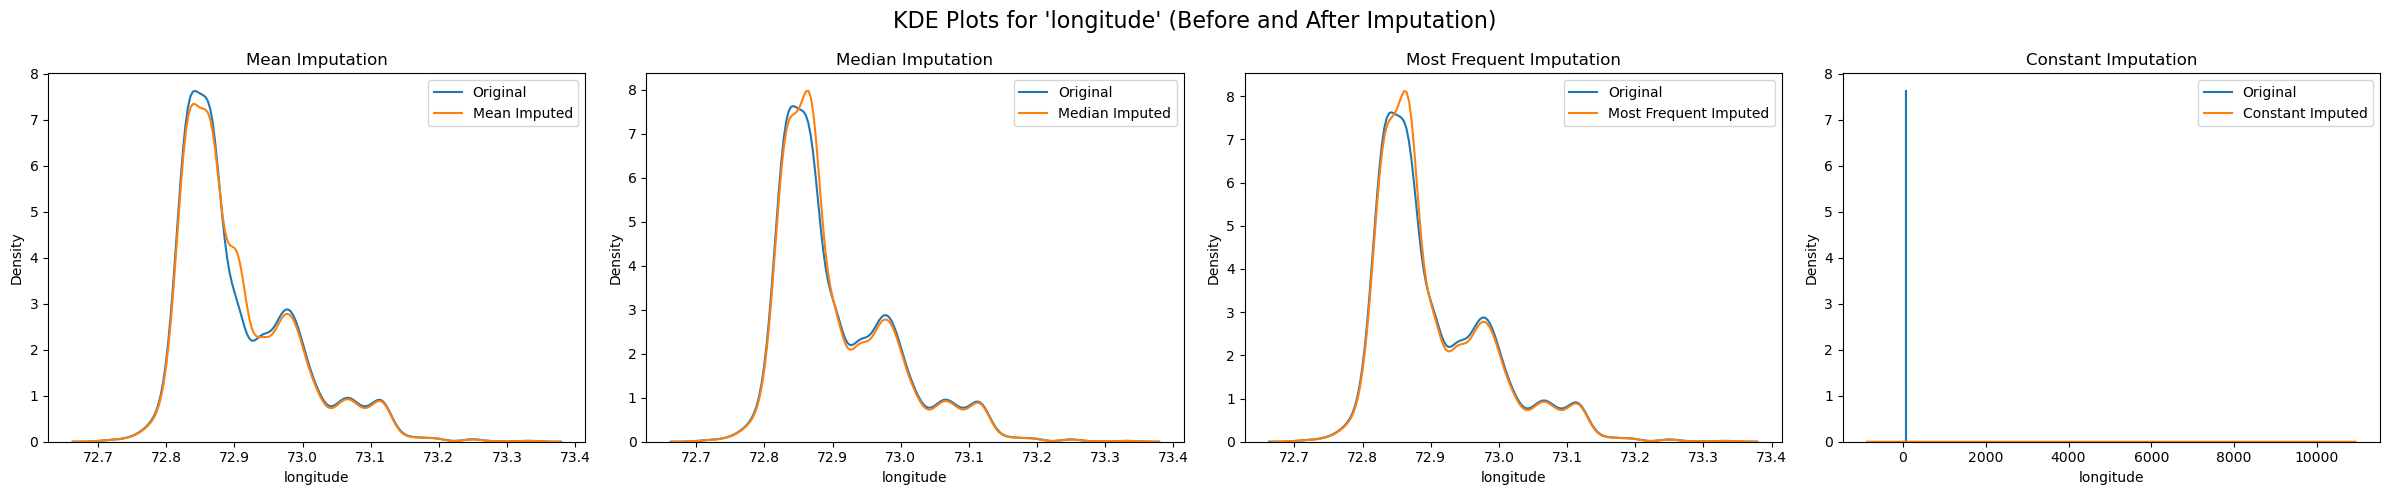

In [45]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'longitude', constant_value=9999)
plot_kde_imputations(X_train, 'longitude')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


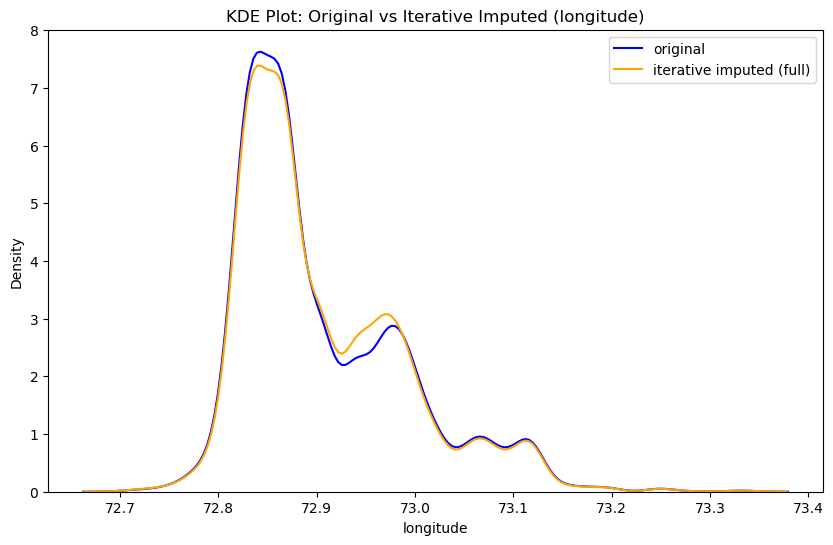

In [46]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'longitude')

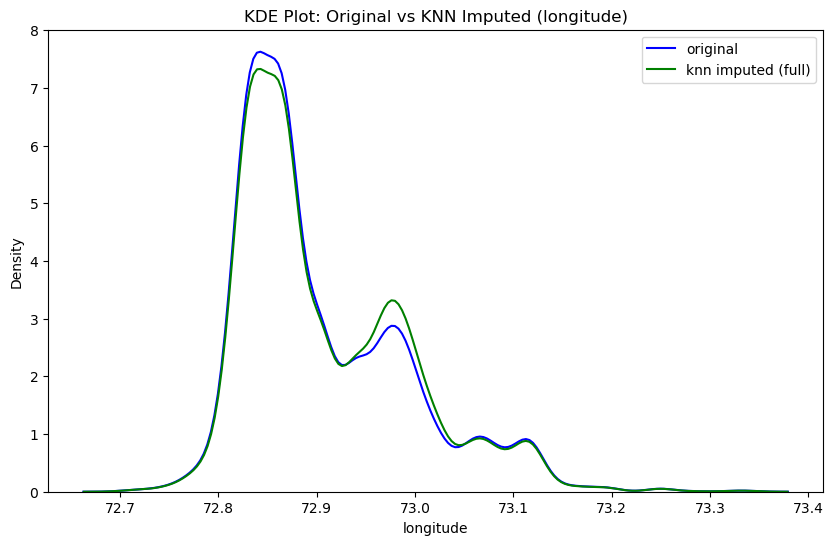

In [47]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'longitude')

In [48]:
print("Original:\n", X_train['longitude'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['longitude'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['longitude'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    8935.000000
mean       72.905286
std         0.086000
min        72.704548
25%        72.839809
50%        72.872695
75%        72.963282
max        73.337269
Name: longitude, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       72.908378
std         0.085793
min        72.704548
25%        72.839809
50%        72.873618
75%        72.968923
max        73.337269
Name: longitude, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       72.906250
std         0.084784
min        72.704548
25%        72.839809
50%        72.873618
75%        72.963171
max        73.337269
Name: longitude, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       72.905286
std         0.084268
min        72.704548
25%        72.839809
50%        72.873618
75%        72.959958
max        73.337269
dtype: float64 

Median Imputed:
 count    9306.000000
mean       72.903987
std         0.084509
min        72.704548
25%        72.839809
50%        72.872695
75%   

`observation`

- both works almost same but iterative is slightly better than KNN  
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### area

In [49]:
describe_and_missing(X_train, 'area')


--- Description for 'area' ---
count     9302.000000
mean       876.107289
std        580.371129
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
Name: area, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'area': 4


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

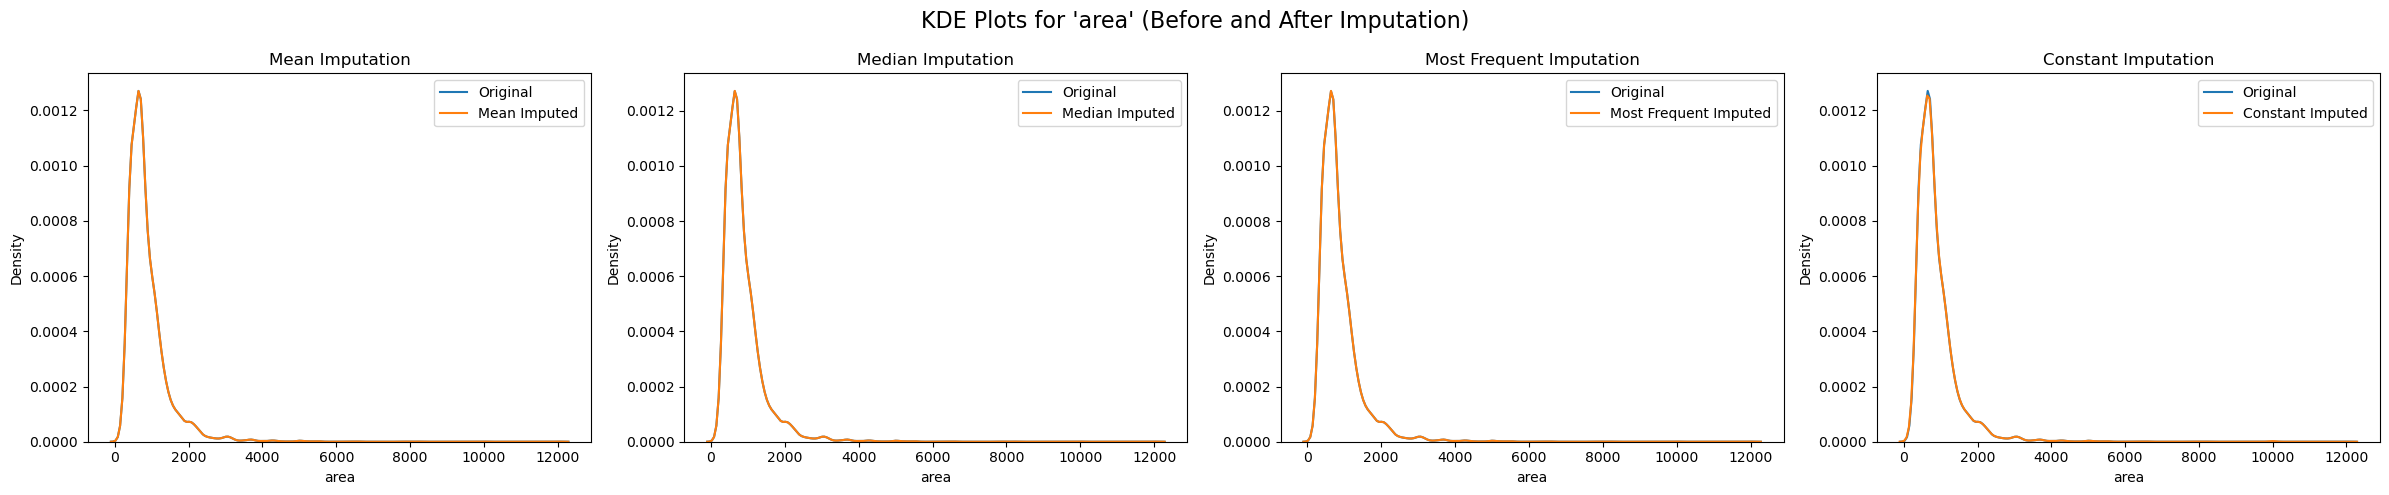

In [50]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'area', constant_value=9999)
plot_kde_imputations(X_train, 'area')

`observation`
- After imputation distribution not change as have very less values in data 
- Still lets use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


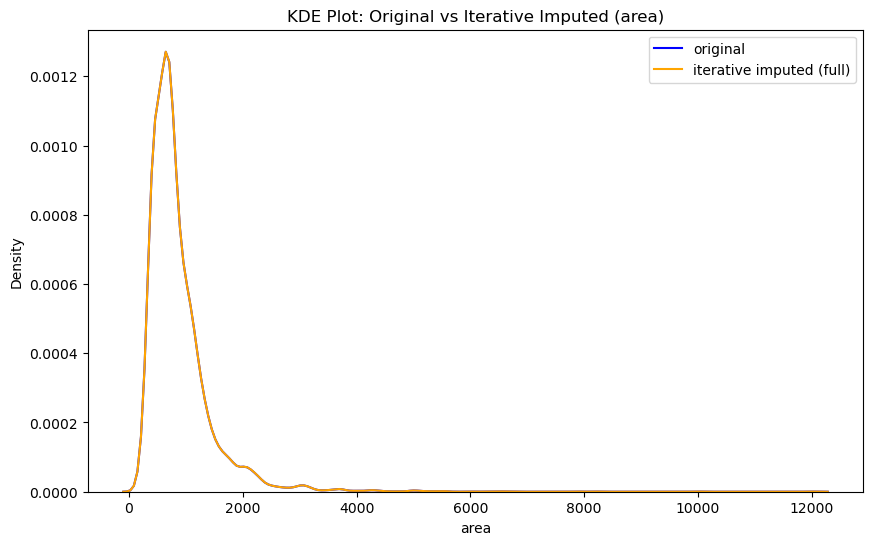

In [51]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'area')

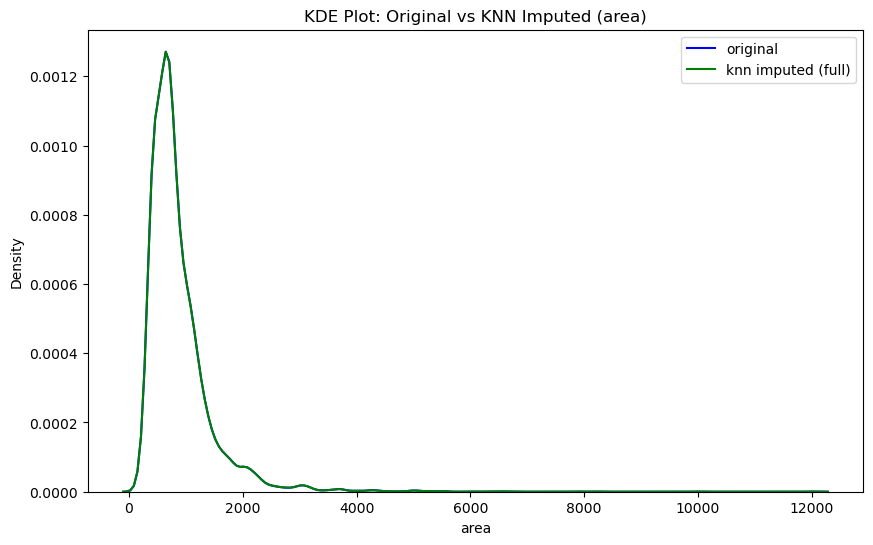

In [52]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'area')

In [53]:
print("Original:\n", X_train['area'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['area'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['area'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count     9302.000000
mean       876.107289
std        580.371129
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
Name: area, dtype: float64 

KNN Imputed:
 count     9306.000000
mean       876.212315
std        580.537012
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
Name: area, dtype: float64 

Iterative Imputed:
 count     9306.000000
mean       876.185713
std        580.425224
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
Name: area, dtype: float64 

Mean Imputed:
 count     9306.000000
mean       876.107289
std        580.246372
min        180.000000
25%        540.000000
50%        730.000000
75%       1040.000000
max      12000.000000
dtype: float64 

Median Imputed:
 count     9306.000000
mean       876.044487
std        580.254276
min        180.000000
25%        540.000000
50%  

`observation`

- both works almost same but KNN is slightly better than iterative- 
Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### costpersqft

In [54]:
describe_and_missing(X_train, 'costpersqft')


--- Description for 'costpersqft' ---
count      9301.000000
mean      27802.121748
std       16004.552857
min         289.000000
25%       16875.000000
50%       25556.000000
75%       34392.000000
max      138889.000000
Name: costpersqft, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'costpersqft': 5


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

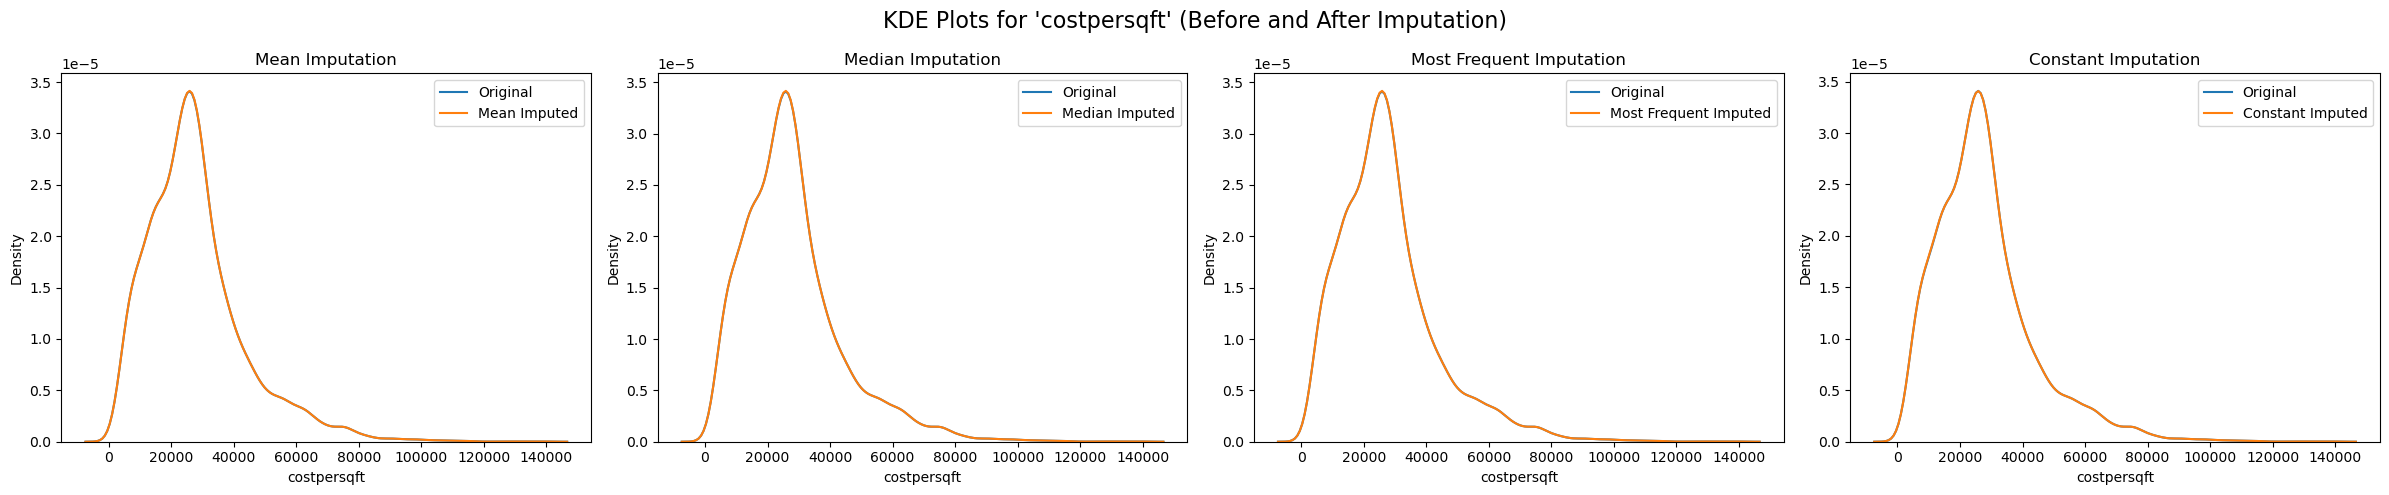

In [55]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'costpersqft', constant_value=9999)
plot_kde_imputations(X_train, 'costpersqft')

`observation`
- After imputation distribution remanin same as have very less values in data
- lets use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


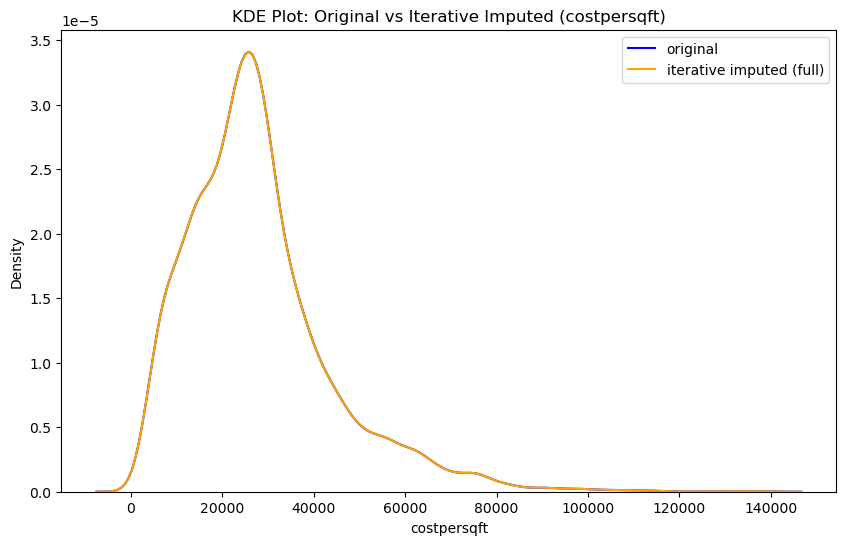

In [56]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'costpersqft')

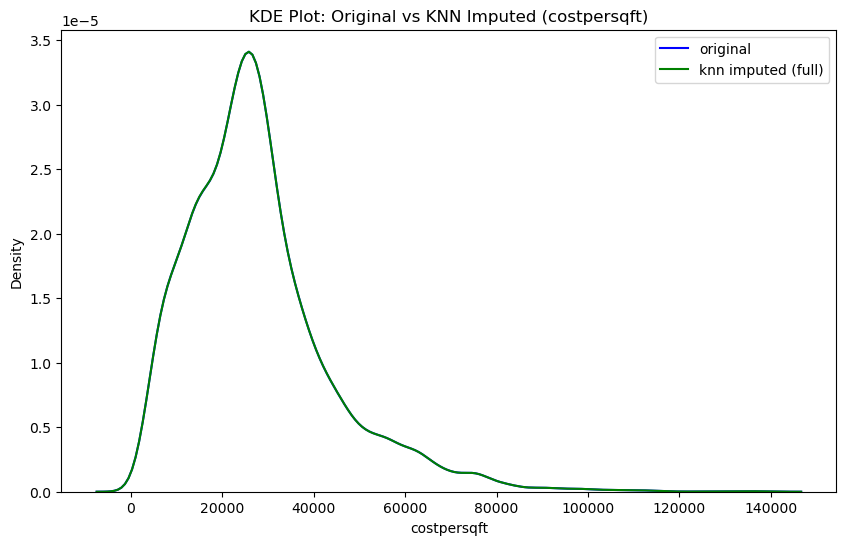

In [57]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'costpersqft')

In [58]:
print("Original:\n", X_train['costpersqft'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['costpersqft'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['costpersqft'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count      9301.000000
mean      27802.121748
std       16004.552857
min         289.000000
25%       16875.000000
50%       25556.000000
75%       34392.000000
max      138889.000000
Name: costpersqft, dtype: float64 

KNN Imputed:
 count      9306.000000
mean      27800.281236
std       16002.385511
min         289.000000
25%       16869.000000
50%       25556.000000
75%       34390.000000
max      138889.000000
Name: costpersqft, dtype: float64 

Iterative Imputed:
 count      9306.000000
mean      27798.880153
std       16004.796477
min         289.000000
25%       16867.000000
50%       25556.000000
75%       34390.000000
max      138889.000000
Name: costpersqft, dtype: float64 

Mean Imputed:
 count      9306.000000
mean      27802.121748
std       16000.252292
min         289.000000
25%       16875.000000
50%       25558.500000
75%       34383.750000
max      138889.000000
dtype: float64 

Median Imputed:
 count      9306.000000
mean      27800.914934
std       16000.

`observation`

- both works almost same but KNN is slightly better than iterative
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### emi

In [59]:
describe_and_missing(X_train, 'emi')


--- Description for 'emi' ---
count    9304.000000
mean        1.321022
std         1.917678
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
Name: emi, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'emi': 2


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

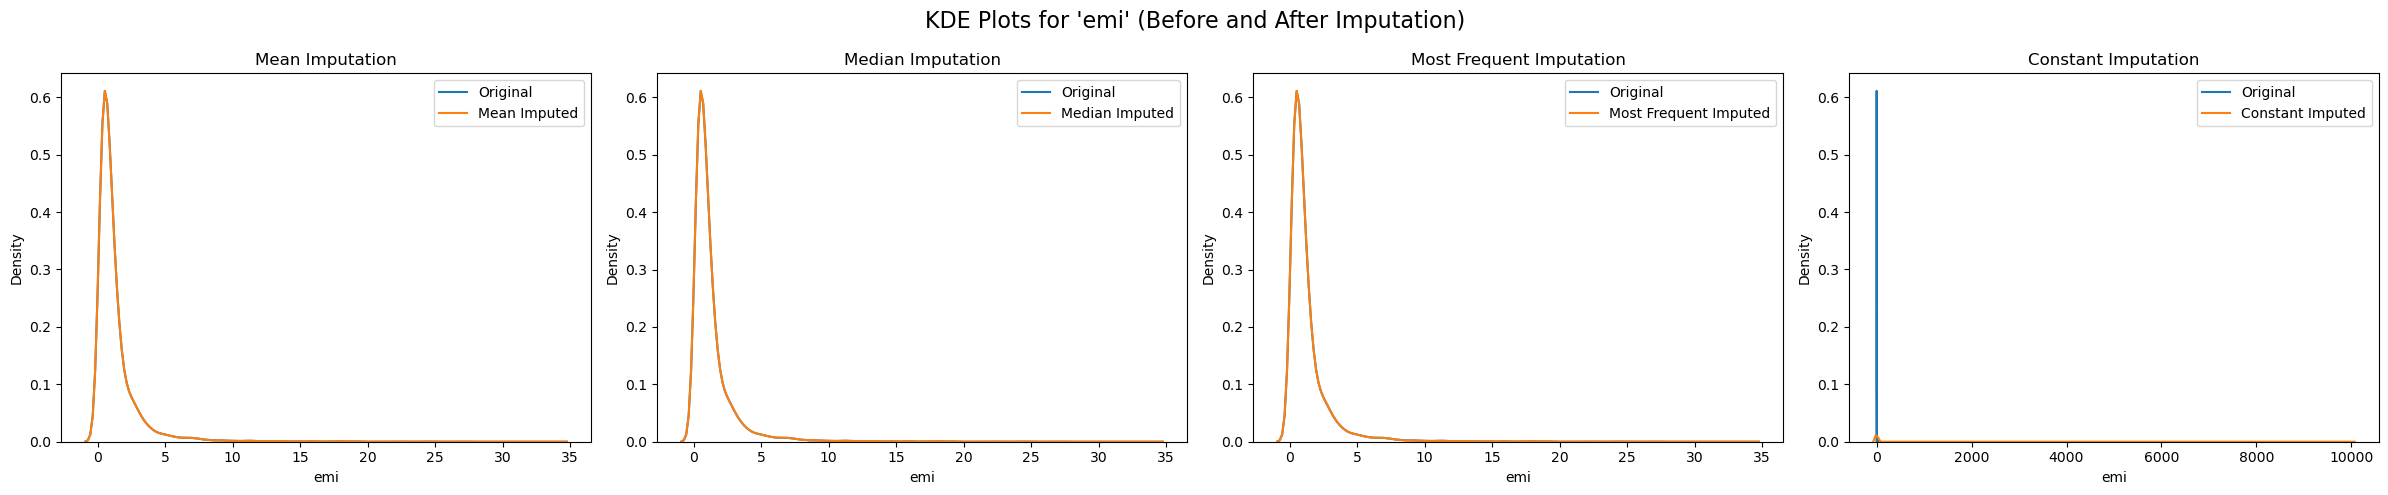

In [60]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'emi', constant_value=9999)
plot_kde_imputations(X_train, 'emi')

`observation`
- After imputation distribution remain same as have very less values in data 
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


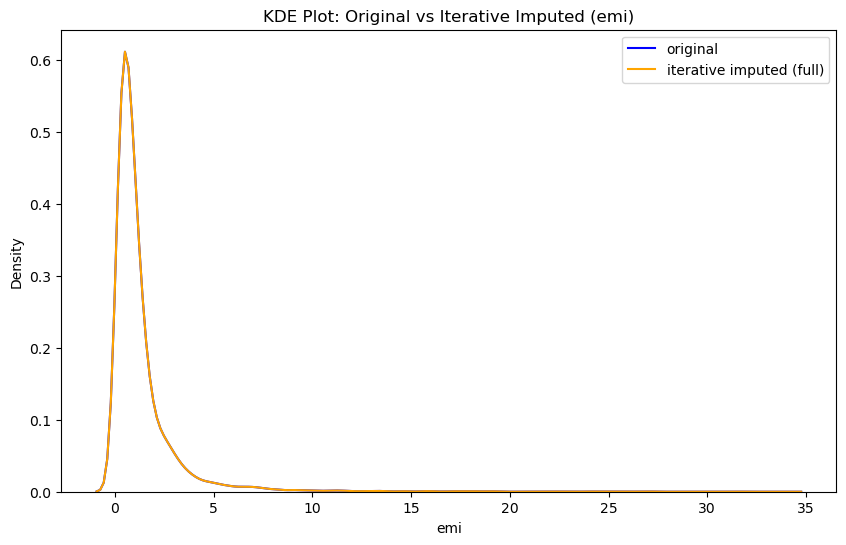

In [61]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'emi')

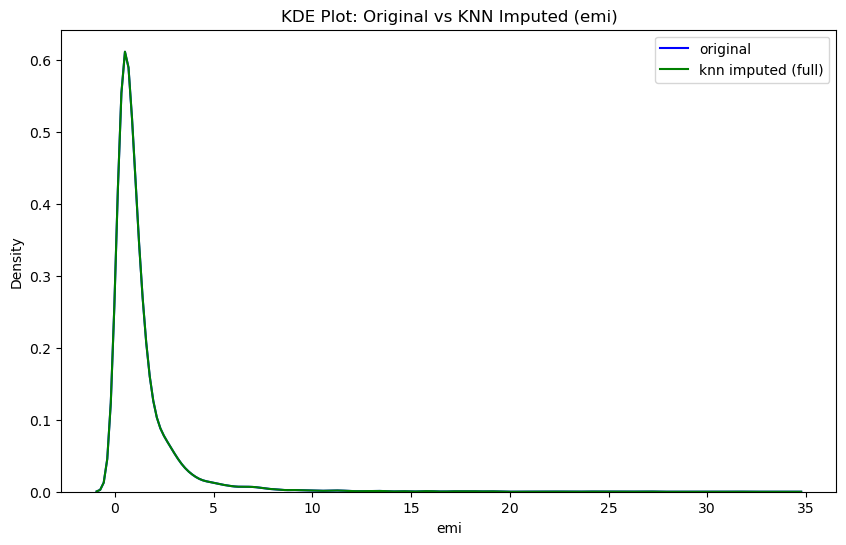

In [62]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'emi')

In [63]:
print("Original:\n", X_train['emi'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['emi'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['emi'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    9304.000000
mean        1.321022
std         1.917678
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
Name: emi, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.320901
std         1.917495
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
Name: emi, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        1.320896
std         1.917500
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
Name: emi, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        1.321022
std         1.917472
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max        33.830000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.320910
std         1.917487
min         0.007450
25%         0.430000
50%         0.800000
75%         1.440000
max

`observation`

- mean, iterative and KNN works almost same but KNN is slightly better than others
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### education_mean_km

In [64]:
describe_and_missing(X_train, 'education_mean_km')


--- Description for 'education_mean_km' ---
count    5922.000000
mean        7.901789
std        14.835780
min         0.100000
25%         1.740000
50%         3.040000
75%         5.050000
max        66.350000
Name: education_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'education_mean_km': 3384


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

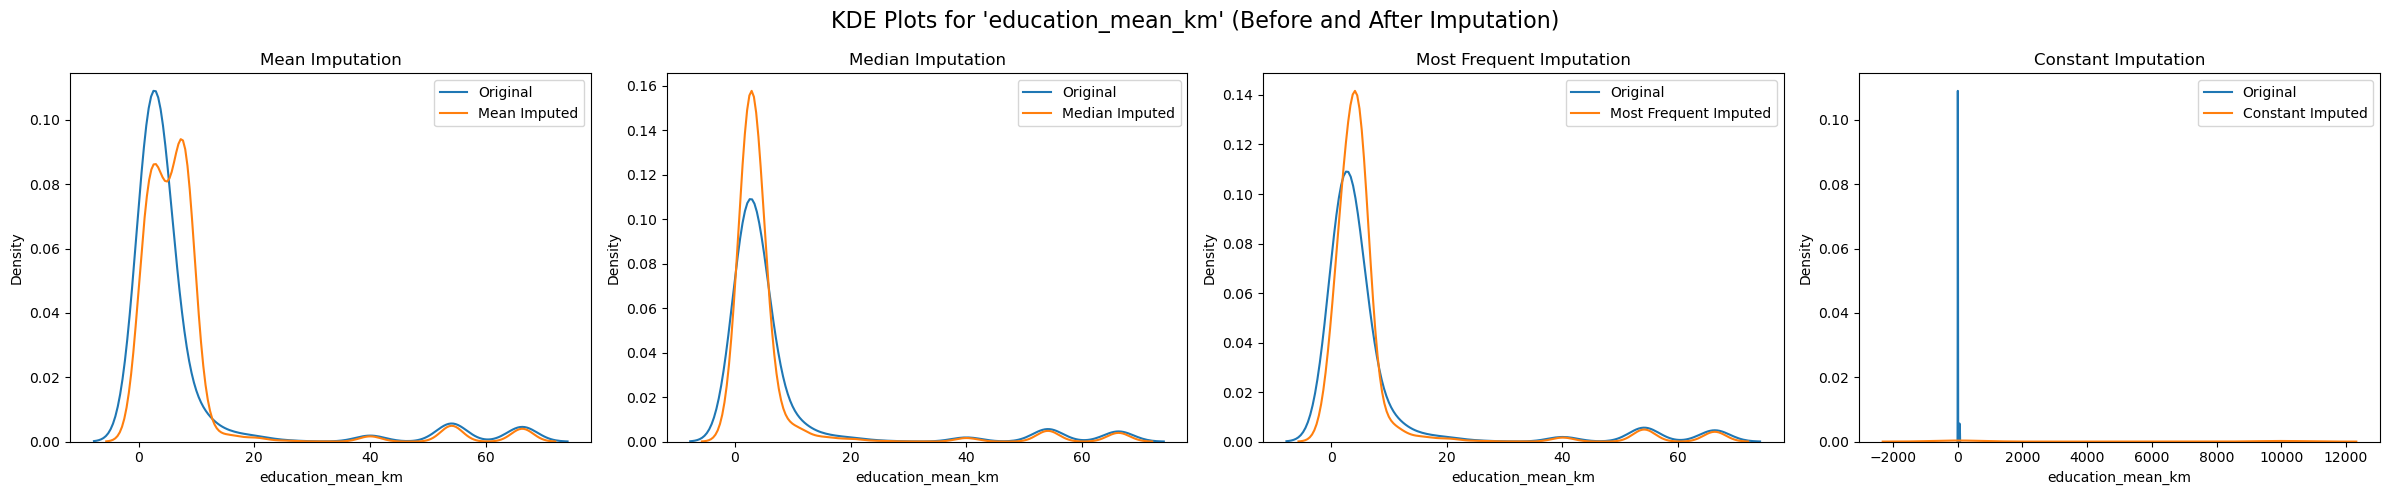

In [65]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'education_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'education_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


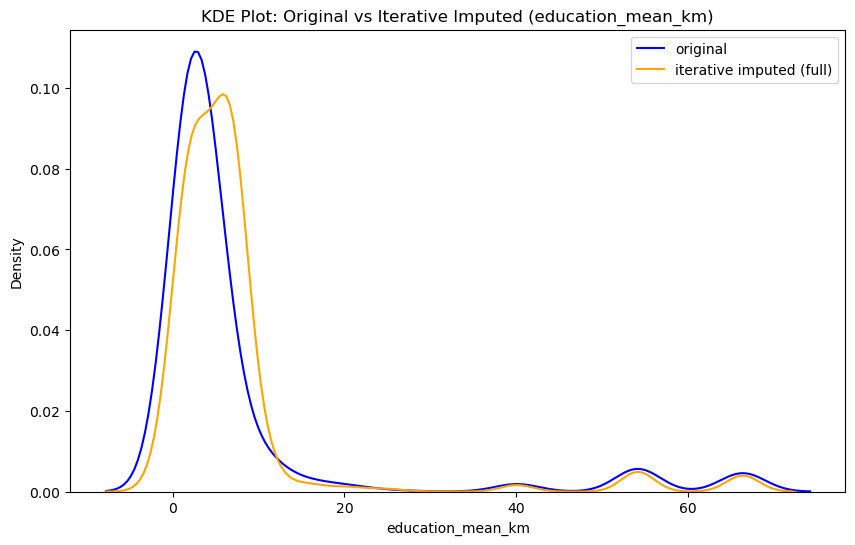

In [66]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'education_mean_km')

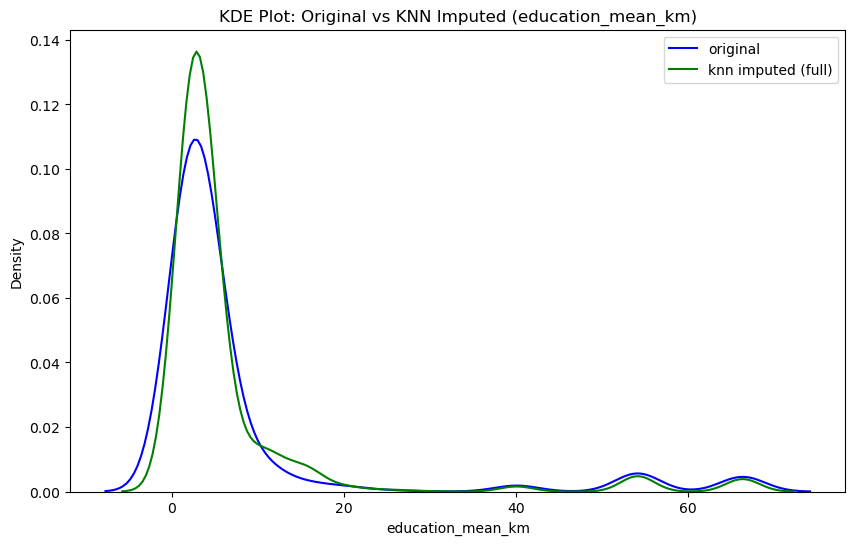

In [67]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'education_mean_km')

In [68]:
print("Original:\n", X_train['education_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['education_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['education_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5922.000000
mean        7.901789
std        14.835780
min         0.100000
25%         1.740000
50%         3.040000
75%         5.050000
max        66.350000
Name: education_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        6.916881
std        12.192428
min         0.100000
25%         2.166667
50%         3.131333
75%         5.019000
max        66.350000
Name: education_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        7.484756
std        11.932328
min        -2.045053
25%         2.166667
50%         5.050000
75%         7.072587
max        66.350000
Name: education_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        7.901789
std        11.834495
min         0.100000
25%         2.250000
50%         5.100000
75%         7.901789
max        66.350000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        6.133866
std        12.063398
min         0.100000
25%         2.250000
50%

`observation`

- KNN and median works well but KNN is slightly better
- KNN distribution is also not have exact match still as it is better than other hence try KNN 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### education_min_km

In [69]:
describe_and_missing(X_train, 'education_min_km')


--- Description for 'education_min_km' ---
count    5922.000000
mean        2.390713
std         4.960103
min         0.100000
25%         0.500000
50%         0.800000
75%         1.400000
max        39.400000
Name: education_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'education_min_km': 3384


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

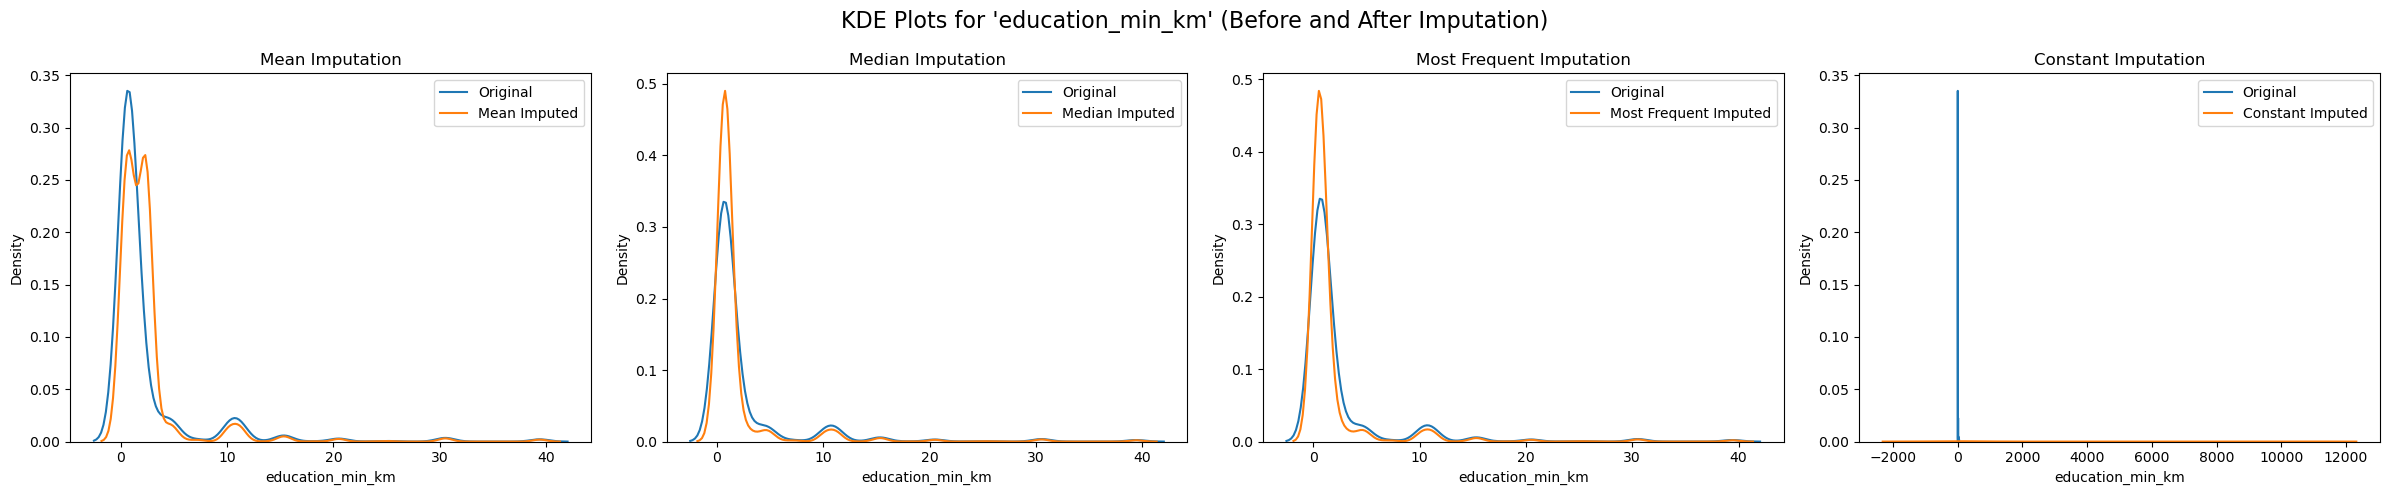

In [70]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'education_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'education_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


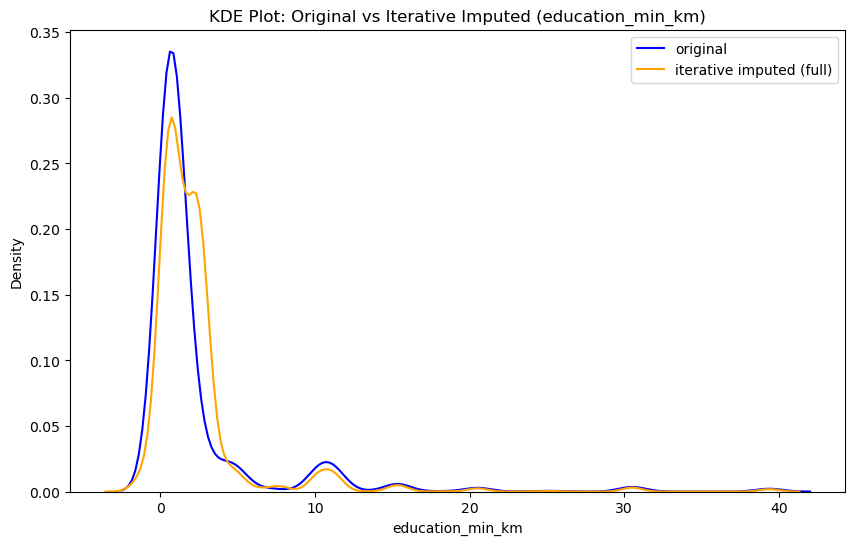

In [71]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'education_min_km')

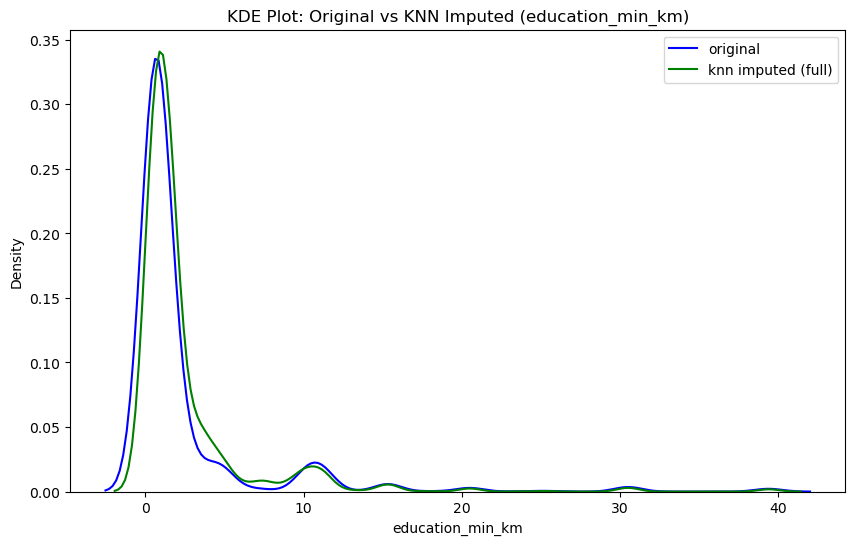

In [72]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'education_min_km')

In [73]:
print("Original:\n", X_train['education_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['education_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['education_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5922.000000
mean        2.390713
std         4.960103
min         0.100000
25%         0.500000
50%         0.800000
75%         1.400000
max        39.400000
Name: education_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.521685
std         4.221818
min         0.100000
25%         0.600000
50%         1.320000
75%         2.100000
max        39.400000
Name: education_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.354348
std         4.020792
min        -1.614666
25%         0.525000
50%         1.300000
75%         2.485001
max        39.400000
Name: education_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.390713
std         3.956672
min         0.100000
25%         0.600000
50%         1.900000
75%         2.390713
max        39.400000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.812272
std         4.029994
min         0.100000
25%         0.600000
50%   

`observation`

- median and KNN works almost same but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### transport_mean_km

In [74]:
describe_and_missing(X_train, 'transport_mean_km')


--- Description for 'transport_mean_km' ---
count    4351.000000
mean        3.875422
std         5.149028
min         0.000100
25%         1.400000
50%         2.450000
75%         4.600000
max        57.700000
Name: transport_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'transport_mean_km': 4955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

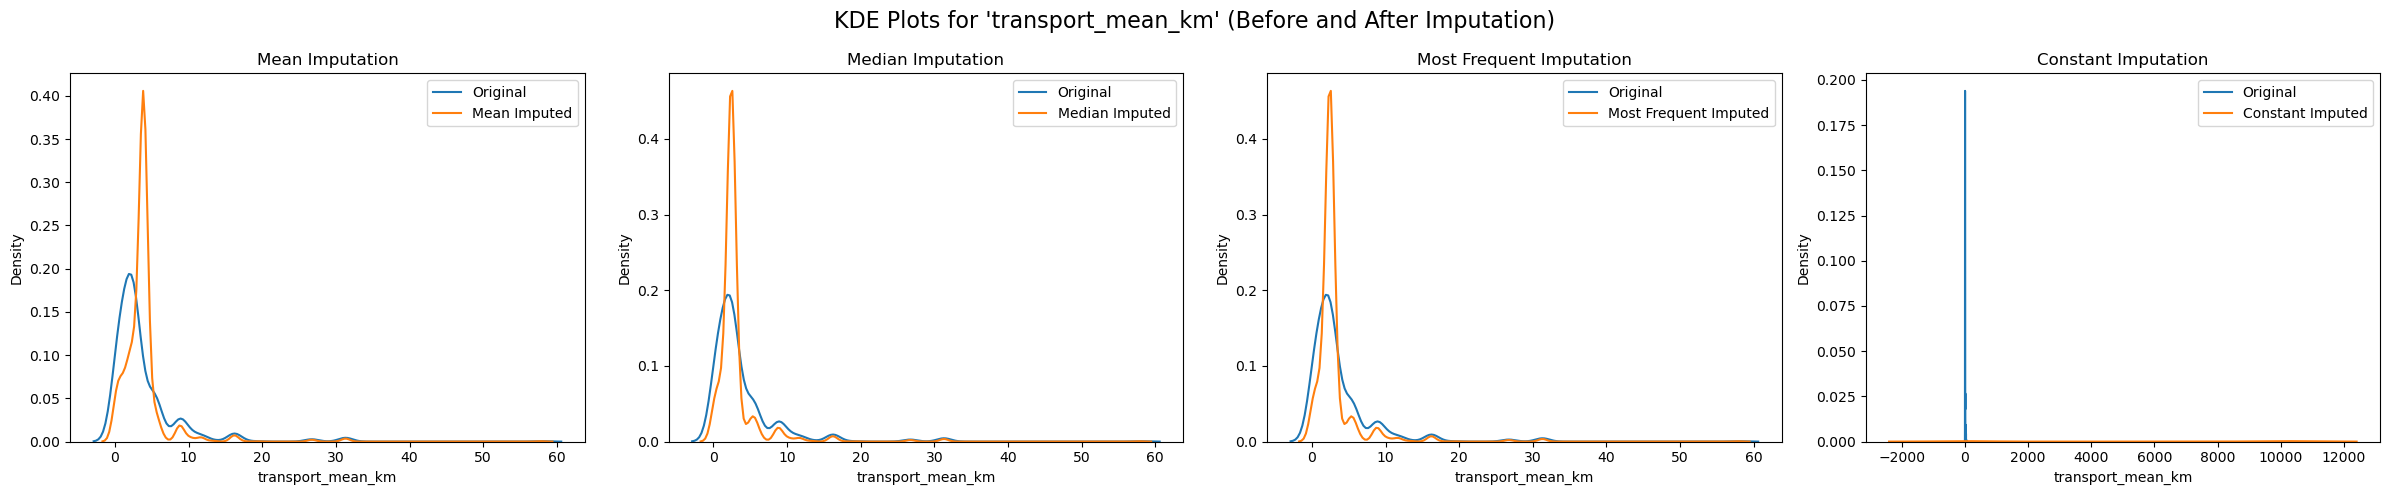

In [75]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'transport_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'transport_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


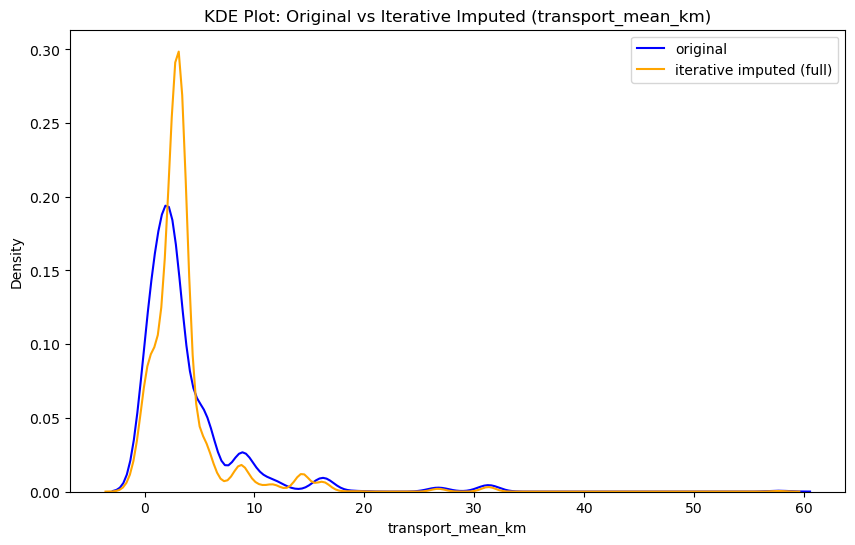

In [76]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'transport_mean_km')

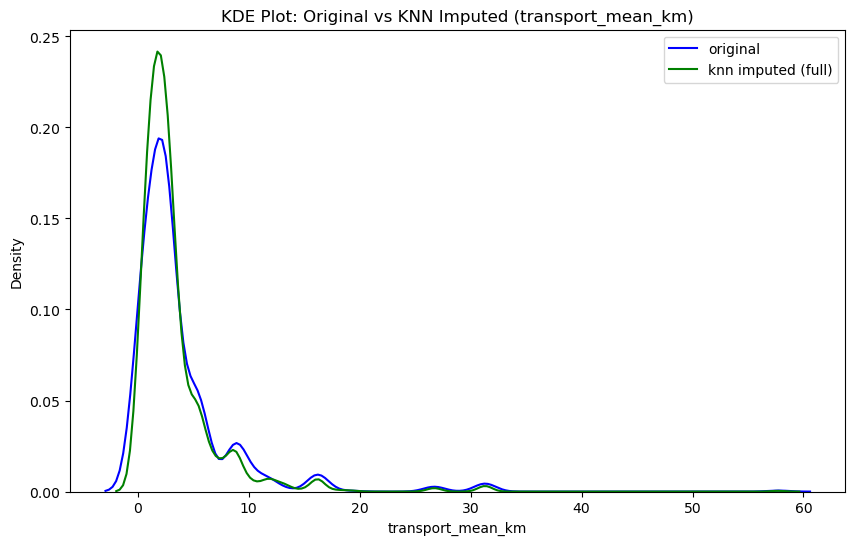

In [77]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'transport_mean_km')

In [78]:
print("Original:\n", X_train['transport_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['transport_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['transport_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    4351.000000
mean        3.875422
std         5.149028
min         0.000100
25%         1.400000
50%         2.450000
75%         4.600000
max        57.700000
Name: transport_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        3.354147
std         3.993477
min         0.000100
25%         1.400000
50%         2.386856
75%         3.696269
max        57.700000
Name: transport_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        3.573229
std         3.970974
min        -1.641944
25%         1.900000
50%         2.965515
75%         3.529514
max        57.700000
Name: transport_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        3.875422
std         3.520559
min         0.000100
25%         2.600000
50%         3.875422
75%         3.875422
max        57.700000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.116453
std         3.591686
min         0.000100
25%         2.450000
50%

`observation`

- KNN is better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### transport_min_km

In [79]:
describe_and_missing(X_train, 'transport_min_km')


--- Description for 'transport_min_km' ---
count    4351.000000
mean        2.260324
std         3.779435
min         0.000100
25%         0.400000
50%         1.400000
75%         1.900000
max        57.700000
Name: transport_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'transport_min_km': 4955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

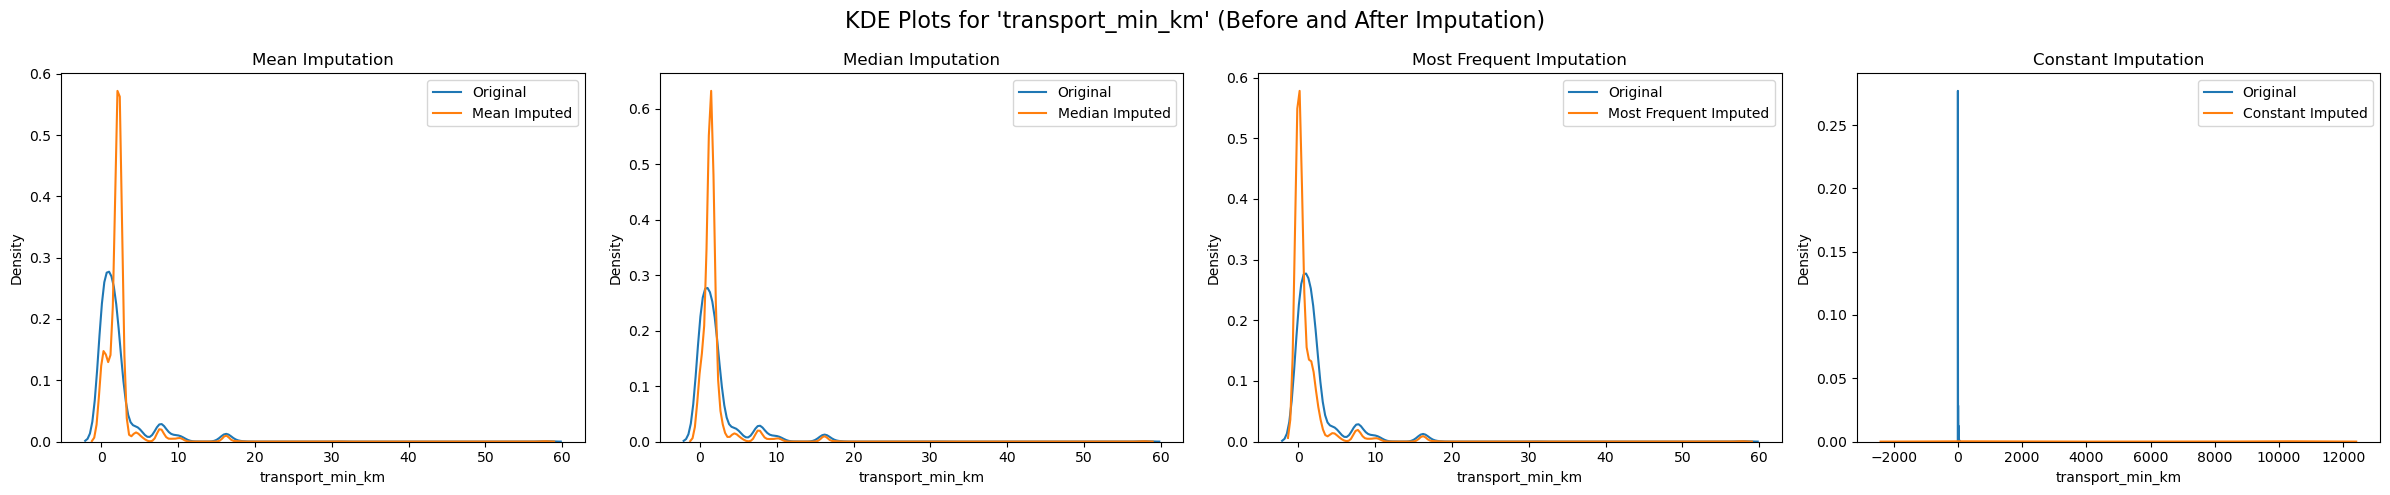

In [80]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'transport_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'transport_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


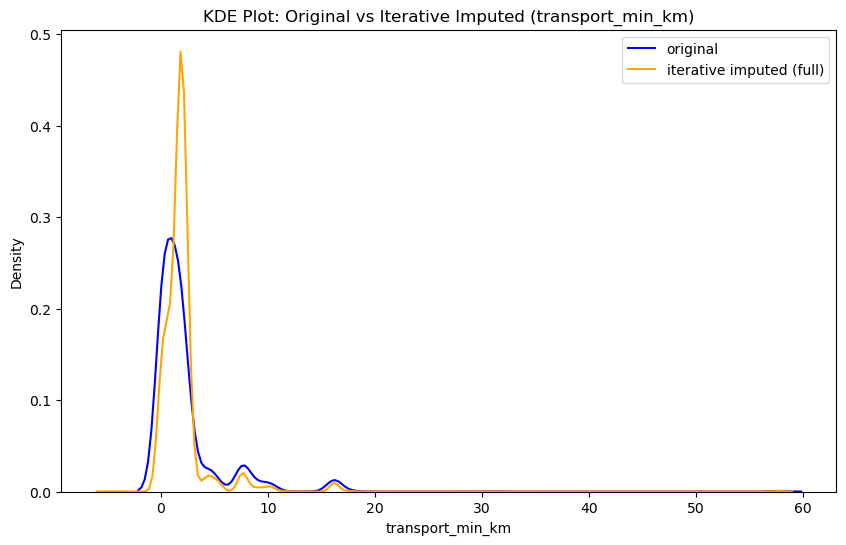

In [81]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'transport_min_km')

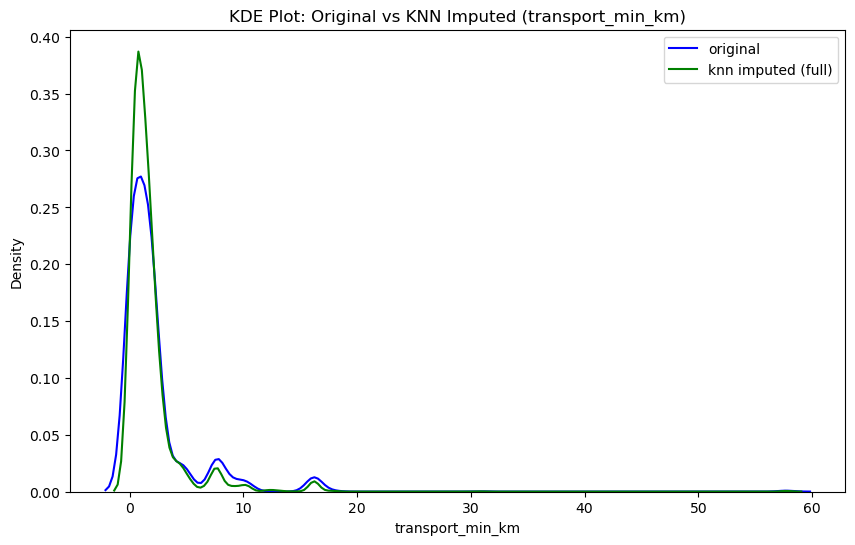

In [82]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'transport_min_km')

In [83]:
print("Original:\n", X_train['transport_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['transport_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['transport_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    4351.000000
mean        2.260324
std         3.779435
min         0.000100
25%         0.400000
50%         1.400000
75%         1.900000
max        57.700000
Name: transport_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.843073
std         2.811844
min         0.000100
25%         0.600040
50%         1.140020
75%         1.900000
max        57.700000
Name: transport_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.078171
std         2.640043
min        -4.717609
25%         1.124573
50%         1.820740
75%         2.158404
max        57.700000
Name: transport_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.260324
std         2.584124
min         0.000100
25%         1.600000
50%         2.260324
75%         2.260324
max        57.700000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.802243
std         2.619537
min         0.000100
25%         1.400000
50%   

`observation`

- KNN and median works well but KNN is slightly better than median
- KNN also changes the diastribution and hence use some other ways in next experiments 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### shopping_centre_mean_km

In [84]:
describe_and_missing(X_train, 'shopping_centre_mean_km')


--- Description for 'shopping_centre_mean_km' ---
count    6212.000000
mean        3.381102
std         3.592412
min         0.100000
25%         1.450000
50%         2.260020
75%         4.200000
max        37.300000
Name: shopping_centre_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'shopping_centre_mean_km': 3094


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

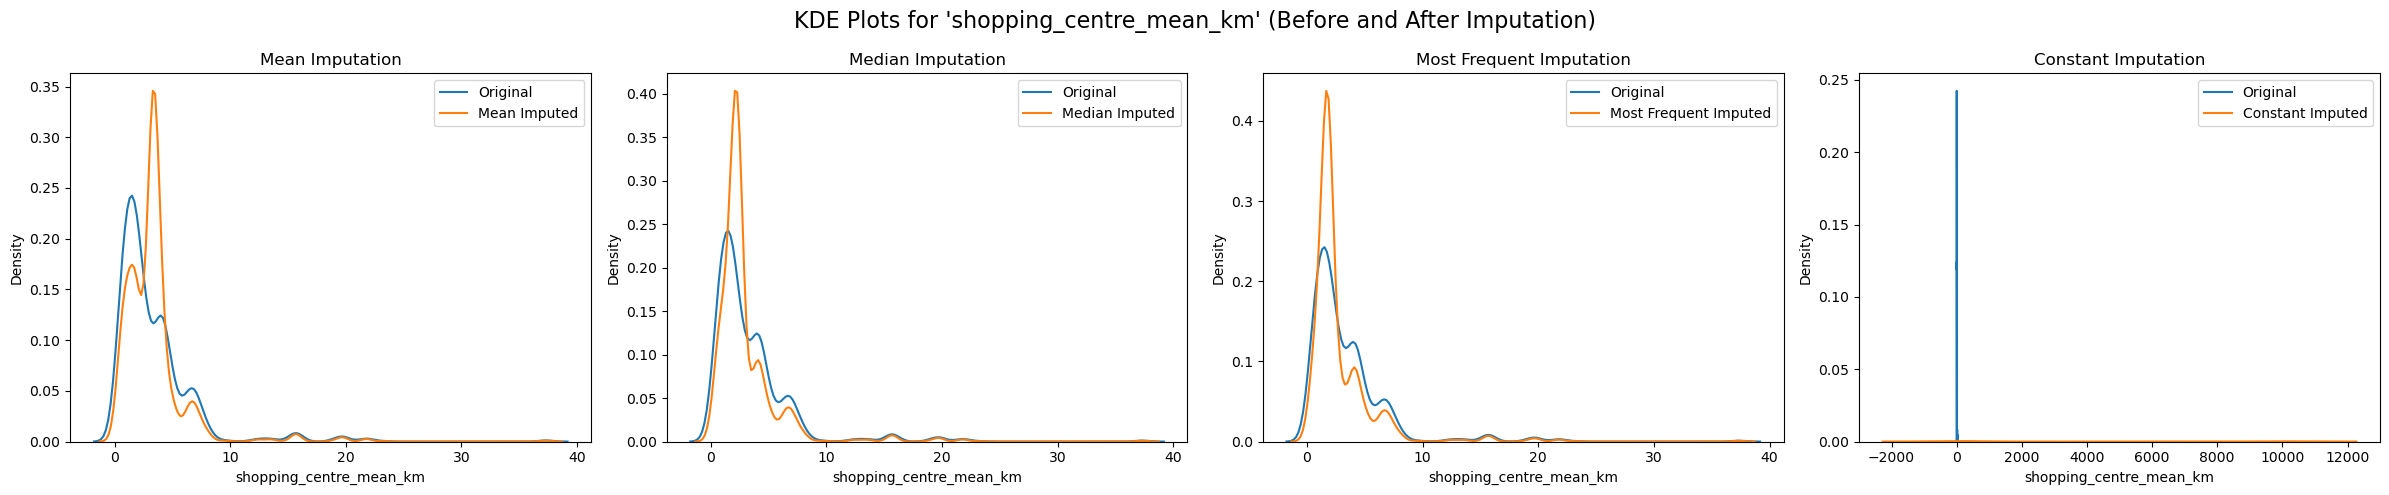

In [85]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'shopping_centre_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'shopping_centre_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


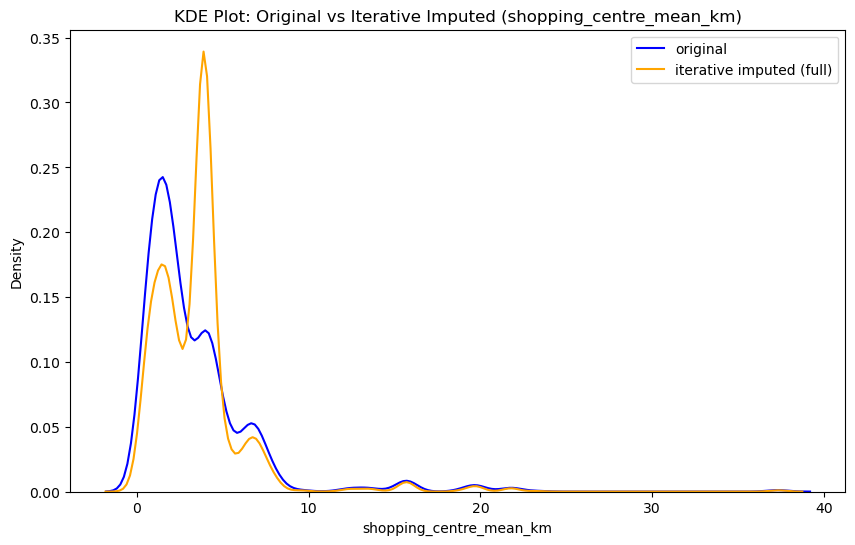

In [86]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'shopping_centre_mean_km')

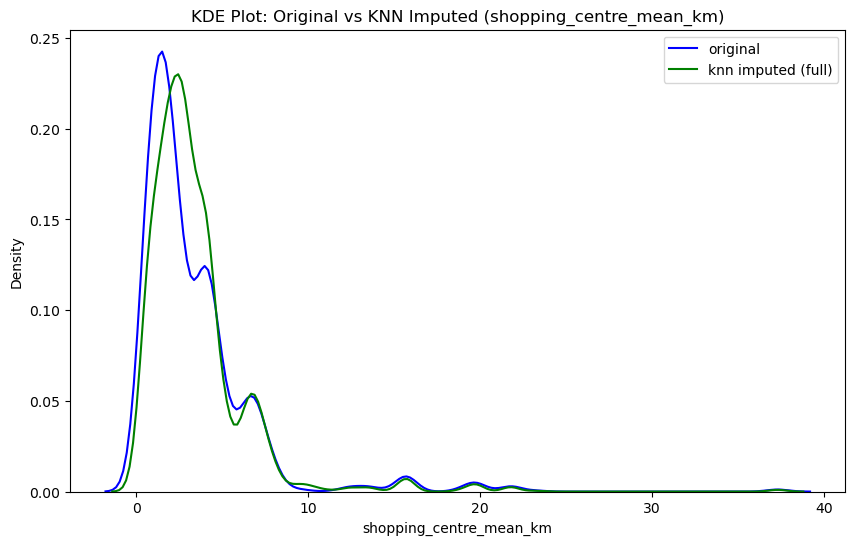

In [87]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'shopping_centre_mean_km')

In [88]:
print("Original:\n", X_train['shopping_centre_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['shopping_centre_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['shopping_centre_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6212.000000
mean        3.381102
std         3.592412
min         0.100000
25%         1.450000
50%         2.260020
75%         4.200000
max        37.300000
Name: shopping_centre_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        3.464465
std         3.087976
min         0.100000
25%         1.760000
50%         2.820000
75%         4.120000
max        37.300000
Name: shopping_centre_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        3.558167
std         2.965783
min        -0.387348
25%         1.760000
50%         3.740952
75%         4.040000
max        37.300000
Name: shopping_centre_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        3.381102
std         2.935004
min         0.100000
25%         1.760000
50%         3.381102
75%         3.460000
max        37.300000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.008372
std         2.982149
min         0.100000
25%   

`observation`

- both median and KNN works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### shopping_centre_min_km

In [89]:
describe_and_missing(X_train, 'shopping_centre_min_km')


--- Description for 'shopping_centre_min_km' ---
count    6212.000000
mean        1.474845
std         2.578839
min         0.000100
25%         0.400000
50%         0.900000
75%         1.900000
max        37.300000
Name: shopping_centre_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'shopping_centre_min_km': 3094


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

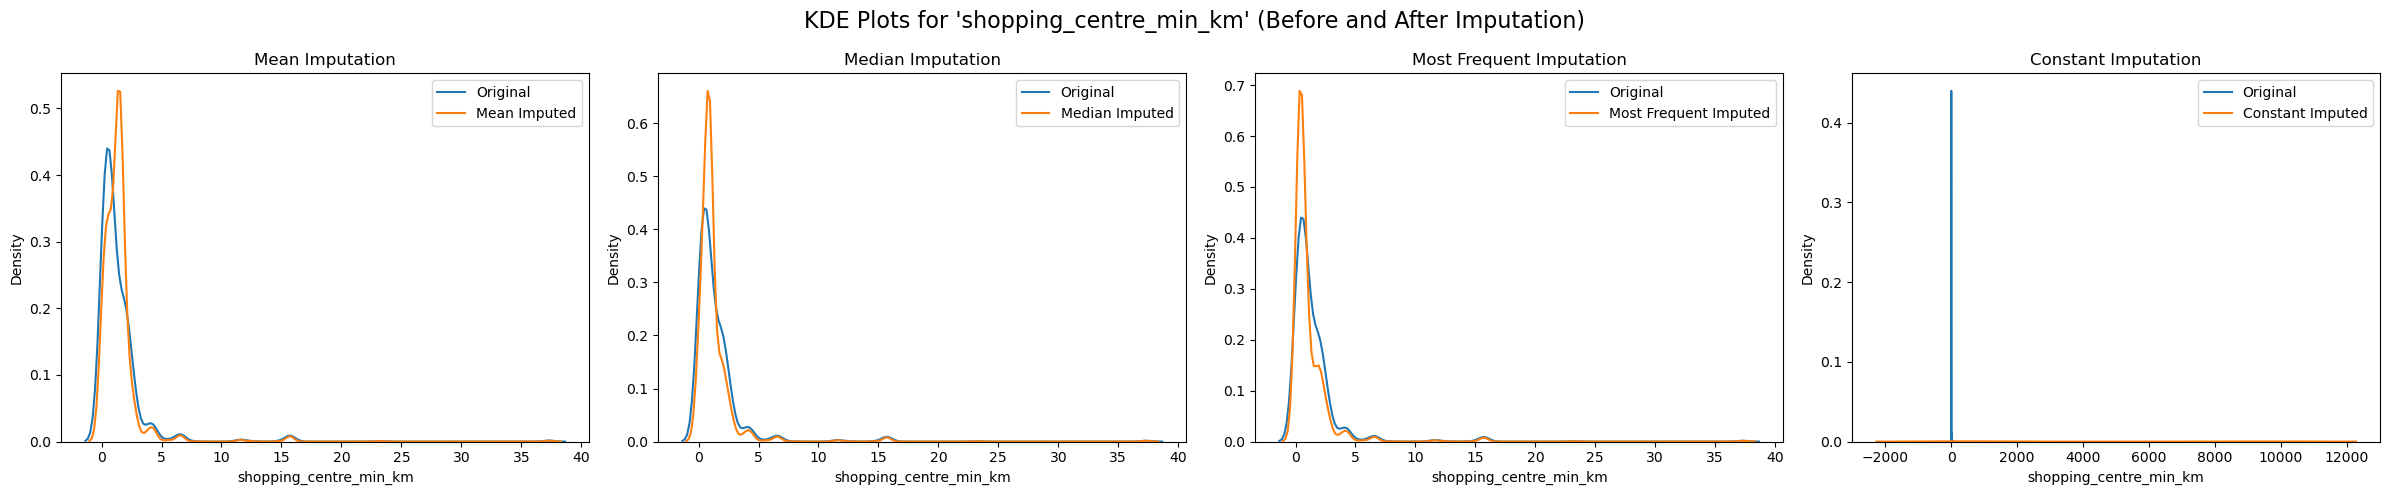

In [90]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'shopping_centre_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'shopping_centre_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


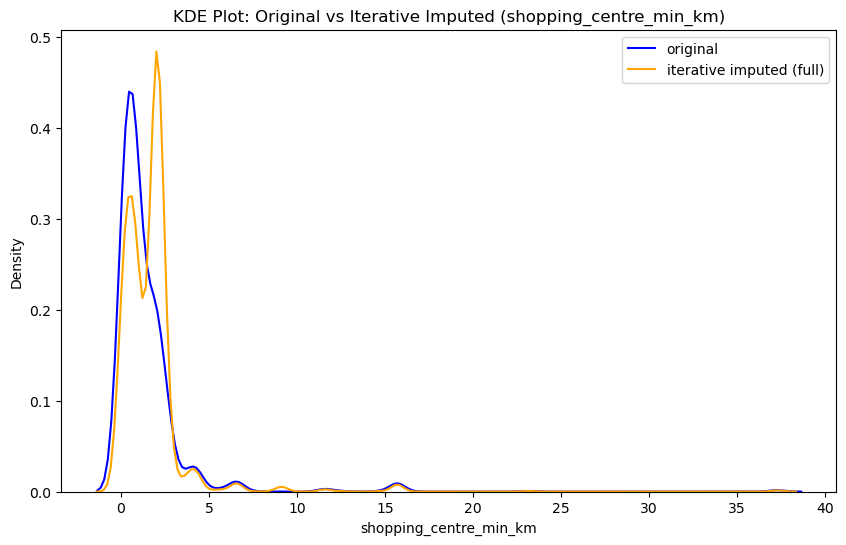

In [91]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'shopping_centre_min_km')

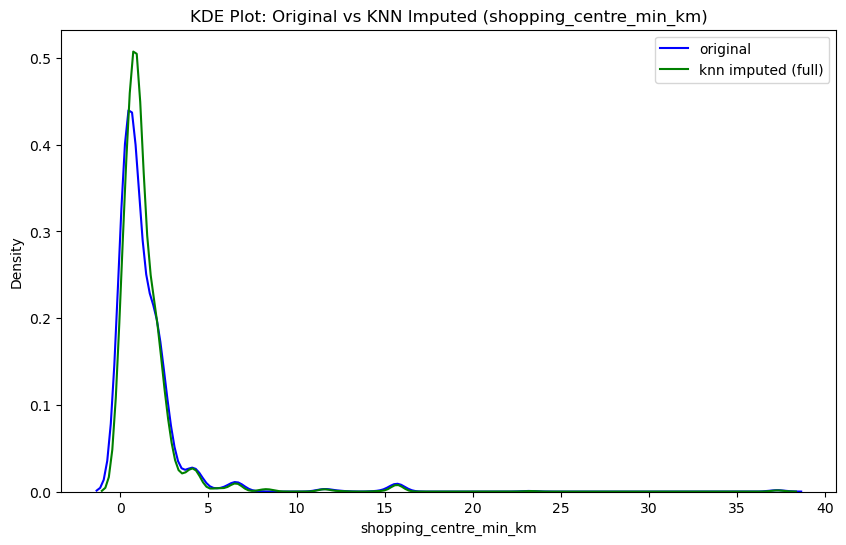

In [92]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'shopping_centre_min_km')

In [93]:
print("Original:\n", X_train['shopping_centre_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['shopping_centre_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['shopping_centre_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6212.000000
mean        1.474845
std         2.578839
min         0.000100
25%         0.400000
50%         0.900000
75%         1.900000
max        37.300000
Name: shopping_centre_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.436872
std         2.181324
min         0.000100
25%         0.600000
50%         1.000000
75%         1.800000
max        37.300000
Name: shopping_centre_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        1.712089
std         2.193145
min        -0.323836
25%         0.600000
50%         1.800000
75%         2.111274
max        37.300000
Name: shopping_centre_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        1.474845
std         2.106914
min         0.000100
25%         0.600000
50%         1.474845
75%         1.474845
max        37.300000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.283724
std         2.124249
min         0.000100
25%      

`observation`

- both median and KNN works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### commercial_hub_mean_km

In [94]:
describe_and_missing(X_train, 'commercial_hub_mean_km')


--- Description for 'commercial_hub_mean_km' ---
count    5250.000000
mean        6.861918
std         7.138121
min         0.100000
25%         2.840000
50%         4.566667
75%         7.260000
max        48.100000
Name: commercial_hub_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'commercial_hub_mean_km': 4056


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

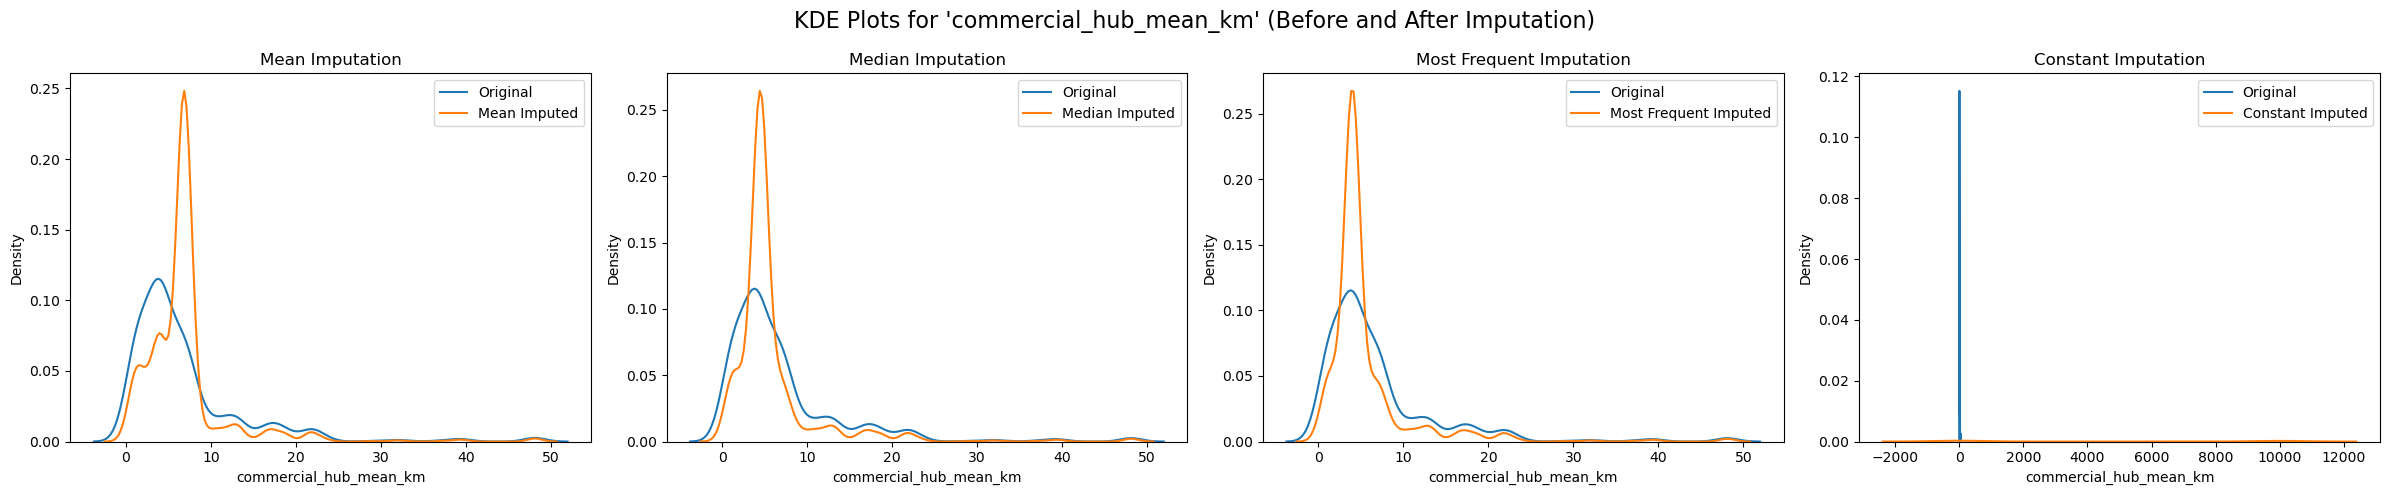

In [95]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'commercial_hub_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'commercial_hub_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


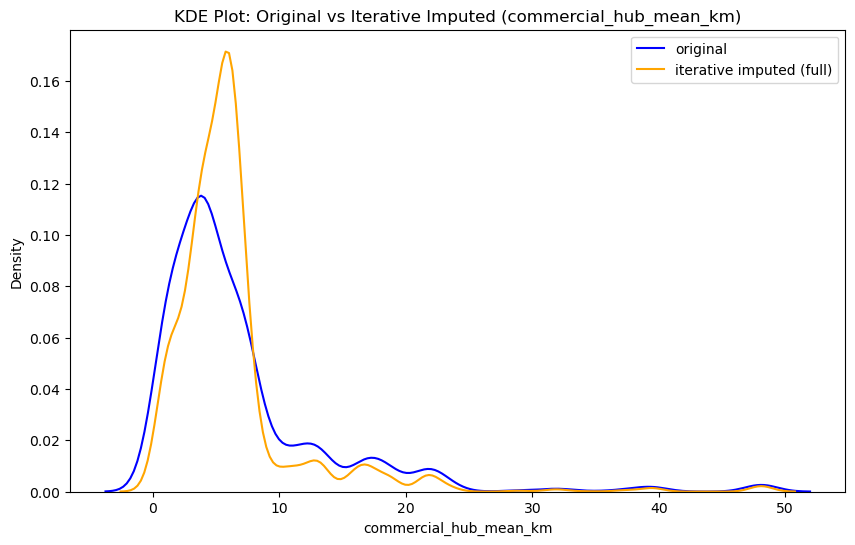

In [96]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'commercial_hub_mean_km')

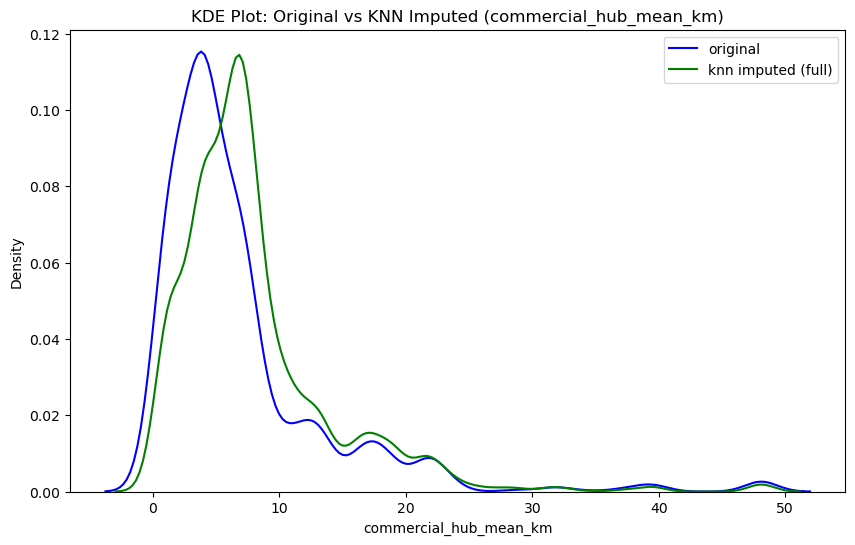

In [97]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'commercial_hub_mean_km')

In [98]:
print("Original:\n", X_train['commercial_hub_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['commercial_hub_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['commercial_hub_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5250.000000
mean        6.861918
std         7.138121
min         0.100000
25%         2.840000
50%         4.566667
75%         7.260000
max        48.100000
Name: commercial_hub_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        8.004867
std         6.375024
min         0.100000
25%         4.033333
50%         6.774500
75%         9.477333
max        48.100000
Name: commercial_hub_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        6.296043
std         5.535474
min         0.100000
25%         3.760000
50%         5.671346
75%         6.672874
max        48.100000
Name: commercial_hub_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        6.861918
std         5.361225
min         0.100000
25%         4.060000
50%         6.861918
75%         6.861918
max        48.100000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        5.861538
std         5.480715
min         0.100000
25%      

`observation`

- both Iterative and Median works well but KNN is better
- slight shift using KNN so try other approaches also in next experiments else KNN is fine here 

### commercial_hub_min_km

In [99]:
describe_and_missing(X_train, 'commercial_hub_min_km')


--- Description for 'commercial_hub_min_km' ---
count    5250.000000
mean        4.609031
std         6.938345
min         0.000100
25%         1.000000
50%         2.100000
75%         5.600000
max        48.100000
Name: commercial_hub_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'commercial_hub_min_km': 4056


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

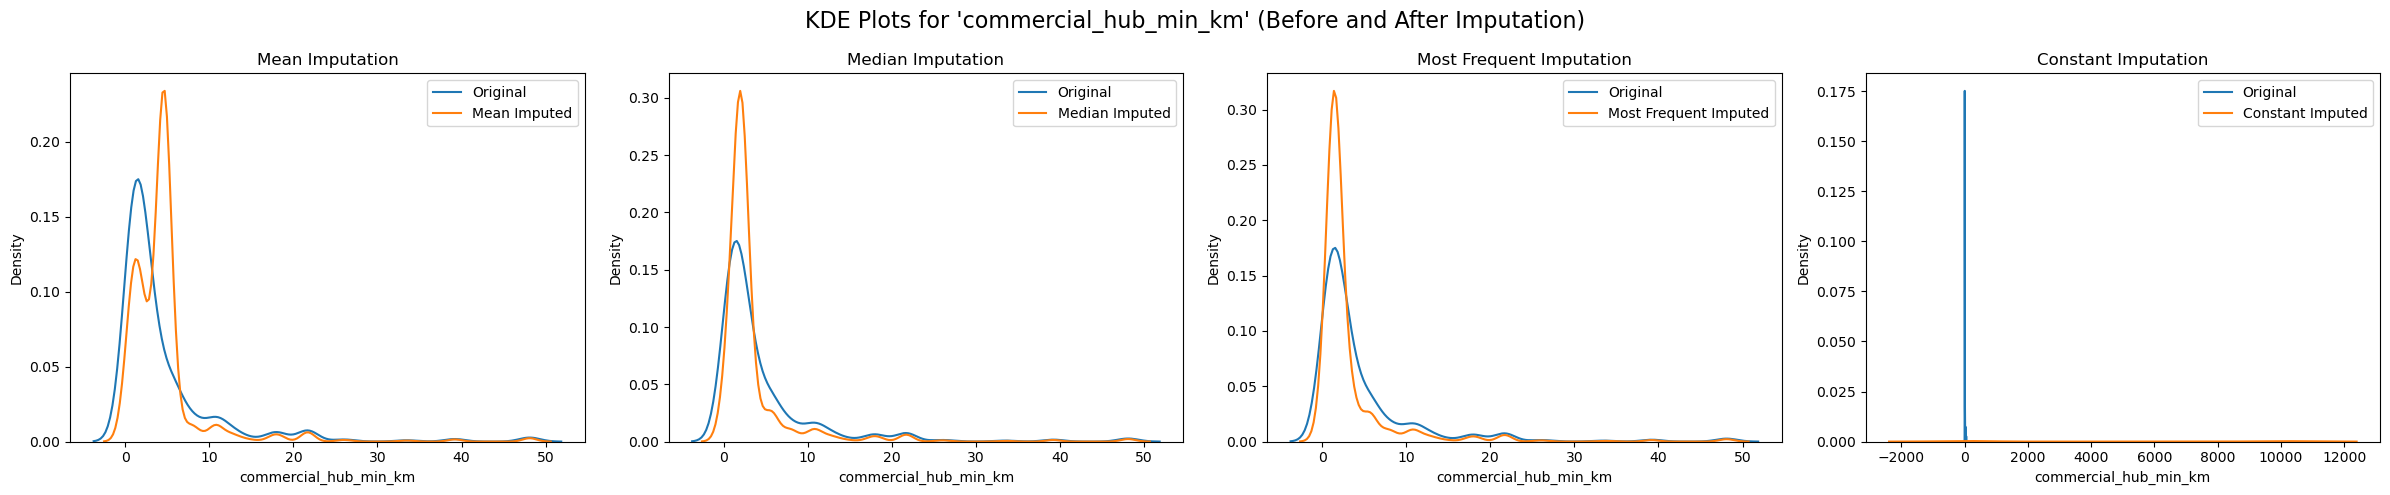

In [100]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'commercial_hub_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'commercial_hub_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


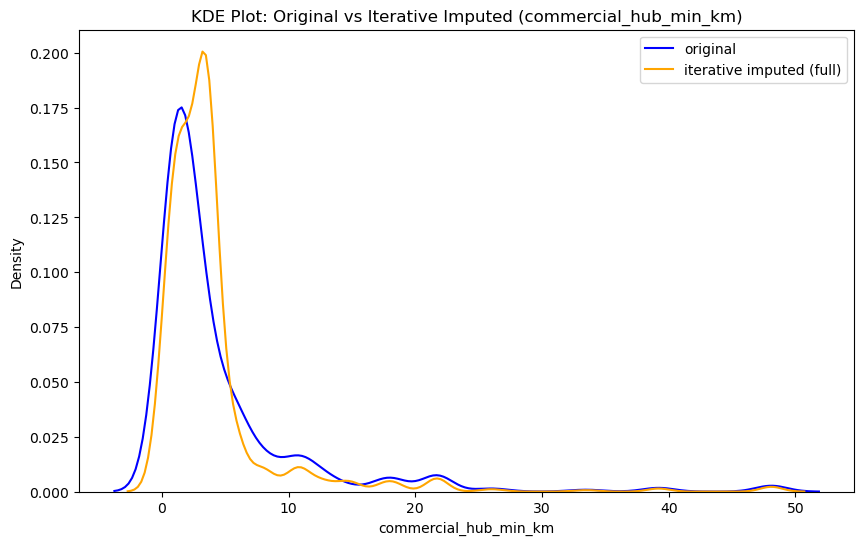

In [101]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'commercial_hub_min_km')

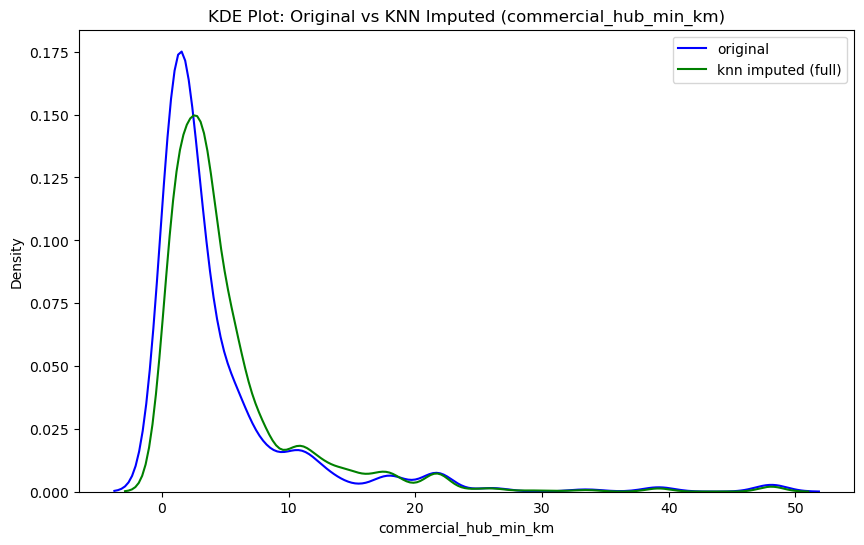

In [102]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'commercial_hub_min_km')

In [103]:
print("Original:\n", X_train['commercial_hub_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['commercial_hub_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['commercial_hub_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5250.000000
mean        4.609031
std         6.938345
min         0.000100
25%         1.000000
50%         2.100000
75%         5.600000
max        48.100000
Name: commercial_hub_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        5.224951
std         6.038299
min         0.000100
25%         1.700000
50%         3.400000
75%         5.795000
max        48.100000
Name: commercial_hub_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        4.018293
std         5.393574
min        -0.102071
25%         1.500000
50%         3.257334
75%         3.800000
max        48.100000
Name: commercial_hub_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        4.609031
std         5.211179
min         0.000100
25%         1.700000
50%         4.609031
75%         4.609031
max        48.100000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.515475
std         5.357654
min         0.000100
25%         

`observation`

- KNN works well 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### overall_min_mean_km

In [104]:
describe_and_missing(X_train, 'overall_min_mean_km')


--- Description for 'overall_min_mean_km' ---
count    6351.000000
mean        1.733045
std         2.634916
min         0.000100
25%         0.700000
50%         0.925000
75%         1.760000
max        21.775000
Name: overall_min_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'overall_min_mean_km': 2955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

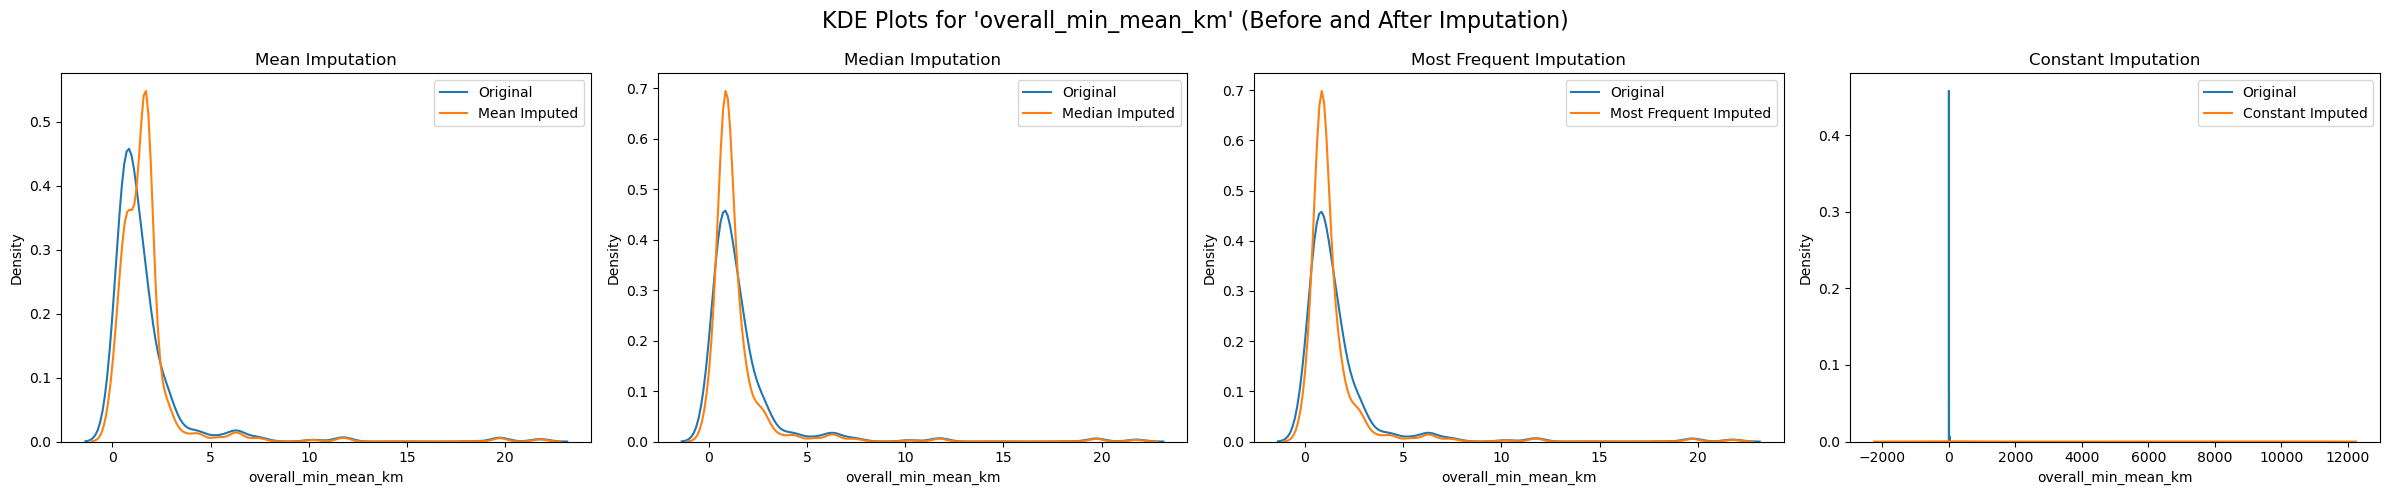

In [105]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'overall_min_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'overall_min_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


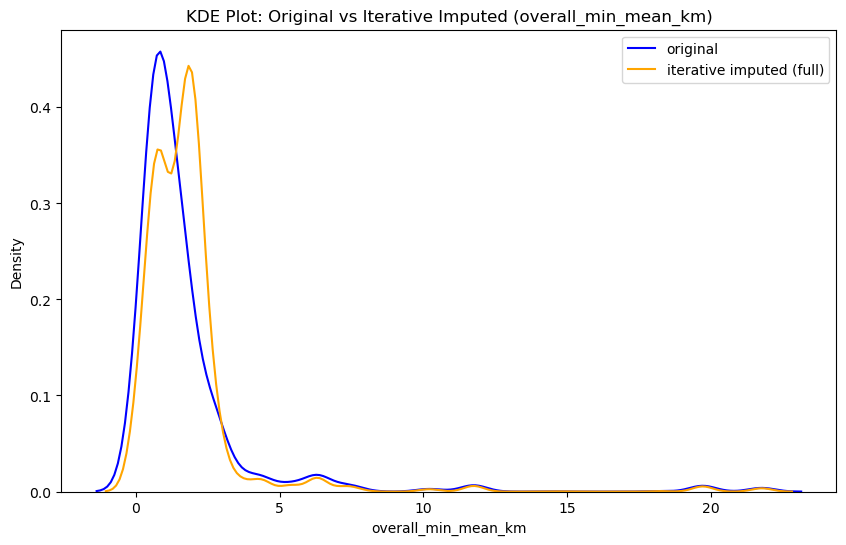

In [106]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'overall_min_mean_km')

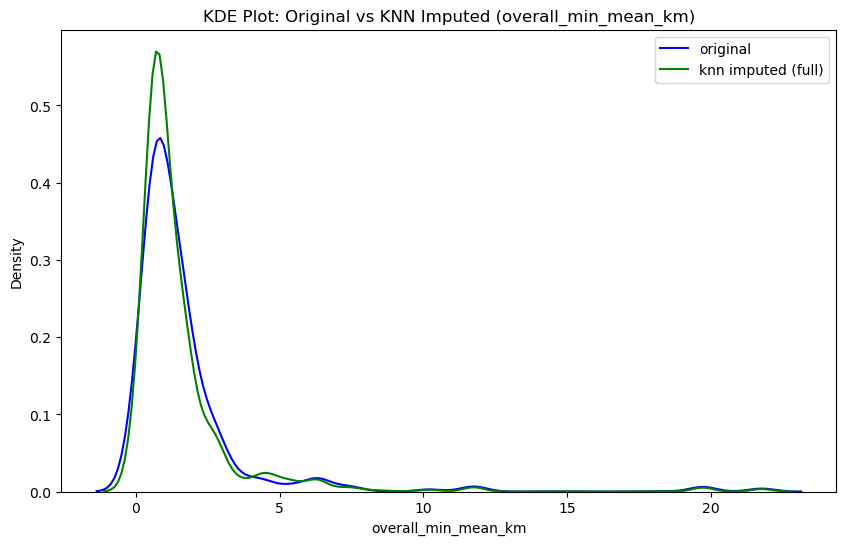

In [107]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'overall_min_mean_km')

In [108]:
print("Original:\n", X_train['overall_min_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['overall_min_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['overall_min_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6351.000000
mean        1.733045
std         2.634916
min         0.000100
25%         0.700000
50%         0.925000
75%         1.760000
max        21.775000
Name: overall_min_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.577132
std         2.307031
min         0.000100
25%         0.602040
50%         0.900000
75%         1.633333
max        21.775000
Name: overall_min_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        1.813265
std         2.184519
min         0.000100
25%         0.820000
50%         1.633333
75%         2.082496
max        21.775000
Name: overall_min_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        1.733045
std         2.176684
min         0.000100
25%         0.820000
50%         1.733045
75%         1.733045
max        21.775000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.476461
std         2.208951
min         0.000100
25%         0.8200

`observation`

- both KNN and median almost same but KNN is slightly better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### overall_avg_mean_km

In [109]:
describe_and_missing(X_train, 'overall_avg_mean_km')


--- Description for 'overall_avg_mean_km' ---
count    6351.000000
mean        4.810624
std         5.062668
min         0.100000
25%         1.854667
50%         3.540000
75%         4.620000
max        34.788333
Name: overall_avg_mean_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'overall_avg_mean_km': 2955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

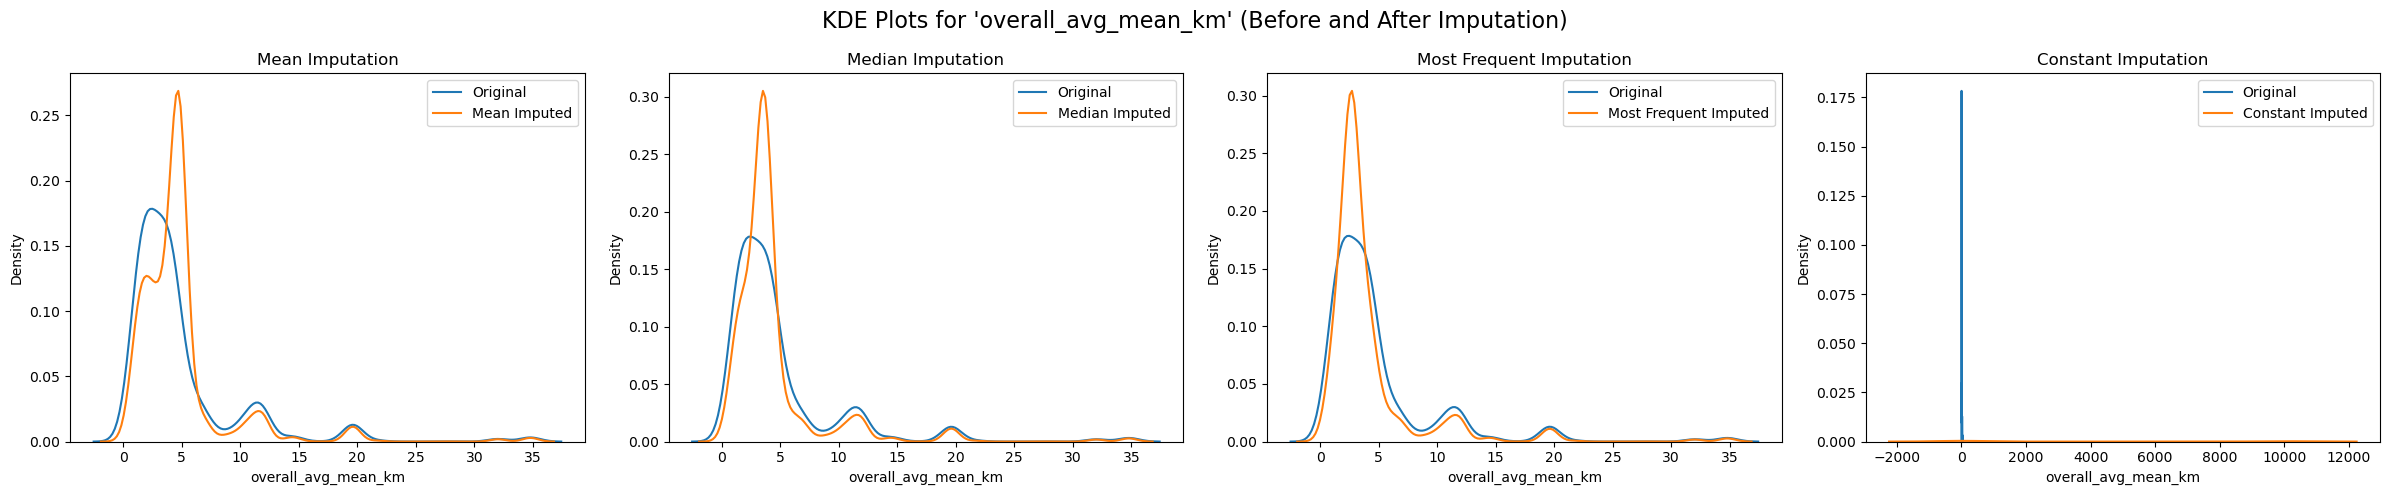

In [110]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'overall_avg_mean_km', constant_value=9999)
plot_kde_imputations(X_train, 'overall_avg_mean_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


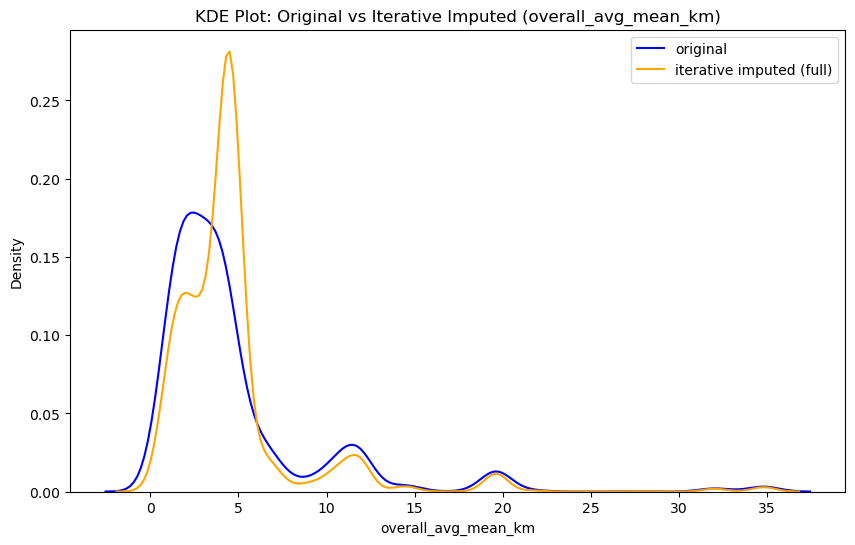

In [111]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'overall_avg_mean_km')

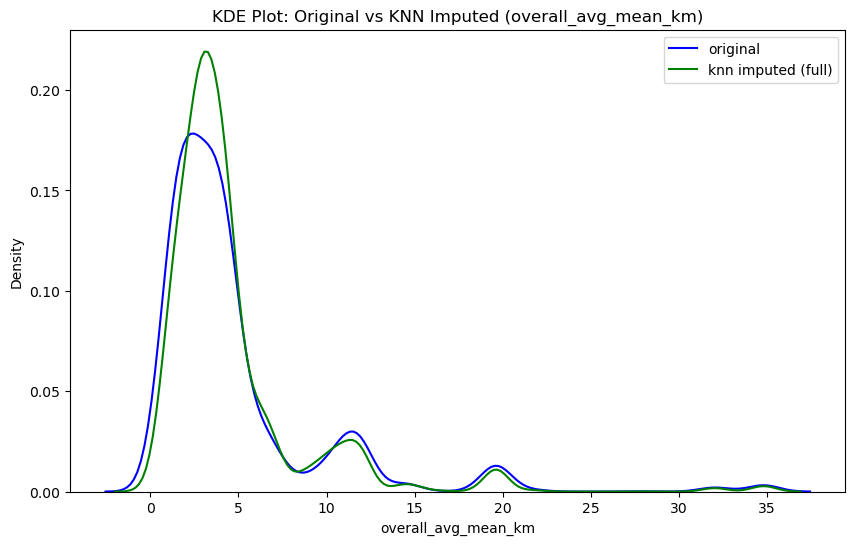

In [112]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'overall_avg_mean_km')

In [113]:
print("Original:\n", X_train['overall_avg_mean_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['overall_avg_mean_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['overall_avg_mean_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6351.000000
mean        4.810624
std         5.062668
min         0.100000
25%         1.854667
50%         3.540000
75%         4.620000
max        34.788333
Name: overall_avg_mean_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        4.633614
std         4.361217
min         0.100000
25%         2.563673
50%         3.485040
75%         4.647590
max        34.788333
Name: overall_avg_mean_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        4.737294
std         4.183849
min         0.100000
25%         2.690000
50%         4.402445
75%         4.632647
max        34.788333
Name: overall_avg_mean_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        4.810624
std         4.182232
min         0.100000
25%         2.690000
50%         4.620000
75%         4.810624
max        34.788333
dtype: float64 

Median Imputed:
 count    9306.000000
mean        4.407153
std         4.223858
min         0.100000
25%         2.6900

`observation`

- both KNN and median works well but KNN is slightly better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### overall_min_min_km

In [114]:
describe_and_missing(X_train, 'overall_min_min_km')


--- Description for 'overall_min_min_km' ---
count    6351.000000
mean        0.718734
std         1.230024
min         0.000100
25%         0.200000
50%         0.400000
75%         0.900000
max        14.700000
Name: overall_min_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'overall_min_min_km': 2955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

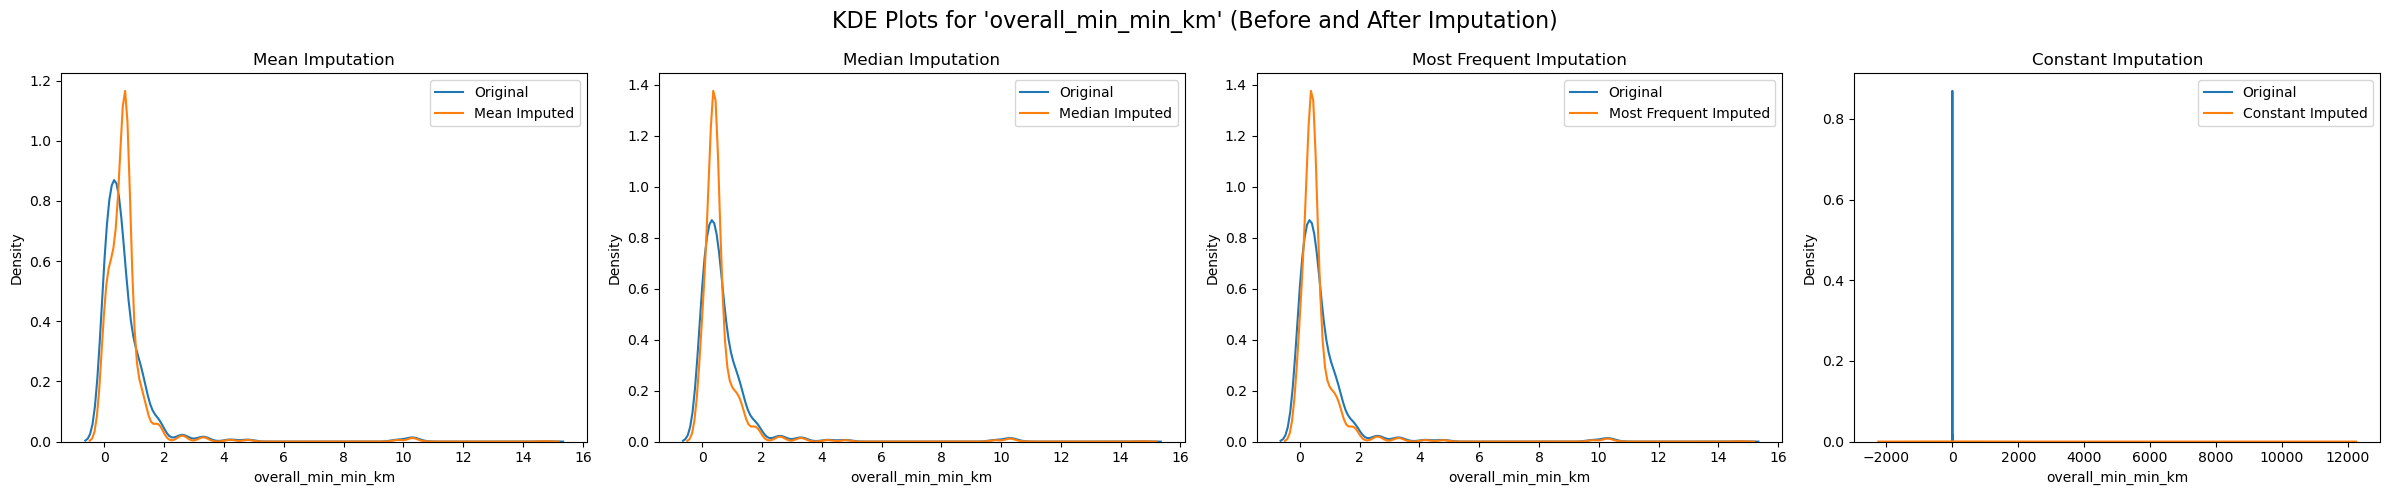

In [115]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'overall_min_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'overall_min_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


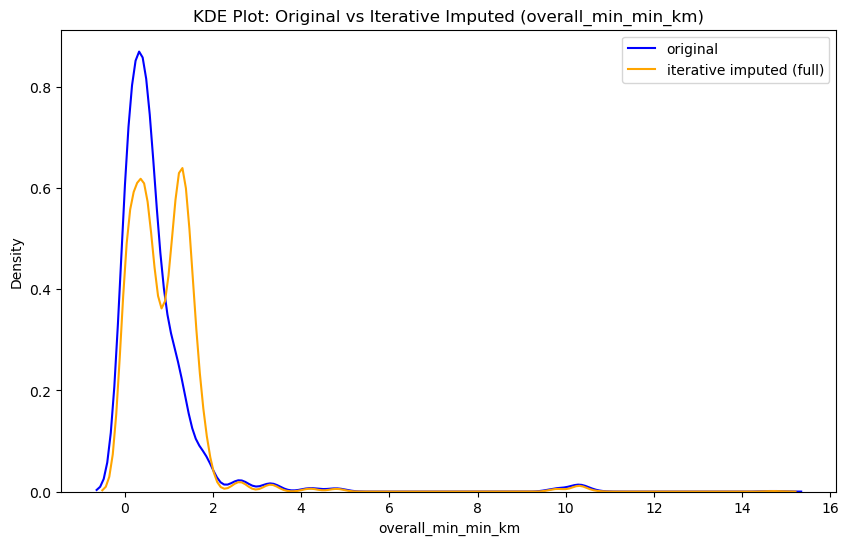

In [116]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'overall_min_min_km')

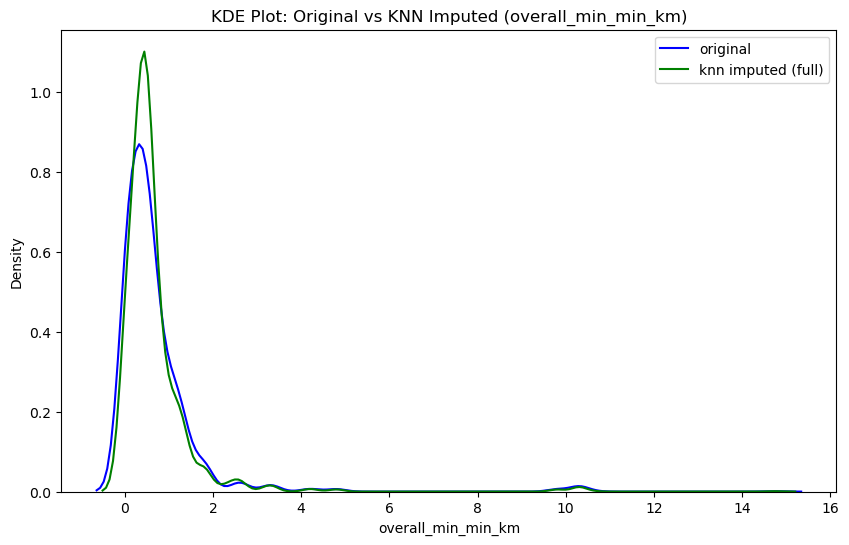

In [117]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'overall_min_min_km')

In [118]:
print("Original:\n", X_train['overall_min_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['overall_min_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['overall_min_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6351.000000
mean        0.718734
std         1.230024
min         0.000100
25%         0.200000
50%         0.400000
75%         0.900000
max        14.700000
Name: overall_min_min_km, dtype: float64 

KNN Imputed:
 count    9306.00000
mean        0.68558
std         1.04820
min         0.00010
25%         0.30000
50%         0.48002
75%         0.72002
max        14.70000
Name: overall_min_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        0.911705
std         1.060439
min         0.000100
25%         0.300000
50%         0.800000
75%         1.300000
max        14.700000
Name: overall_min_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        0.718734
std         1.016114
min         0.000100
25%         0.300000
50%         0.718734
75%         0.718734
max        14.700000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        0.617524
std         1.026891
min         0.000100
25%         0.300000
50%     

`observation`

- both KNN and median works well but KNN is slightly betteer
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### overall_avg_min_km

In [119]:
describe_and_missing(X_train, 'overall_avg_min_km')


--- Description for 'overall_avg_min_km' ---
count    6351.000000
mean        2.370468
std         2.931916
min         0.000100
25%         0.820000
50%         1.675000
75%         2.200000
max        24.125000
Name: overall_avg_min_km, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'overall_avg_min_km': 2955


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

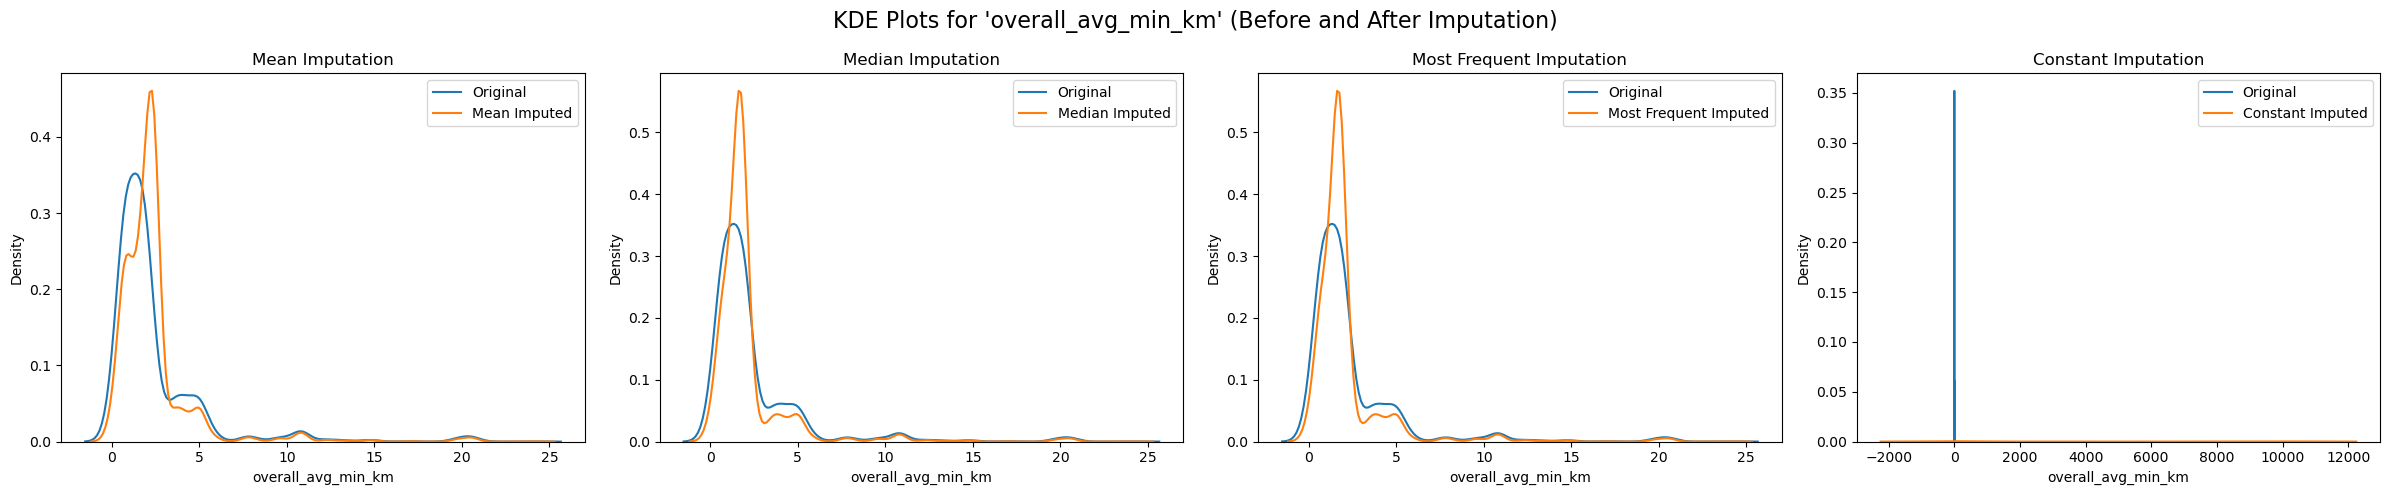

In [120]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'overall_avg_min_km', constant_value=9999)
plot_kde_imputations(X_train, 'overall_avg_min_km')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


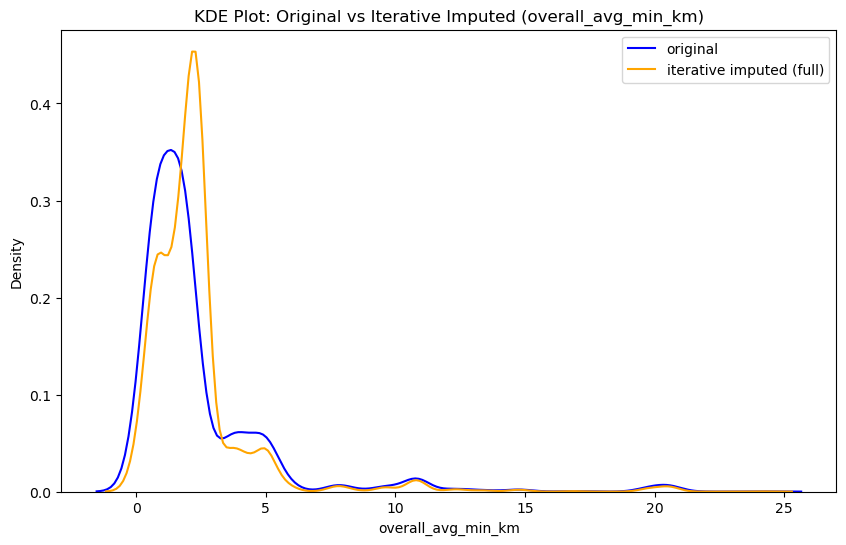

In [121]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'overall_avg_min_km')

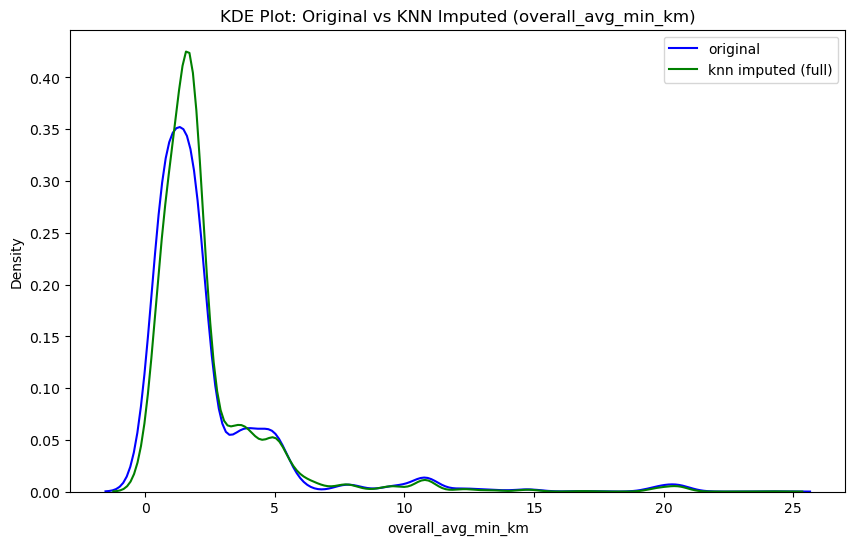

In [122]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'overall_avg_min_km')

In [123]:
print("Original:\n", X_train['overall_avg_min_km'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['overall_avg_min_km'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['overall_avg_min_km'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    6351.000000
mean        2.370468
std         2.931916
min         0.000100
25%         0.820000
50%         1.675000
75%         2.200000
max        24.125000
Name: overall_avg_min_km, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.351505
std         2.543496
min         0.000100
25%         1.075000
50%         1.675000
75%         2.300000
max        24.125000
Name: overall_avg_min_km, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.370553
std         2.422499
min         0.000100
25%         1.200000
50%         2.150000
75%         2.407400
max        24.125000
Name: overall_avg_min_km, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.370468
std         2.422034
min         0.000100
25%         1.200000
50%         2.175000
75%         2.370468
max        24.125000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        2.149631
std         2.443578
min         0.000100
25%         1.200000


`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### available_units

In [124]:
describe_and_missing(X_train, 'available_units')


--- Description for 'available_units' ---
count     5171.000000
mean       455.931348
std       1104.010526
min          6.000000
25%        120.000000
50%        275.000000
75%        534.000000
max      40000.000000
Name: available_units, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'available_units': 4135


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

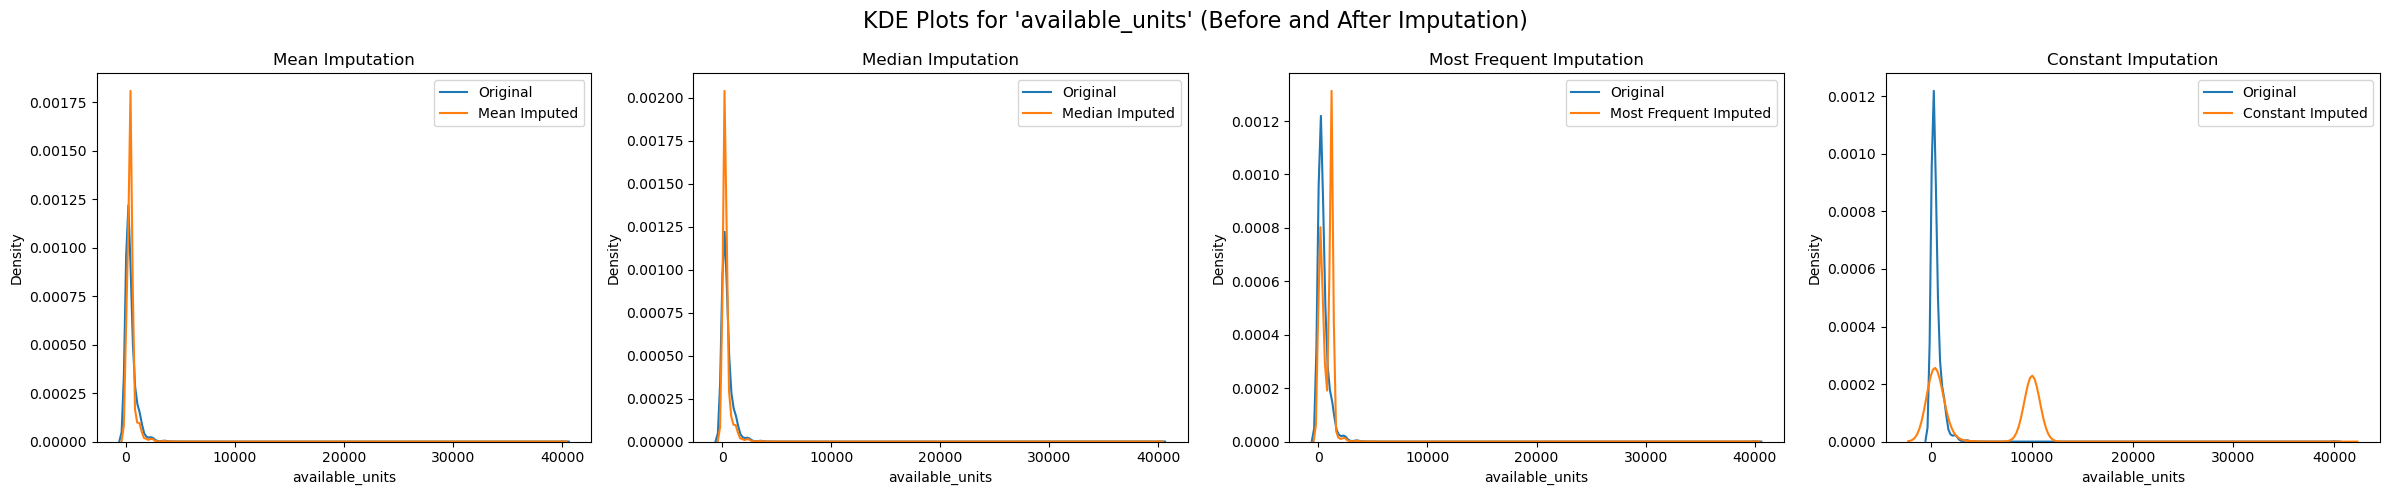

In [125]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'available_units', constant_value=9999)
plot_kde_imputations(X_train, 'available_units')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


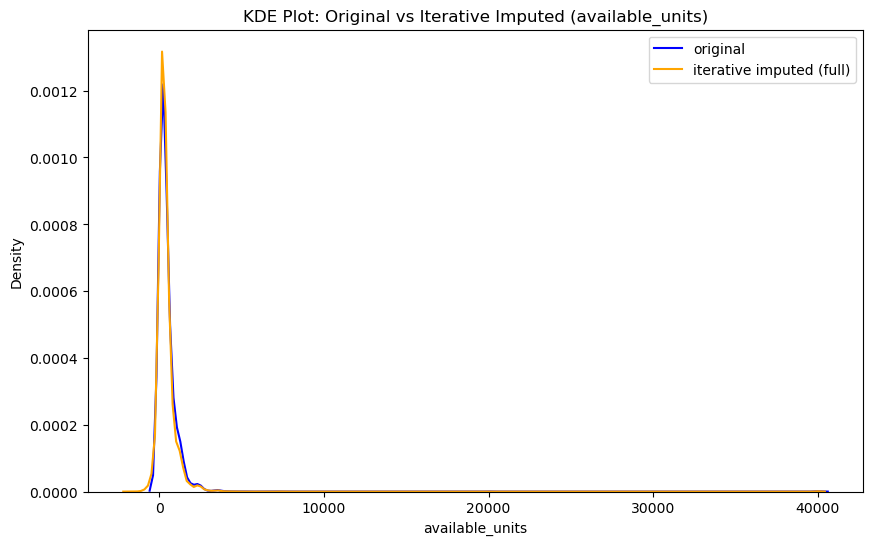

In [126]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'available_units')

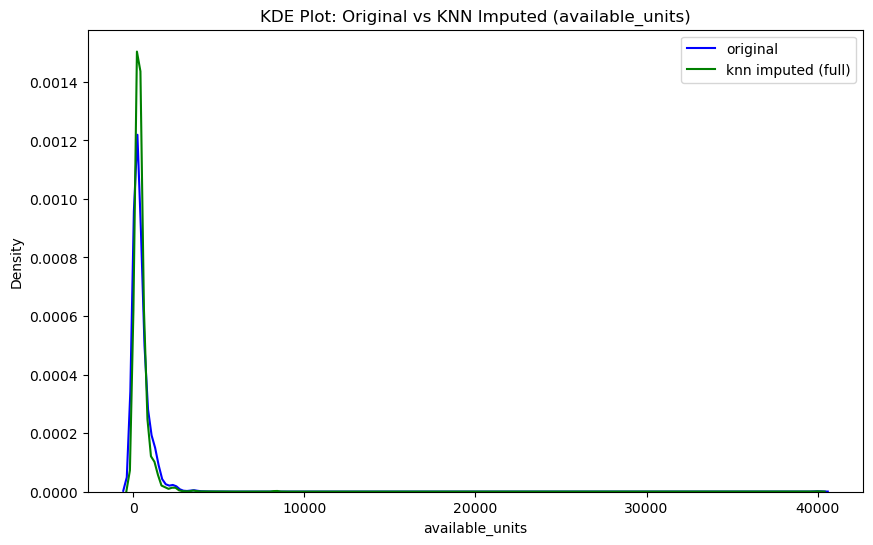

In [127]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'available_units')

In [128]:
print("Original:\n", X_train['available_units'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['available_units'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['available_units'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count     5171.000000
mean       455.931348
std       1104.010526
min          6.000000
25%        120.000000
50%        275.000000
75%        534.000000
max      40000.000000
Name: available_units, dtype: float64 

KNN Imputed:
 count     9306.000000
mean       432.571008
std        860.996702
min          6.000000
25%        229.450000
50%        324.000000
75%        481.100000
max      40000.000000
Name: available_units, dtype: float64 

Iterative Imputed:
 count     9306.000000
mean       388.165223
std        878.252456
min      -1771.712363
25%        112.000000
50%        278.000000
75%        489.000000
max      40000.000000
Name: available_units, dtype: float64 

Mean Imputed:
 count     9306.000000
mean       455.931348
std        822.925077
min          6.000000
25%        233.000000
50%        455.931348
75%        455.931348
max      40000.000000
dtype: float64 

Median Imputed:
 count     9306.000000
mean       375.536858
std        827.821938
min          6.0

`observation`

- KNN and median works well but KNN is slightly better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### towers

In [129]:
describe_and_missing(X_train, 'towers')


--- Description for 'towers' ---
count    5303.000000
mean        4.606638
std         6.709855
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       100.000000
Name: towers, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'towers': 4003


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

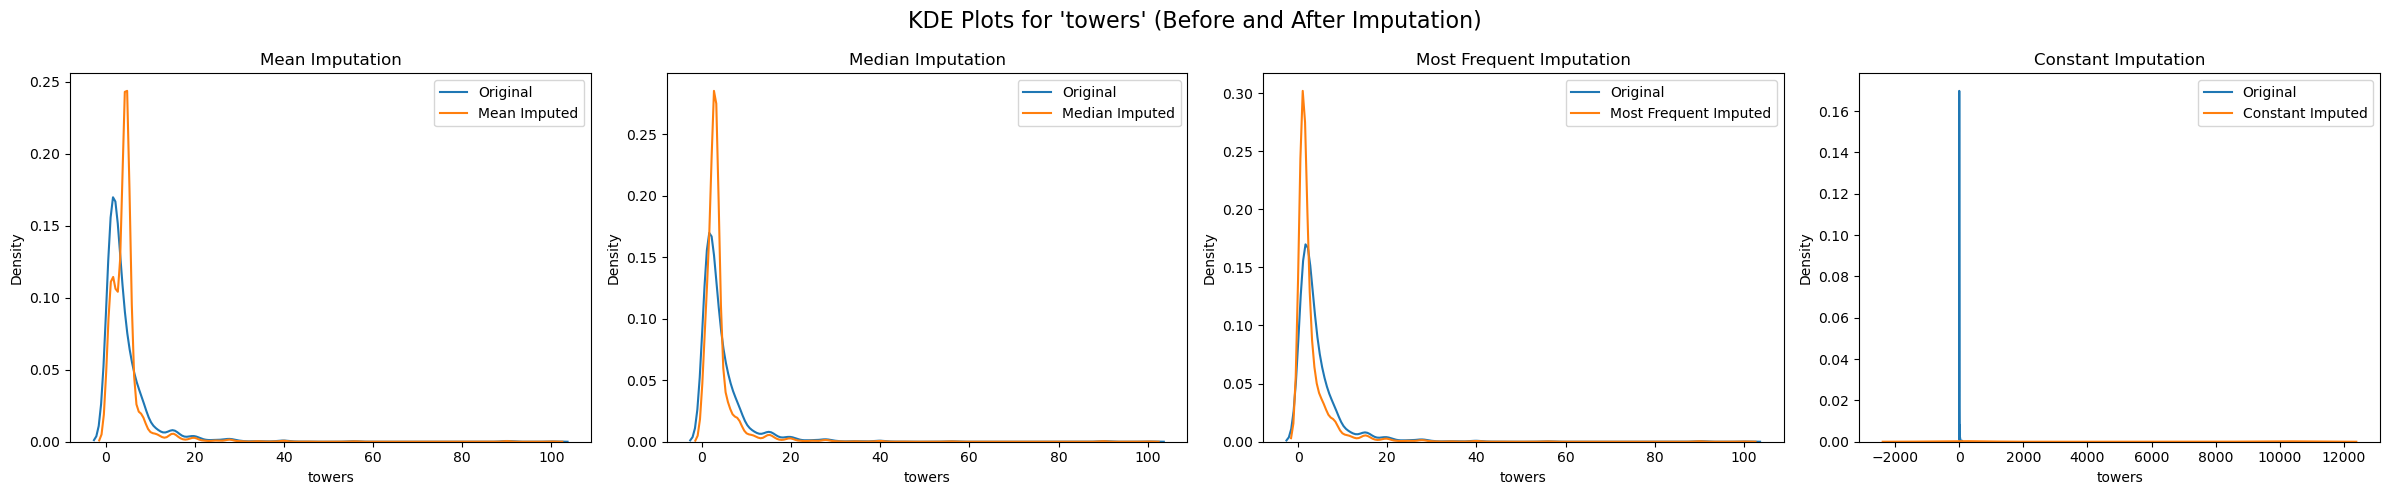

In [130]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'towers', constant_value=9999)
plot_kde_imputations(X_train, 'towers')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


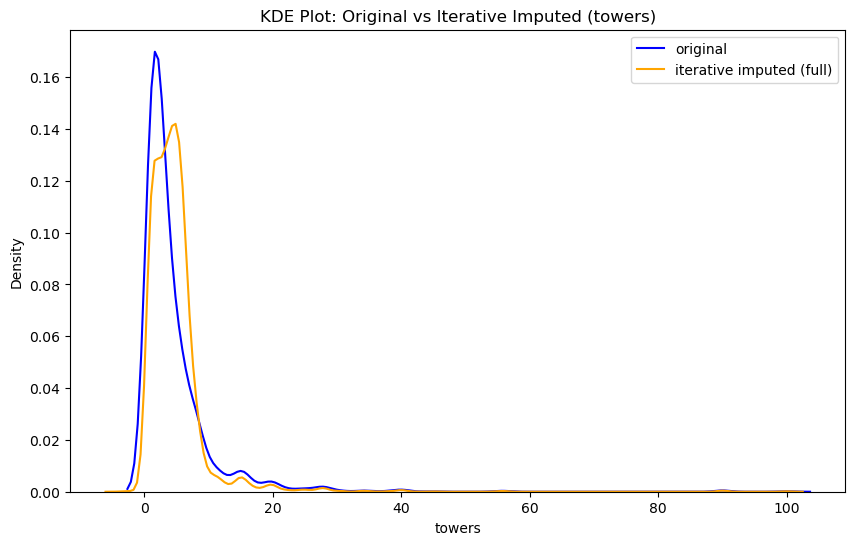

In [131]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'towers')

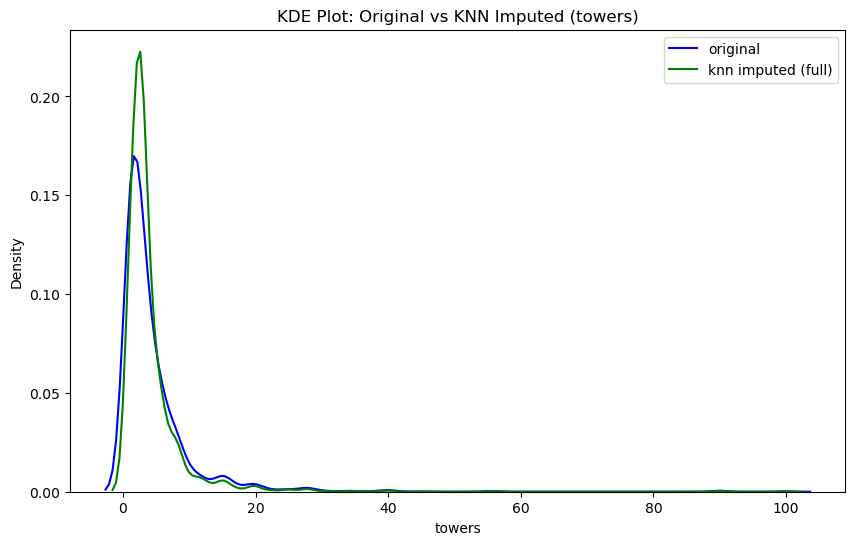

In [132]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'towers')

In [133]:
print("Original:\n", X_train['towers'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['towers'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['towers'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5303.000000
mean        4.606638
std         6.709855
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       100.000000
Name: towers, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        4.178702
std         5.311634
min         1.000000
25%         2.000000
50%         3.000000
75%         4.600000
max       100.000000
Name: towers, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        4.760665
std         5.167486
min        -3.539702
25%         2.000000
50%         4.000000
75%         5.921718
max       100.000000
Name: towers, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        4.606638
std         5.064946
min         1.000000
25%         2.000000
50%         4.606638
75%         4.606638
max       100.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.915538
std         5.127033
min         1.000000
25%         2.000000
50%         3.000000
75%         3.0

`observation`

- both KNN and median works well but KNN is slightly better
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

`conclusion`  
num_nominal_cols   
'project_in_acres','longitude','area''costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km', 'shopping_centre_min_km','overall_min_mean_km', 'overall_avg_mean_km','overall_min_min_km', 'overall_avg_min_km','available_units','towers' - KNN,    
'lattitude','commercial_hub_mean_km' - iterative,    
'transport_min_km','shopping_centre_mean_km', 'commercial_hub_min_km'- median

#delete this after reading and appyling

<font color = yellow> we have to add missing indicator also for each column we have to follow both below approaches 

---------------------------------------------------------------------------------------------------------------------

1.Approach: Imputation only   
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)  
model = LogisticRegression()  
scores_1 = cross_val_score(model, X_imputed, y, cv=3)  
print("Imputation only scores:", scores_1)  

--------------------------------------------------------------------------------------------------------------------
2.Approach: Imputation + Missing Indicator  
preprocessor = ColumnTransformer(transformers=[  
    ('impute', SimpleImputer(strategy='mean', add_indicator=True), ['Age', 'Fare'])  
])  
pipeline = make_pipeline(preprocessor, LogisticRegression())  
scores_2 = cross_val_score(pipeline, X, y, cv=3)  
print("Imputation + MissingIndicator scores:", scores_2)  

## Analysis on num_ordinal_cols

In [134]:
num_ordinal_cols = ['flat_on_floor','total_floor','bed','bath','balcony','lift','parking','education_within_2km','transport_within_2km','shopping_centre_within_2km',
                    'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

### flat_on_floor

In [135]:
describe_and_missing(X_train, 'flat_on_floor')


--- Description for 'flat_on_floor' ---
count    7663.000000
mean       10.823046
std        10.029193
min        -2.000000
25%         4.000000
50%         8.000000
75%        15.000000
max        73.000000
Name: flat_on_floor, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'flat_on_floor': 1643


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

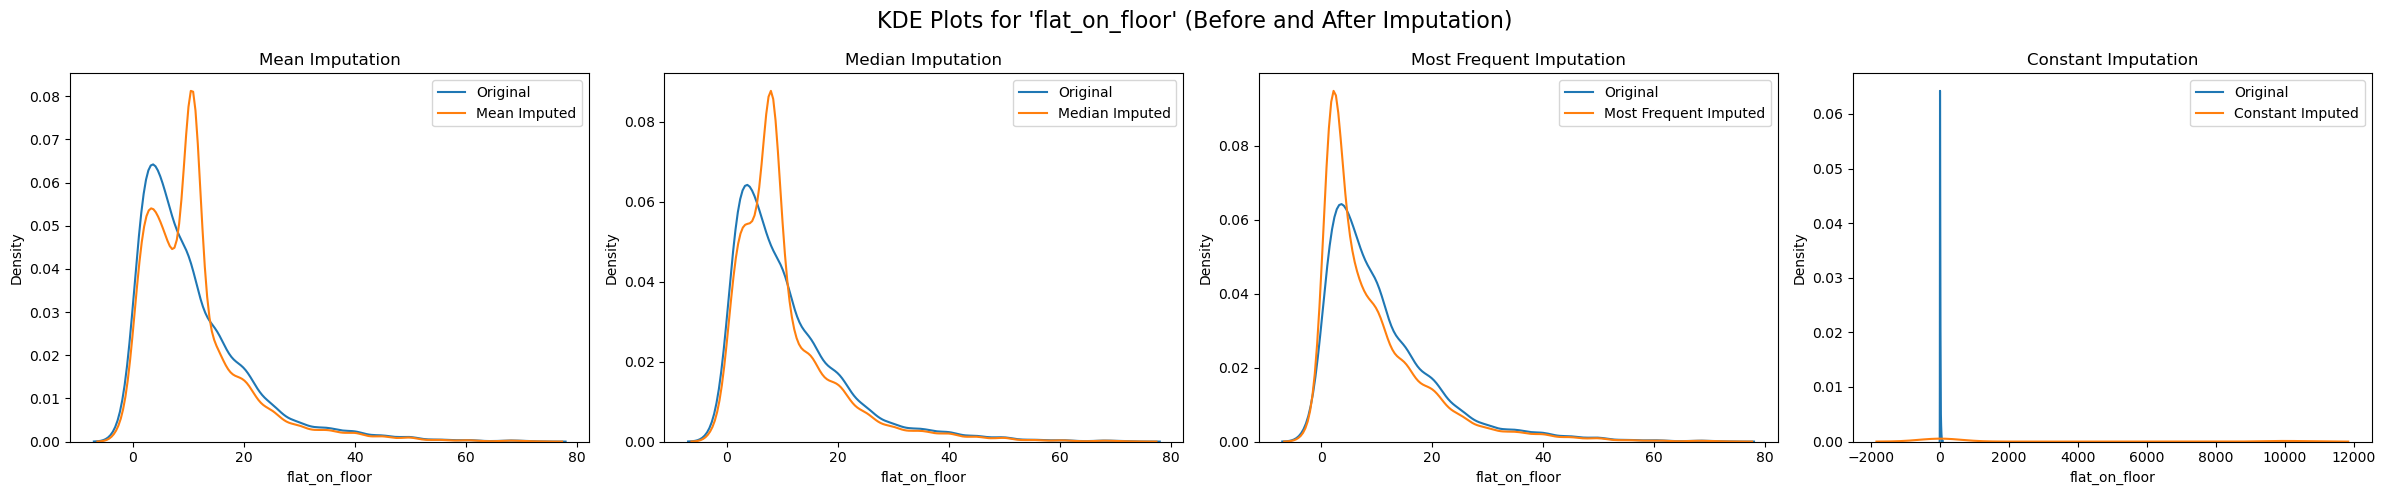

In [136]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'flat_on_floor', constant_value=9999)
plot_kde_imputations(X_train, 'flat_on_floor')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


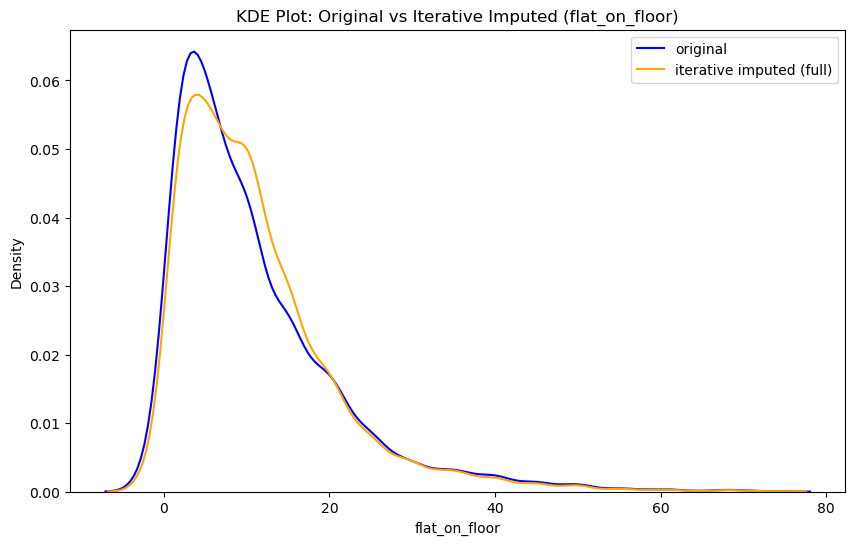

In [137]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'flat_on_floor')

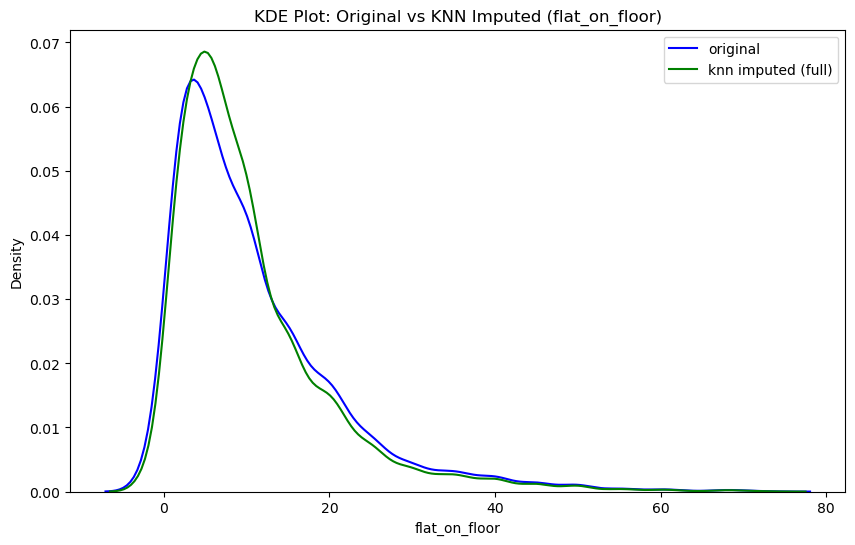

In [138]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'flat_on_floor')

In [139]:
print("Original:\n", X_train['flat_on_floor'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['flat_on_floor'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['flat_on_floor'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    7663.000000
mean       10.823046
std        10.029193
min        -2.000000
25%         4.000000
50%         8.000000
75%        15.000000
max        73.000000
Name: flat_on_floor, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       10.362390
std         9.300778
min        -2.000000
25%         4.000000
50%         8.000000
75%        14.000000
max        73.000000
Name: flat_on_floor, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       11.082059
std         9.469168
min        -2.193134
25%         4.000000
50%         9.000000
75%        15.000000
max        73.000000
Name: flat_on_floor, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       10.823046
std         9.100785
min        -2.000000
25%         5.000000
50%        10.000000
75%        13.000000
max        73.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean       10.324629
std         9.164227
min        -2.000000
25%         5.000000
50%         8.0

`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### total_floor

In [140]:
describe_and_missing(X_train, 'total_floor')


--- Description for 'total_floor' ---
count    7854.000000
mean       22.176980
std        16.157351
min         1.000000
25%         8.000000
50%        19.000000
75%        30.000000
max        92.000000
Name: total_floor, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'total_floor': 1452


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

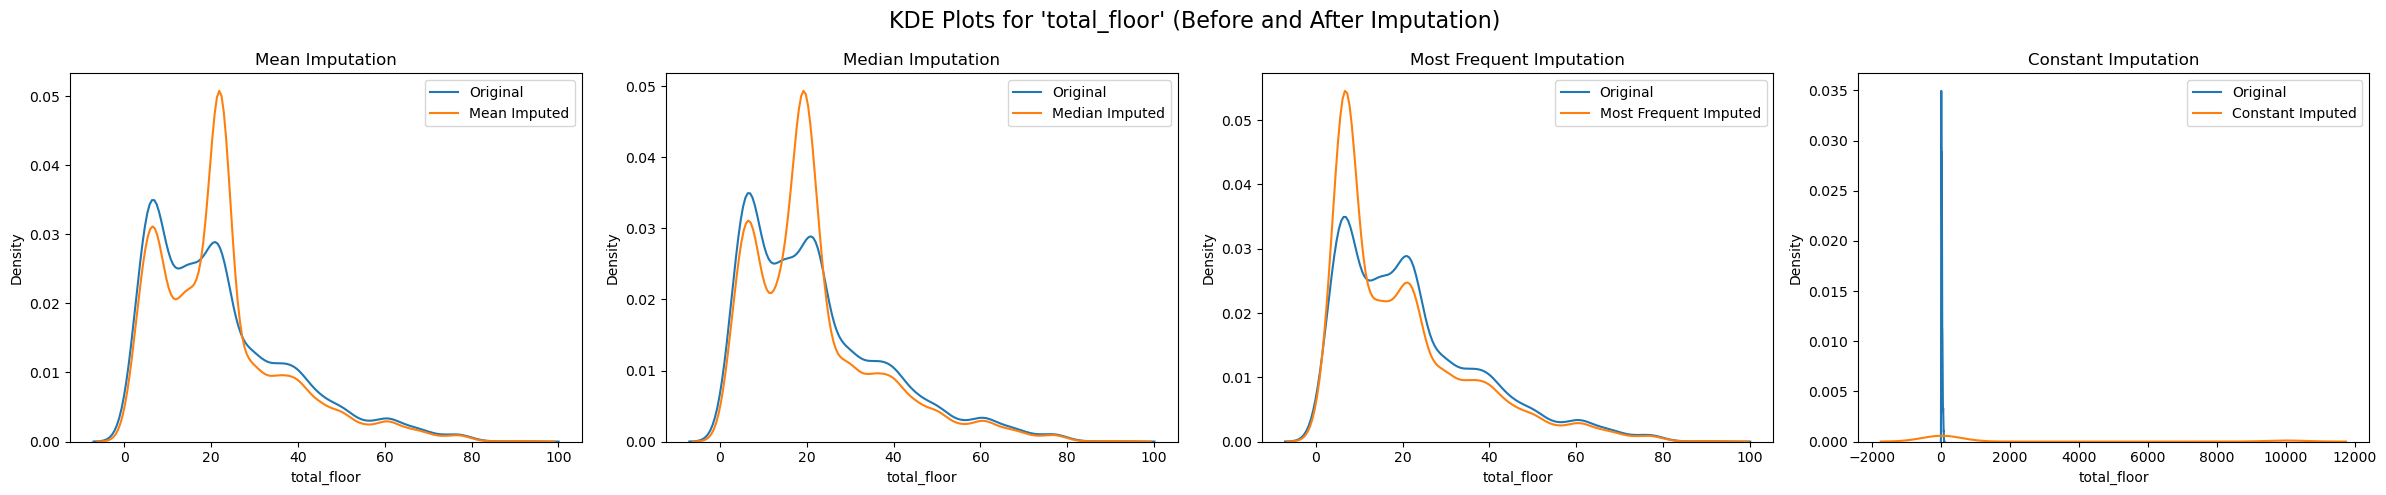

In [141]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'total_floor', constant_value=9999)
plot_kde_imputations(X_train, 'total_floor')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


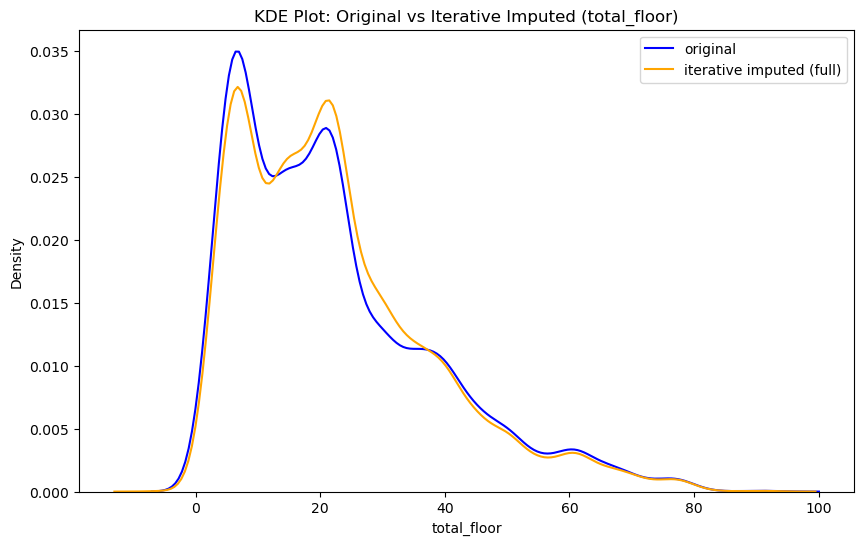

In [142]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'total_floor')

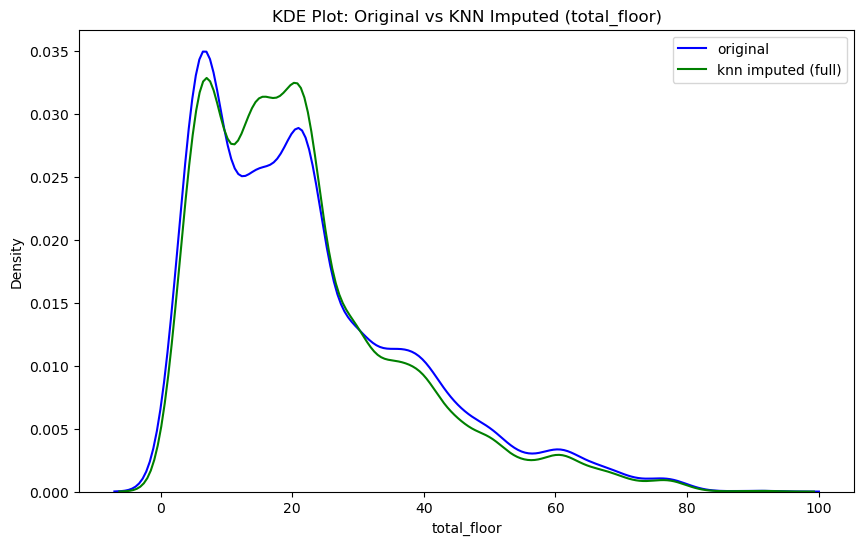

In [143]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'total_floor')

In [144]:
print("Original:\n", X_train['total_floor'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['total_floor'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['total_floor'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    7854.000000
mean       22.176980
std        16.157351
min         1.000000
25%         8.000000
50%        19.000000
75%        30.000000
max        92.000000
Name: total_floor, dtype: float64 

KNN Imputed:
 count    9306.000000
mean       21.598259
std        15.140123
min         1.000000
25%        10.000000
50%        18.600000
75%        28.400000
max        92.000000
Name: total_floor, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean       22.498240
std        15.576659
min        -5.554896
25%        10.000000
50%        20.000000
75%        30.000000
max        92.000000
Name: total_floor, dtype: float64 

Mean Imputed:
 count    9306.000000
mean       22.176980
std        14.843276
min         1.000000
25%        11.000000
50%        22.000000
75%        27.000000
max        92.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean       21.681281
std        14.887985
min         1.000000
25%        11.000000
50%        19.000000


`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### bath

In [145]:
describe_and_missing(X_train, 'bath')


--- Description for 'bath' ---
count    9280.000000
mean        2.317996
std         0.965433
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: bath, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'bath': 26


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

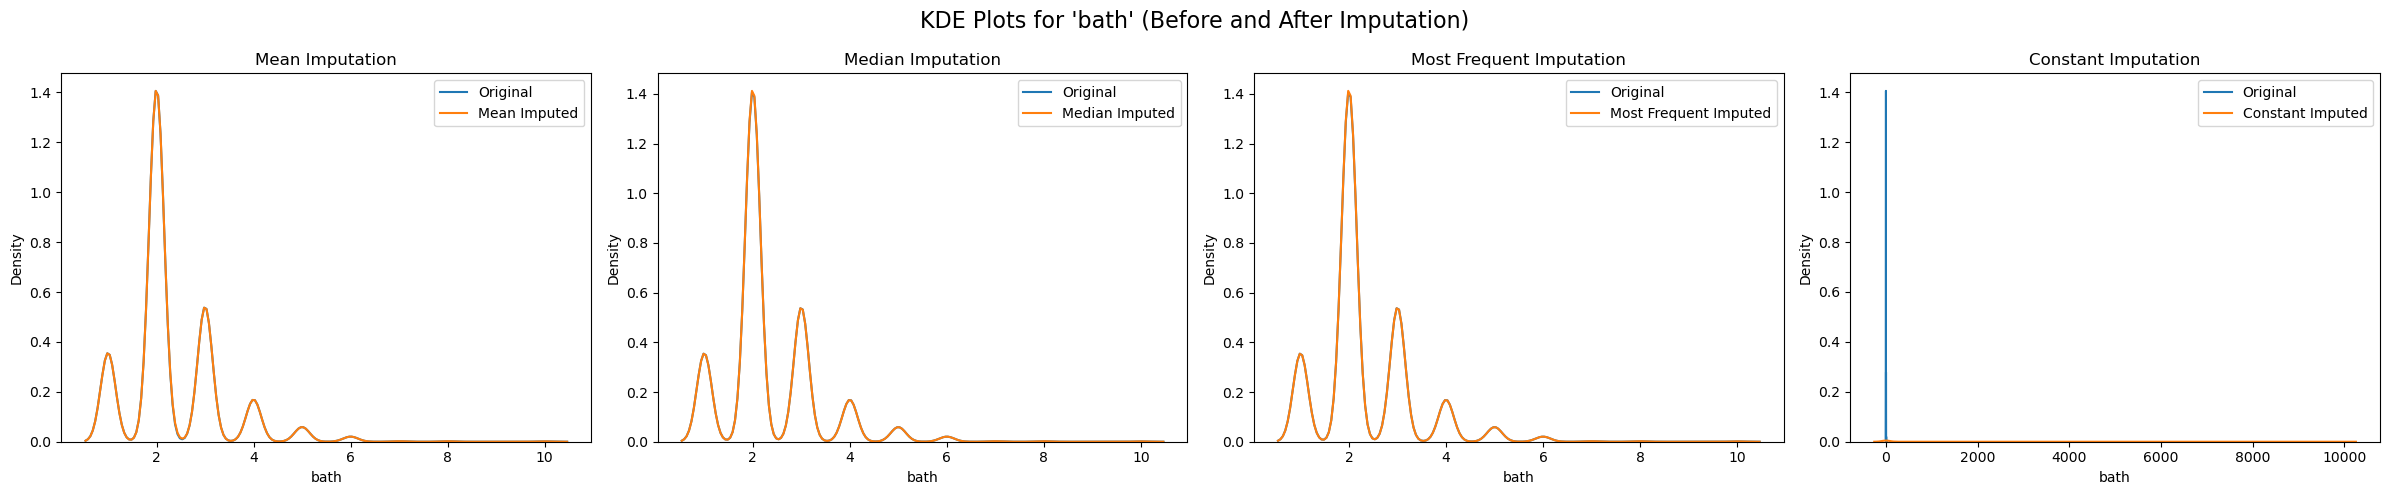

In [146]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'bath', constant_value=9999)
plot_kde_imputations(X_train, 'bath')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


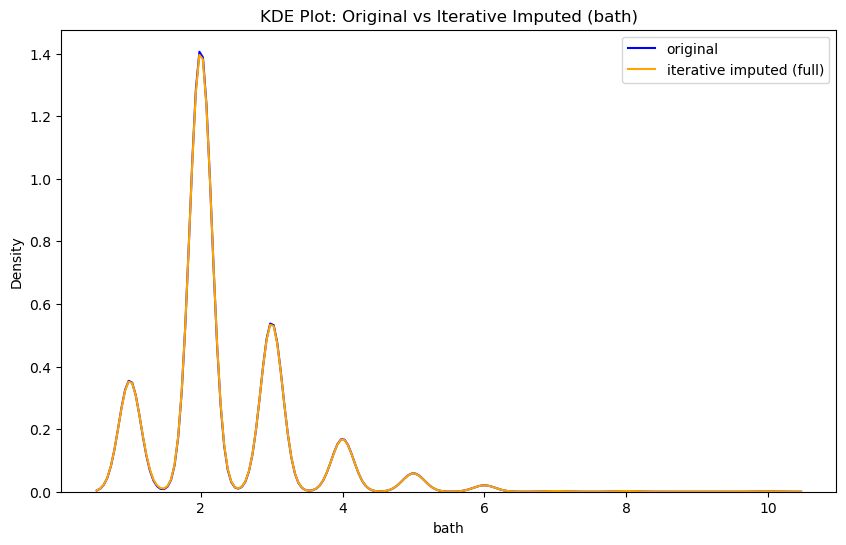

In [147]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'bath')

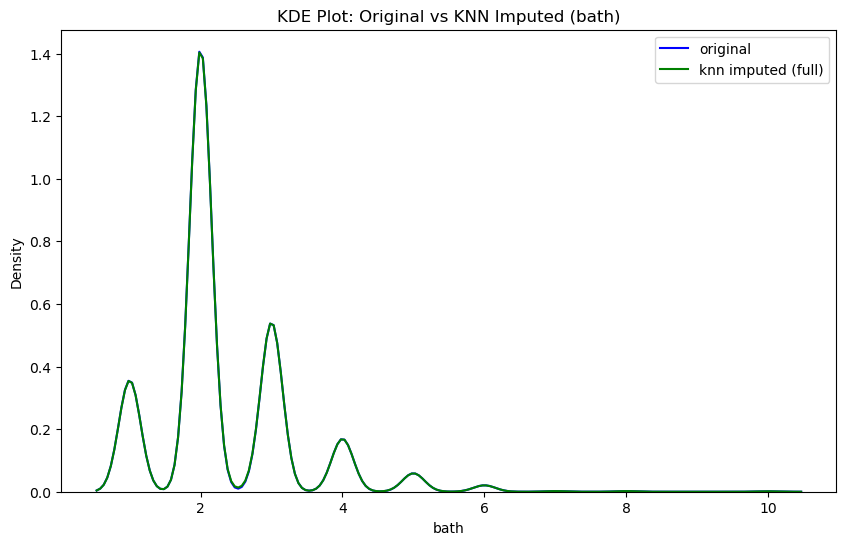

In [148]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'bath')

In [149]:
print("Original:\n", X_train['bath'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['bath'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['bath'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    9280.000000
mean        2.317996
std         0.965433
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: bath, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.319256
std         0.965303
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: bath, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.318571
std         0.970364
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: bath, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.317996
std         0.964083
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        10.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        2.317107
std         0.964229
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000


`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.

### balcony

In [150]:
describe_and_missing(X_train, 'balcony')


--- Description for 'balcony' ---
count    4746.000000
mean        1.859461
std         1.056194
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: balcony, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'balcony': 4560


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

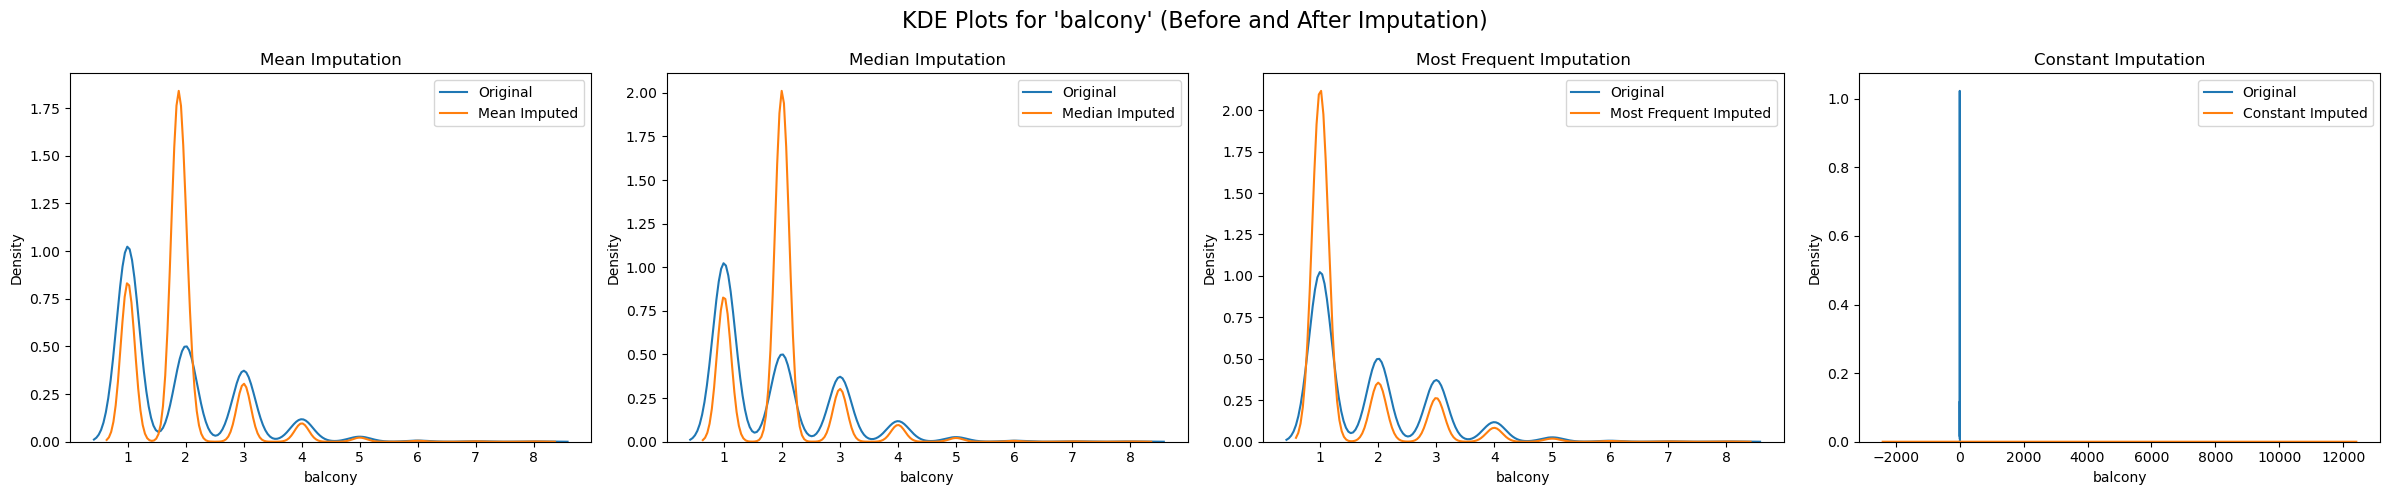

In [151]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'balcony', constant_value=9999)
plot_kde_imputations(X_train, 'balcony')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


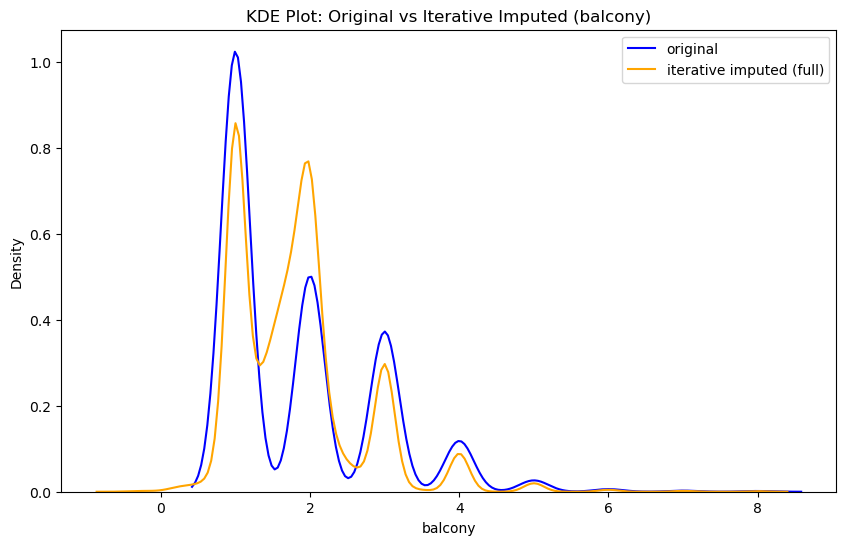

In [152]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'balcony')

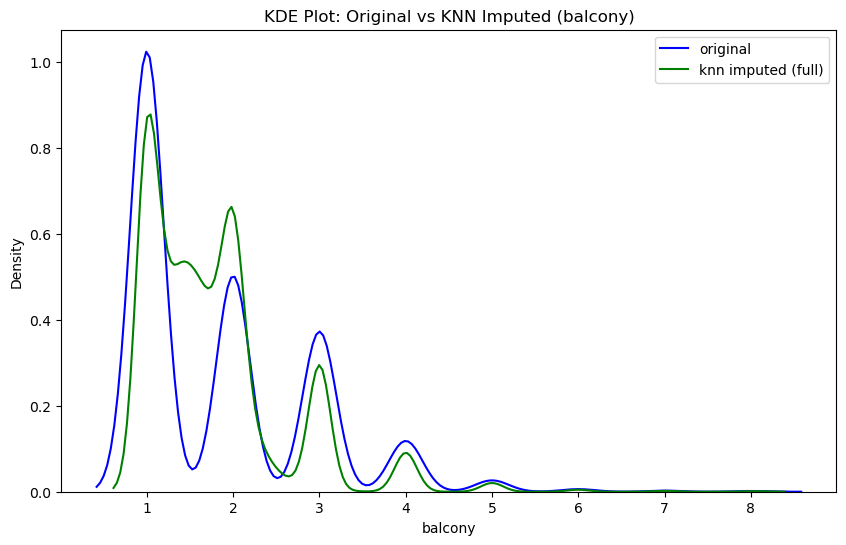

In [153]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'balcony')

In [154]:
print("Original:\n", X_train['balcony'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['balcony'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['balcony'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    4746.000000
mean        1.859461
std         1.056194
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         8.000000
Name: balcony, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        1.756265
std         0.803057
min         1.000000
25%         1.000000
50%         1.600000
75%         2.000000
max         8.000000
Name: balcony, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        1.796647
std         0.826927
min        -0.462622
25%         1.000000
50%         1.745305
75%         2.000000
max         8.000000
Name: balcony, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        1.859461
std         0.754229
min         1.000000
25%         1.000000
50%         1.859461
75%         2.000000
max         8.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.928326
std         0.757495
min         1.000000
25%         1.000000
50%         2.000000
75%         

`observation`

- KNN works well
- as using KNN distribution is shifted, so use another method like missing indicator in next experiment 

### lift

In [155]:
describe_and_missing(X_train, 'lift')


--- Description for 'lift' ---
count    5151.000000
mean        3.107164
std         1.708849
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: lift, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'lift': 4155


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

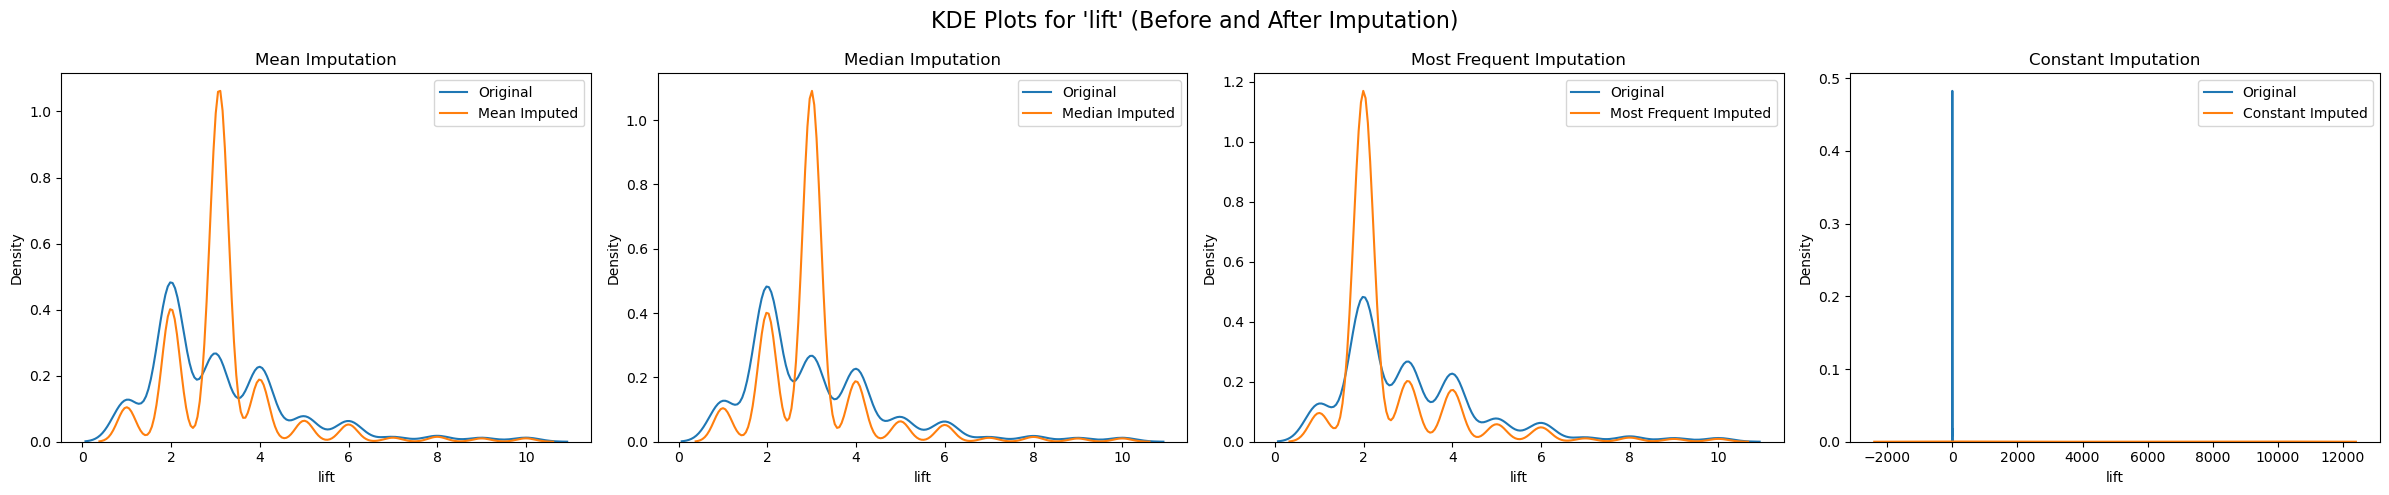

In [156]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'lift', constant_value=9999)
plot_kde_imputations(X_train, 'lift')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


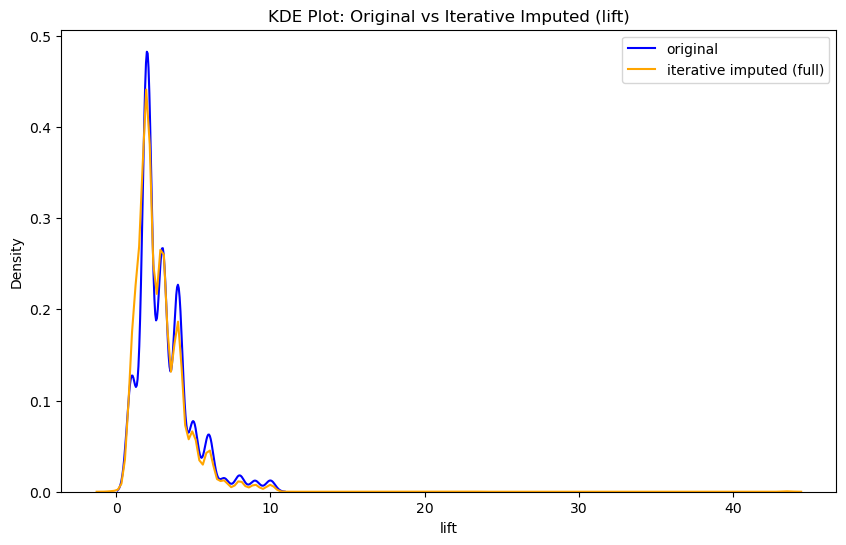

In [157]:
#approach B
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'lift')

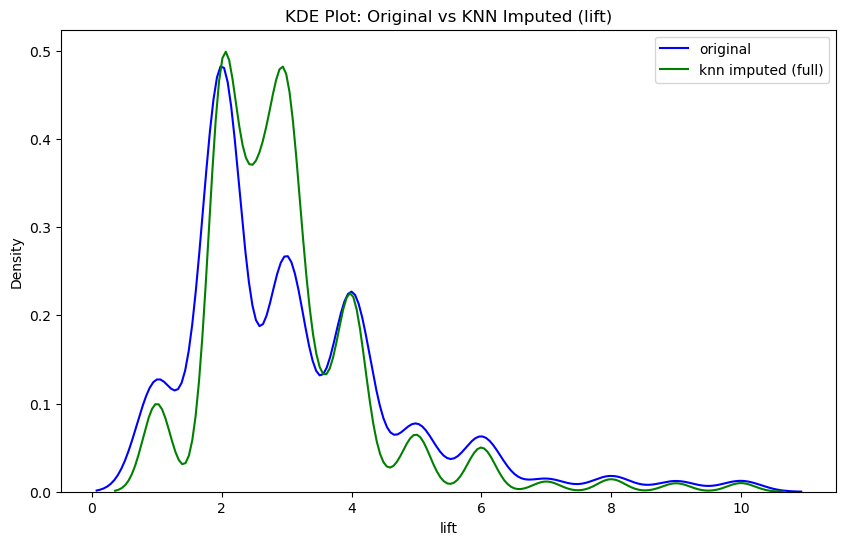

In [158]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'lift')

In [159]:
print("Original:\n", X_train['lift'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['lift'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['lift'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5151.000000
mean        3.107164
std         1.708849
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: lift, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.986697
std         1.333972
min         1.000000
25%         2.000000
50%         2.800000
75%         3.400000
max        10.000000
Name: lift, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.852184
std         1.722976
min        -0.445239
25%         2.000000
50%         2.383242
75%         3.669487
max        43.610487
Name: lift, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        3.107164
std         1.271303
min         1.000000
25%         2.000000
50%         3.107164
75%         3.107164
max        10.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        3.059317
std         1.272419
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000


`observation`

- median works well

### parking

In [160]:
describe_and_missing(X_train, 'parking')


--- Description for 'parking' ---
count    4549.000000
mean        2.638382
std        22.638328
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       813.000000
Name: parking, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'parking': 4757


`observation`
- mean and median values are different lets impute using simple imputer and check kdeplot

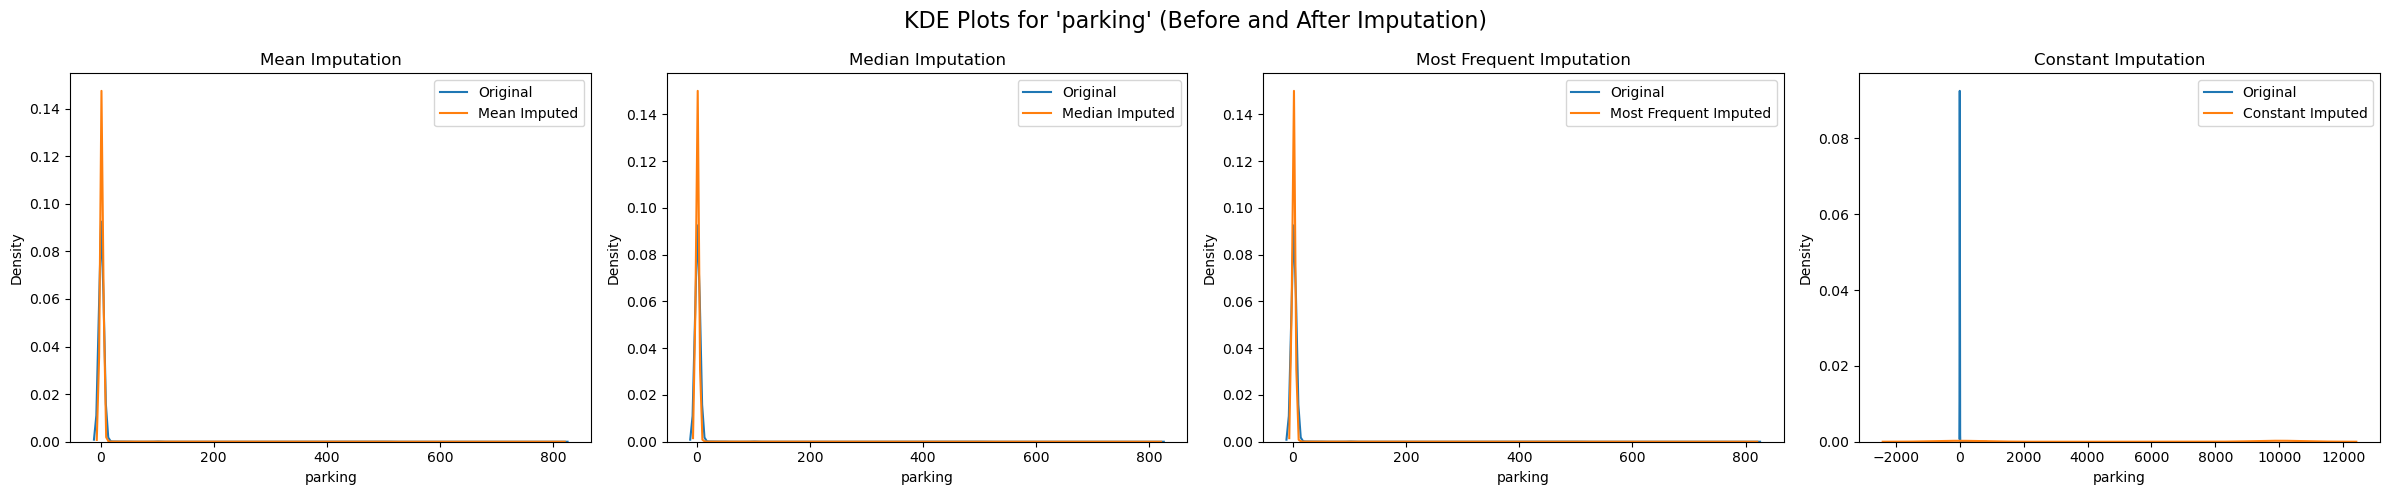

In [161]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'parking', constant_value=9999)
plot_kde_imputations(X_train, 'parking')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


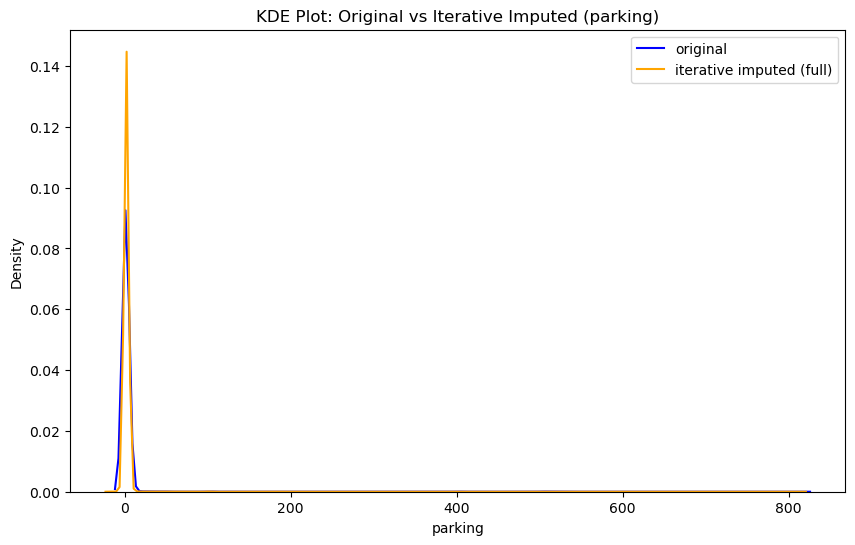

In [162]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'parking')

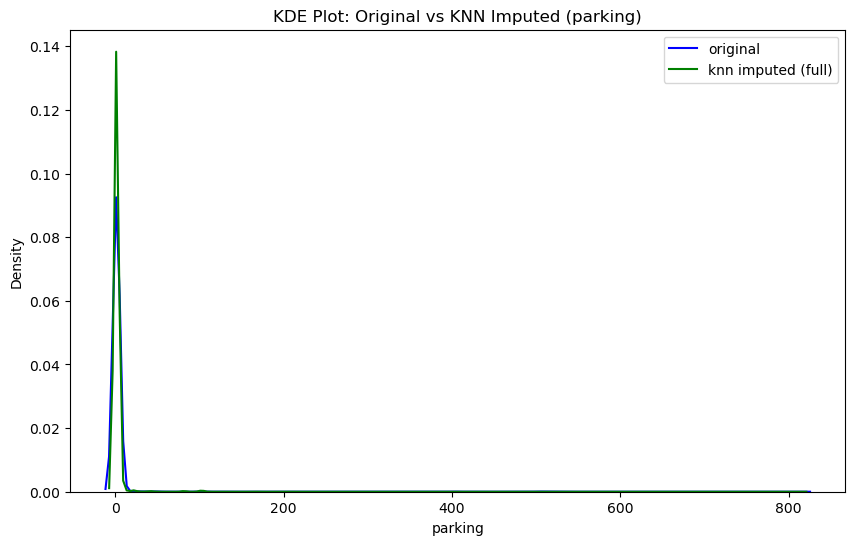

In [163]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'parking')

In [164]:
print("Original:\n", X_train['parking'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['parking'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['parking'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    4549.000000
mean        2.638382
std        22.638328
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       813.000000
Name: parking, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.569826
std        17.161222
min         1.000000
25%         1.000000
50%         1.400000
75%         1.600000
max       813.000000
Name: parking, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.715026
std        15.836188
min       -15.375782
25%         1.000000
50%         2.053992
75%         2.935022
max       813.000000
Name: parking, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.638382
std        15.826919
min         1.000000
25%         1.000000
50%         2.638382
75%         2.638382
max       813.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean        1.800881
std        15.848097
min         1.000000
25%         1.000000
50%         1.000000
75%         

`observation`

- both KNN and median works well but KNN is slightly better 
- Try different n_neighbors and weights:uniform and distance to further improve KNN results.
- also try missing indicator

`observation`

The following columns have no missing values
- `bed`
- `education_within_2km`
- `transport_within_2km`
- `shopping_centre_within_2km`
- `commercial_hub_within_2km`
- `hospital_within_2km`
- `tourist_within_2km`
- `total_within_2km`

Conclusion: No imputation needed for these columns. Data is complete and consistent.


## Analysis on nominal_cat_cols

so we can use this methods for impute categorical col  
1)most-frequent    
2)constant  
3)KNN Imputer - for this we have to first convert the cat column into numerical   
4)Iterative Imputer - for this we have to first convert the cat column into numerical    
5)Custom Rules - Based on domain knowledge, Example: fill missing City based on Zipcode or Location

In [165]:
nominal_cat_cols = ['builder','project_name','location','city','property_type','ownership','overlooking','facing','flooring','extra_rooms','seller']

### builder

In [166]:
X_train['builder'].value_counts()

builder
lodha group                    365
godrej properties              207
rustomjee                      184
piramal realty                 179
oberoi realty ltd.             149
                              ... 
aditi realtors                   1
prima terra buildtech            1
excel enterprises                1
prabhat developers               1
siddhivinayak constructions      1
Name: count, Length: 1030, dtype: int64

In [64]:
df['builder'].unique().shape

(1144,)

In [167]:
X_train['builder'].isna().sum()

3432

Observation:

To impute missing values in the `builder` column using the `project_name` column, we apply the following rule:

For example:

|builder     | project\_name |
|----------- | ------------- |
|lodha       | pebble        |
|rustomjee   | vinayak       |
|lodha       | pebble        |
|excel group | vinayak       |
|**NaN**     | pebble        |
|**NaN**     | vinayak       |

After applying the logic:  

| builder     | project\_name |
| ----------- | ------------- |
| lodha       | pebble        |
| rustomjee   | vinayak       |
| lodha       | pebble        |
| excel group | vinayak       |
| **lodha**   | pebble        |
| **NaN**     | vinayak       |  

Here, `pebble` is uniquely associated with `lodha`, so the missing builder is filled as `lodha`.  
However, `vinayak` is linked to both `rustomjee` and `excel group`, so the missing value remains unfilled.  


In [168]:
# Step 1: Group project_name by builder and count unique builders
project_to_builder = (
    df.dropna(subset=['builder', 'project_name'])
      .groupby('project_name')['builder']
      .nunique()
)

# Step 2: Filter only project_names with one unique builder
valid_projects = project_to_builder[project_to_builder == 1].index

# Step 3: Map project_name to builder where project_name is unique
project_to_unique_builder = (
    df[df['project_name'].isin(valid_projects)]
    .dropna(subset=['builder'])
    .drop_duplicates(subset=['project_name'])
    .set_index('project_name')['builder']
)

# Step 4: Fill missing builders
df['builder'] = df.apply(
    lambda row: project_to_unique_builder[row['project_name']]
    if pd.isna(row['builder']) and row['project_name'] in project_to_unique_builder
    else row['builder'],
    axis=1
)

In [169]:
X_train['builder'].isna().sum()

3432

`observation`
- Found nothing significant after grouping project_name by builder and counting unique builders.
- KNN and Iterative Imputer won't work as we don't have a numerical column; mode is also not feasible due to the absence of a dominating category.
- So, impute using 'missing', then keep the top 200 most frequent categories, and finally apply target encoding.

In [41]:
# Sample: X_train = your DataFrame, 'builder' = categorical col, 'price' = target col

# 1. Impute missing with 'missing'
X_train['builder'] = X_train['builder'].fillna('missing')

# 2. Get top 200 categories
top_200 = X_train['builder'].value_counts().nlargest(200).index

# 3. Replace others with 'other'
X_train['builder'] = X_train['builder'].apply(lambda x: x if x in top_200 else 'other')

# 4. Target Encoding
encoder = TargetEncoder(cols=['builder'])
X_train['builder_encoded'] = encoder.fit_transform(X_train['builder'], y_train)

# Optional: drop original if needed
# X_train.drop('builder', axis=1, inplace=True)


In [43]:
describe_and_missing(X_train, 'builder_encoded')


--- Description for 'builder_encoded' ---
count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
Name: builder_encoded, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'builder_encoded': 0


`observation`
- mean and median values are different
- 3432 missing values
- Try different min_samples_leaf and smoothing in target encoding to further improve results. 

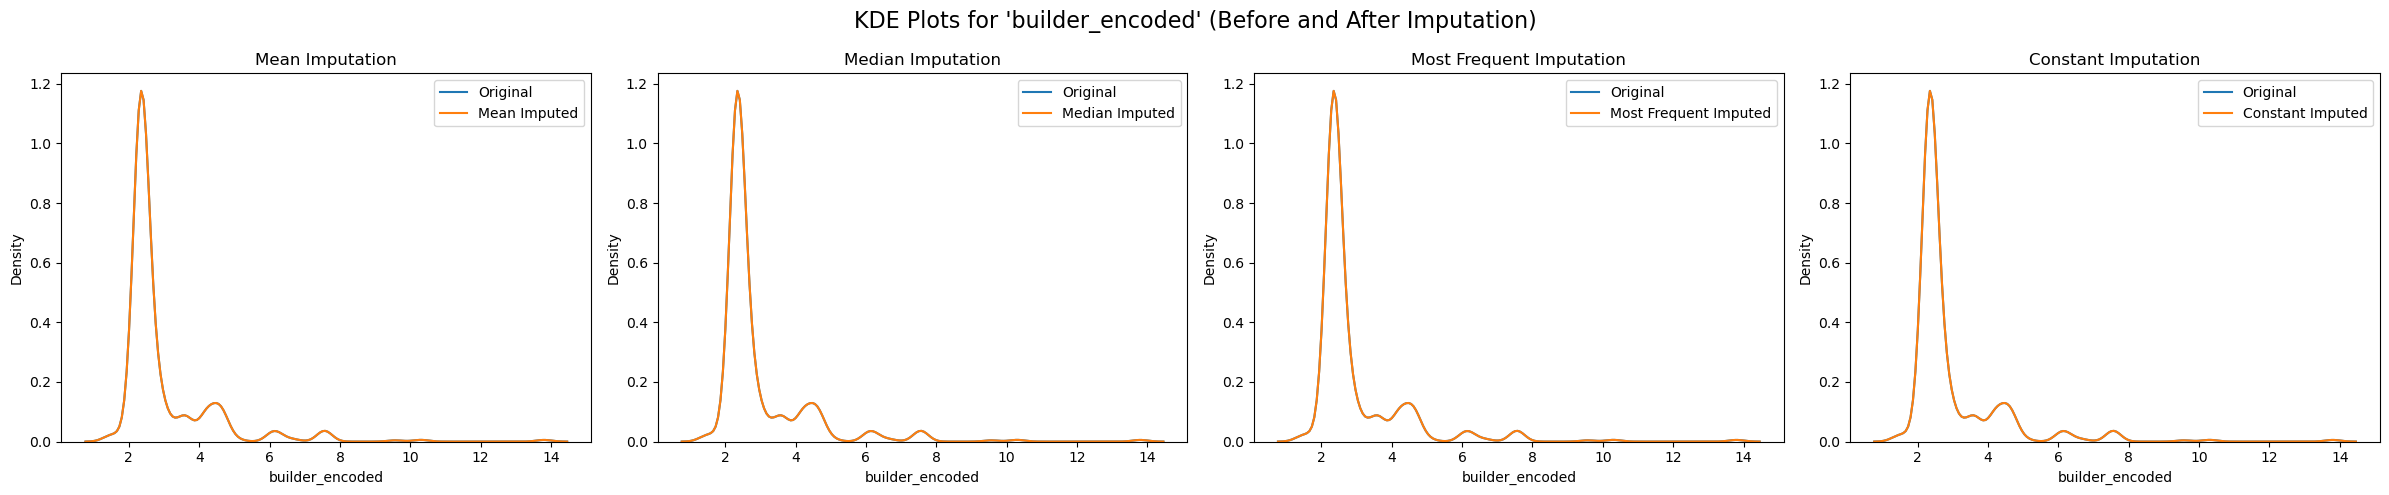

In [44]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'builder_encoded', constant_value=9999)
plot_kde_imputations(X_train, 'builder_encoded')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


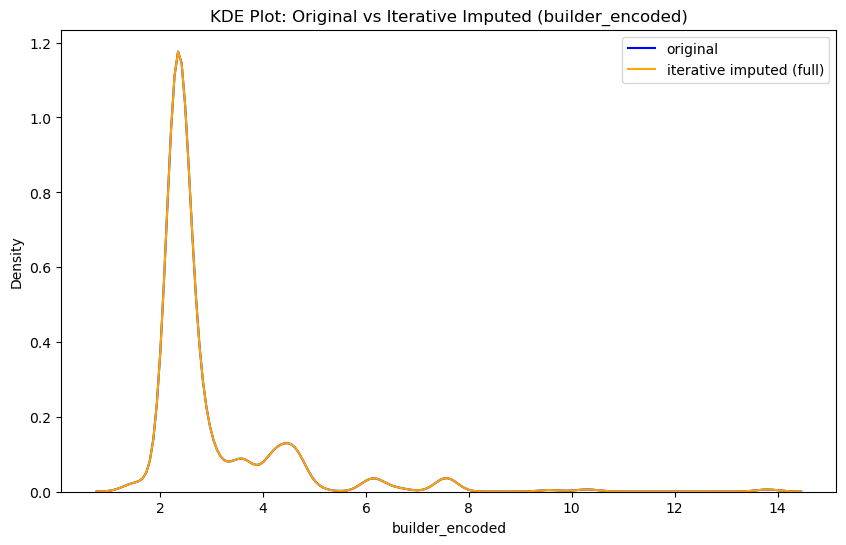

In [45]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'builder_encoded')

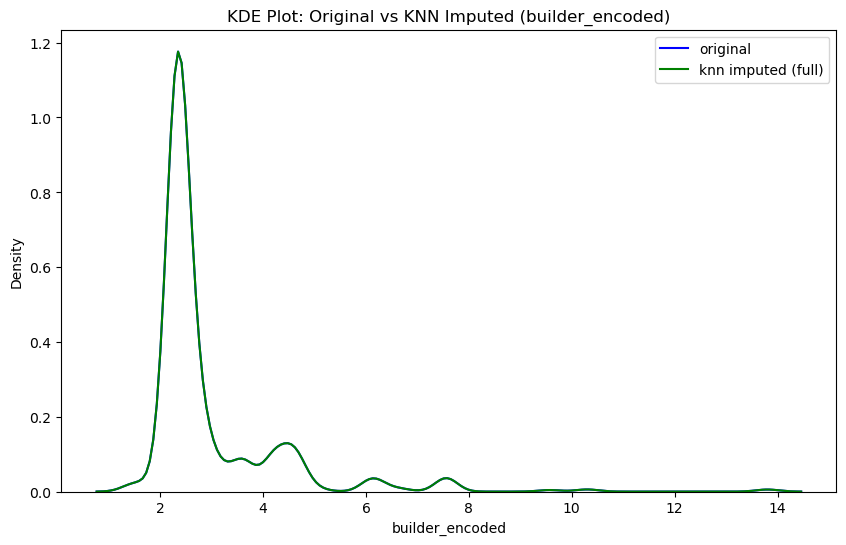

In [46]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'builder_encoded')

In [48]:
print("Original:\n", X_train['builder_encoded'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['builder_encoded'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['builder_encoded'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
Name: builder_encoded, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
Name: builder_encoded, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
Name: builder_encoded, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
dtype: float64 

Median Imputed:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%      

`observation`
- Impute using 'missing', then keep the top 200 most frequent categories, and finally apply target encoding.

### project_name 

In [32]:
X_train.shape

(9306, 49)

In [33]:
X_train['project_name'].value_counts()

project_name
oberoi sky city                         71
piramal vaikunth                        68
tata serein                             57
piramal mahalaxmi                       55
omkar alta monte                        54
                                        ..
dushyant cooperative housing society     1
rambha tower                             1
bhoomi valley                            1
panchamrut chs                           1
dev darshan                              1
Name: count, Length: 2578, dtype: int64

In [34]:
X_train['project_name'].isna().sum()

2794

In [35]:
# Sample: X_train = your DataFrame, 'project_name' = categorical col, 'price' = target col

# 1. Impute missing with 'missing'
X_train['project_name'] = X_train['project_name'].fillna('missing')

# 2. Get top 200 categories
top_200 = X_train['project_name'].value_counts().nlargest(200).index

# 3. Replace others with 'other'
X_train['project_name'] = X_train['project_name'].apply(lambda x: x if x in top_200 else 'other')

# 4. Target Encoding
encoder = TargetEncoder(cols=['project_name'])
X_train['project_name_encoded'] = encoder.fit_transform(X_train['project_name'], y_train)

# Optional: drop original if needed
# X_train.drop('project_name', axis=1, inplace=True)


In [40]:
# pd.set_option('display.max_rows', None)
# print(X_train['project_name_encoded'].value_counts())

In [36]:
describe_and_missing(X_train, 'project_name_encoded')


--- Description for 'project_name_encoded' ---
count    9306.000000
mean        2.842966
std         1.335770
min         1.304996
25%         2.282073
50%         2.794762
75%         2.794762
max        15.646208
Name: project_name_encoded, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'project_name_encoded': 0


`observation`
- mean and median values are different
- 3432 missing values
- Try different min_samples_leaf and smoothing in target encoding to further improve results. 

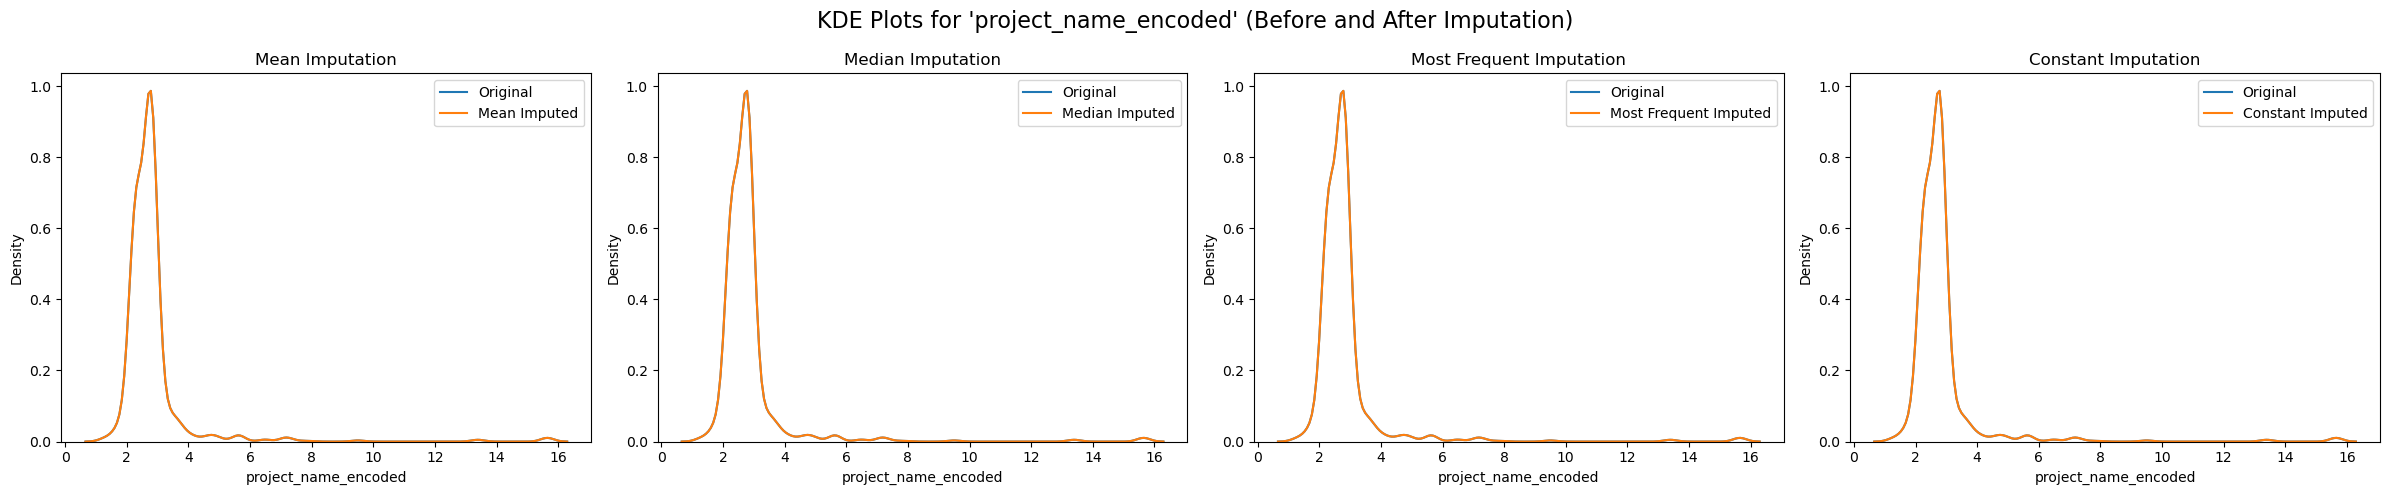

In [37]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'project_name_encoded', constant_value=9999)
plot_kde_imputations(X_train, 'project_name_encoded')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


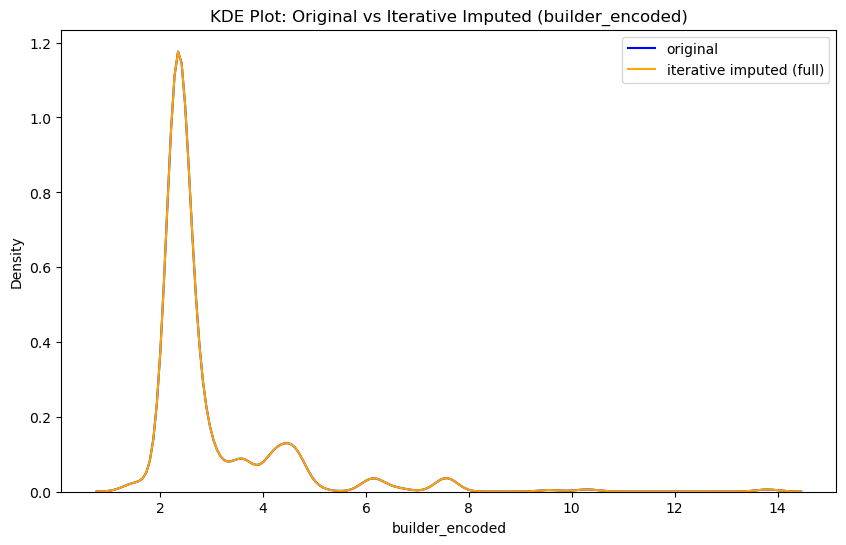

In [45]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'project_name_encoded')

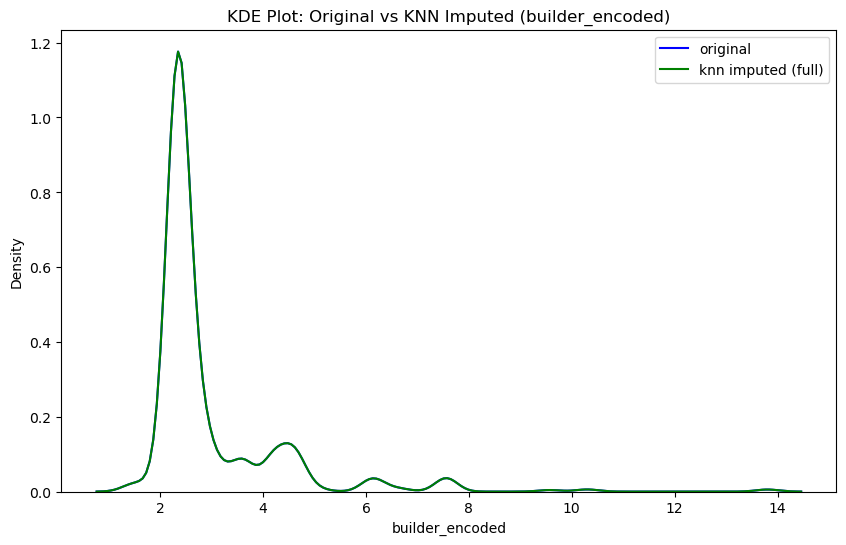

In [46]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'project_name_encoded')

In [48]:
print("Original:\n", X_train['project_name_encoded'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['project_name_encoded'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['project_name_encoded'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
Name: builder_encoded, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
Name: builder_encoded, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
Name: builder_encoded, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%         2.352493
75%         2.875791
max        13.801272
dtype: float64 

Median Imputed:
 count    9306.000000
mean        2.958288
std         1.360841
min         1.421968
25%         2.352493
50%      

`observation`
- Impute using 'missing', then keep the top 200 most frequent categories, and finally apply target encoding.

### location

In [42]:
X_train['location'].value_counts()

location
mulund west                                  268
andheri west                                 215
kandivali east                               213
kharghar                                     199
andheri east                                 196
powai                                        190
malad west                                   189
chembur                                      180
goregaon west                                177
panvel                                       167
kandivali west                               151
borivali east                                150
mira road east                               142
malad east                                   128
majiwada                                     125
goregaon east                                120
worli                                        119
ghodbunder road                              117
thane west                                   115
borivali west                                113
ghatkopar e

In [43]:
X_train['location'].isna().sum()

385

In [44]:
# Sample: X_train = your DataFrame, 'location' = categorical col, 'price' = target col

# 1. Impute missing with 'missing'
X_train['location'] = X_train['location'].fillna('missing')

# 2. Get top 200 categories
top_200 = X_train['location'].value_counts().nlargest(200).index

# 3. Replace others with 'other'
X_train['location'] = X_train['location'].apply(lambda x: x if x in top_200 else 'other')

# 4. Target Encoding
encoder = TargetEncoder(cols=['location'])
X_train['location_encoded'] = encoder.fit_transform(X_train['location'], y_train)

# Optional: drop original if needed
# X_train.drop('location', axis=1, inplace=True)


In [52]:
# pd.set_option('display.max_rows', None)
# print(X_train['location_encoded'].value_counts())

In [45]:
describe_and_missing(X_train, 'location_encoded')


--- Description for 'location_encoded' ---
count    9306.000000
mean        2.931836
std         2.299726
min         0.434153
25%         1.652442
50%         2.437836
75%         3.253953
max        14.083584
Name: location_encoded, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'location_encoded': 0


`observation`
- mean and median values are different
- 3432 missing values
- Try different min_samples_leaf and smoothing in target encoding to further improve results. 

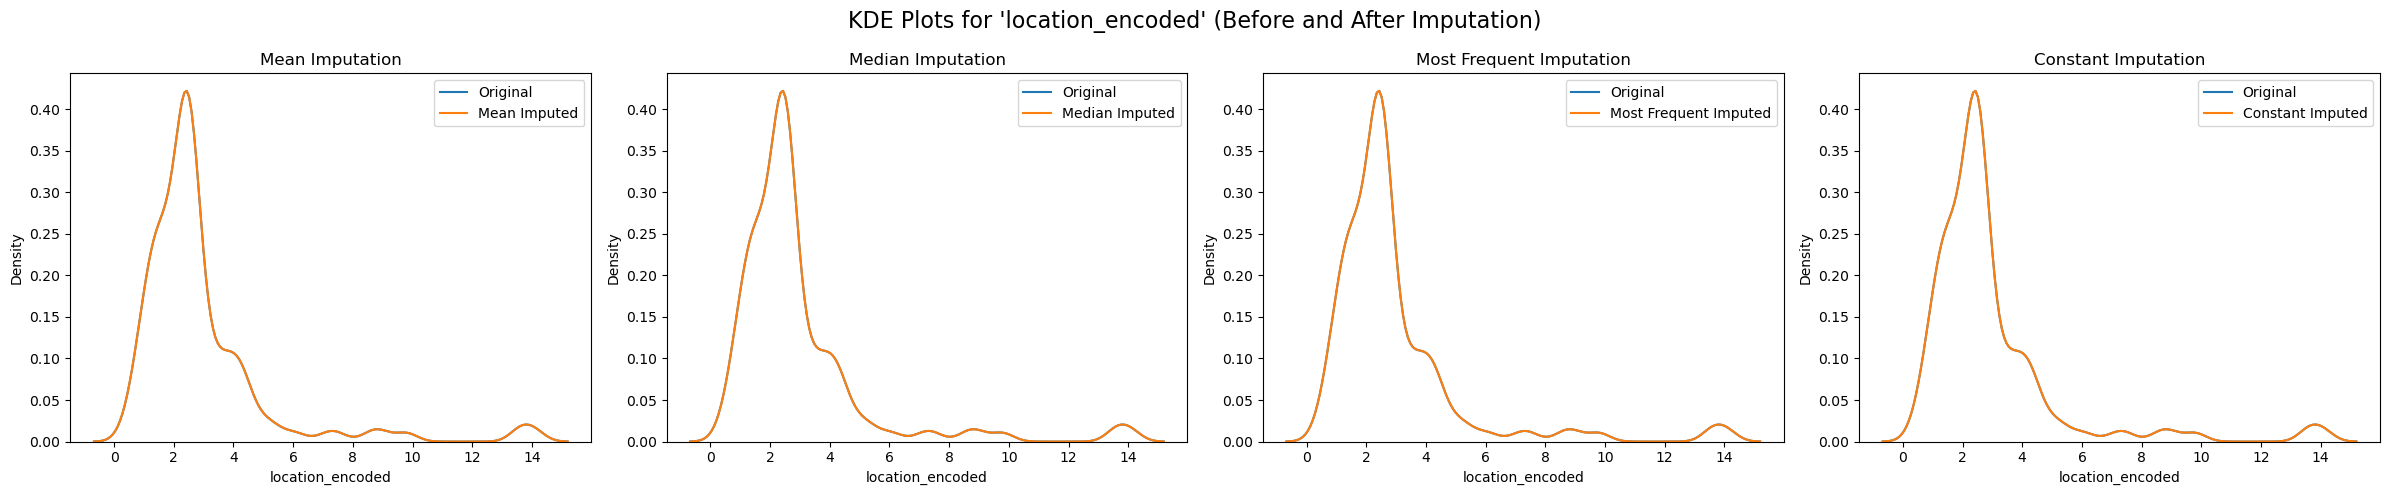

In [46]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'location_encoded', constant_value=9999)
plot_kde_imputations(X_train, 'location_encoded')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


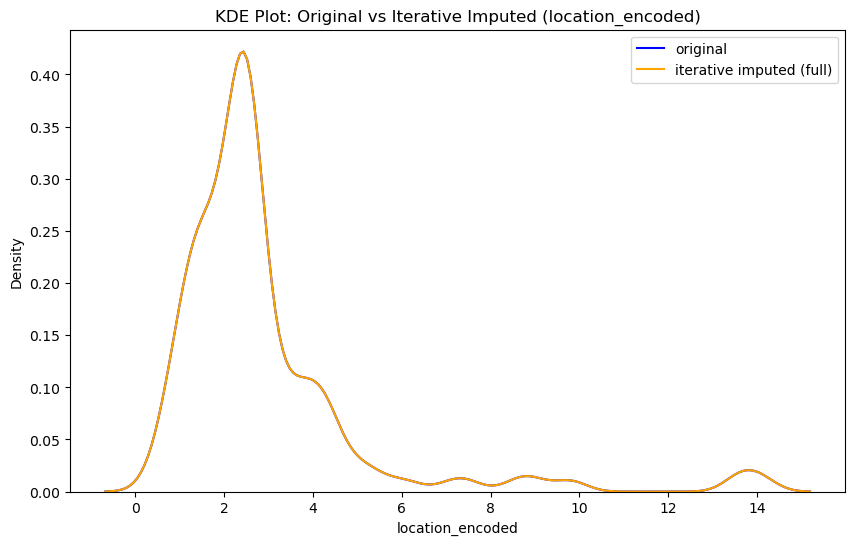

In [47]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'location_encoded')

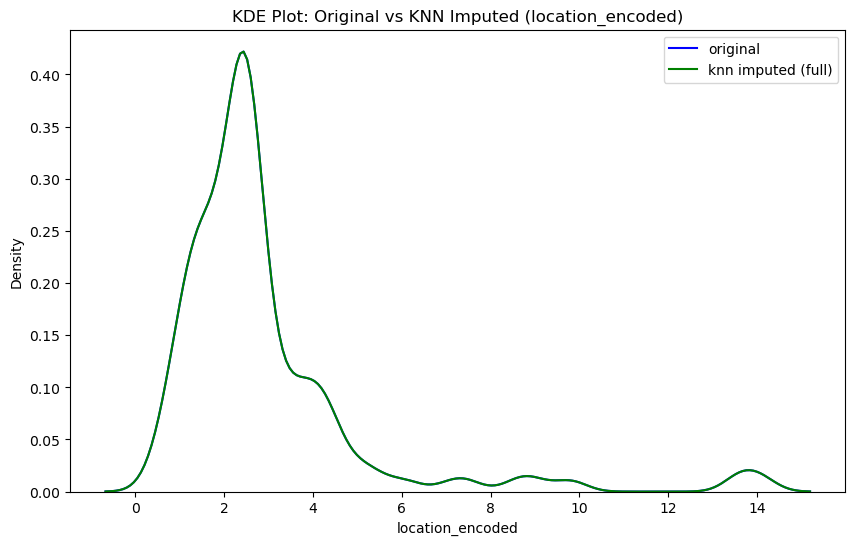

In [48]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'location_encoded')

In [49]:
print("Original:\n", X_train['location_encoded'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['location_encoded'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['location_encoded'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    9306.000000
mean        2.931836
std         2.299726
min         0.434153
25%         1.652442
50%         2.437836
75%         3.253953
max        14.083584
Name: location_encoded, dtype: float64 

KNN Imputed:
 count    9306.000000
mean        2.931836
std         2.299726
min         0.434153
25%         1.652442
50%         2.437836
75%         3.253953
max        14.083584
Name: location_encoded, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean        2.931836
std         2.299726
min         0.434153
25%         1.652442
50%         2.437836
75%         3.253953
max        14.083584
Name: location_encoded, dtype: float64 

Mean Imputed:
 count    9306.000000
mean        2.931836
std         2.299726
min         0.434153
25%         1.652442
50%         2.437836
75%         3.253953
max        14.083584
dtype: float64 

Median Imputed:
 count    9306.000000
mean        2.931836
std         2.299726
min         0.434153
25%         1.652442
50%   

`observation`
- Impute using 'missing', then keep the top 200 most frequent categories, and finally apply target encoding.

### property_type

In [196]:
X_train['property_type'].value_counts()

property_type
resale          5381
new property    3923
Name: count, dtype: int64

In [197]:
X_train['property_type'].isna().sum()

2

`observation`

- have only 2 missing values and one dominant category hence use mode for imputation 

In [198]:
X_train['property_type'].mode()[0]

'resale'

Data shape: (9306, 49)
Missing values in 'property_type': 2
Mode: resale


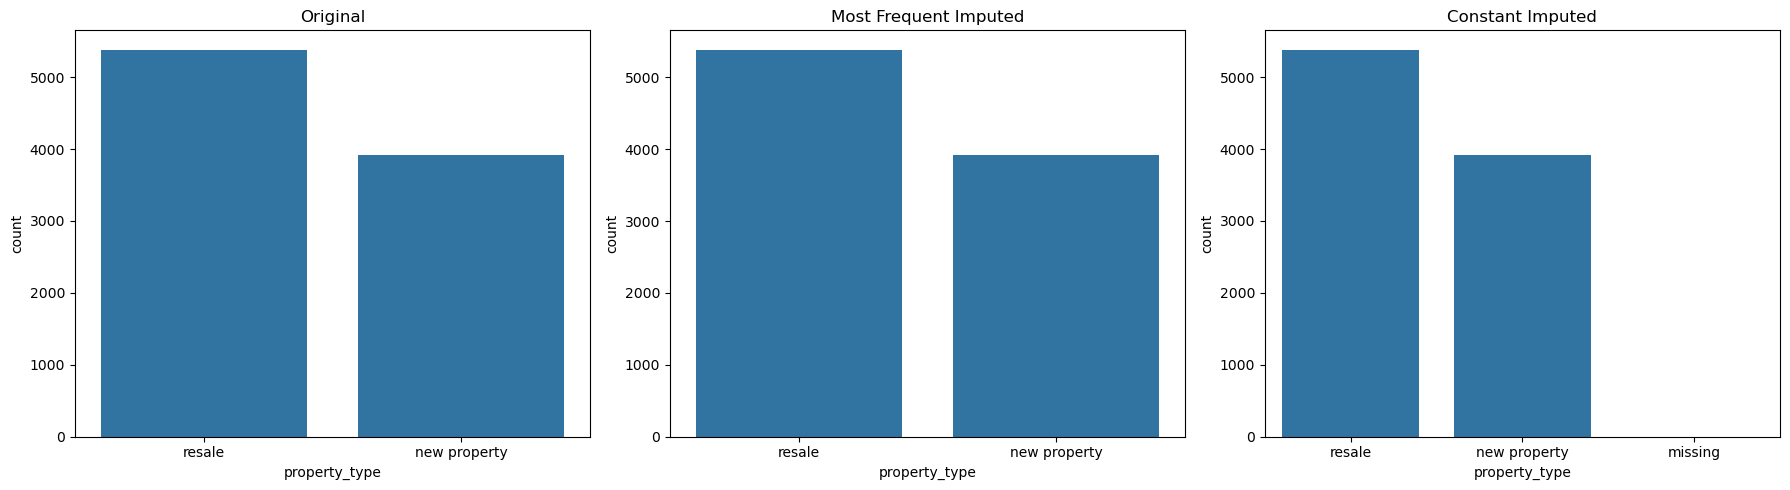

In [199]:
plot_categorical_imputations(X_train, 'property_type')

`observation`
- After using most_frequent (i.e.mode), the distribution remains almost the same. Hence, we can apply mode imputation on the property_type column.

In [200]:
#applying ohe
X_train = pd.get_dummies(X_train, columns=['property_type'], drop_first=False)
#property_type will be dropped automatically, and replaced by new one hot encoded columns

`observation`

- mode and then OHE

### ownership

In [201]:
X_train['ownership'].value_counts()

ownership
freehold                4726
co-operative society    1634
leasehold                257
power of attorney         23
Name: count, dtype: int64

In [202]:
X_train['ownership'].isna().sum()

2666

`observation`
- Avoid target encoding for low-cardinality features due to risk of overfitting
- Mode imputation is not suitable as no single category dominates
- Use OHE 

In [203]:
X_train['ownership'] = X_train['ownership'].fillna('missing')


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ownership_encoded = encoder.fit_transform(X_train[['ownership']])

# Optional: drop original & concatenate
X_train = X_train.drop('ownership', axis=1)
X_train = pd.concat([X_train, ownership_encoded], axis=1)

In [204]:
ownership_encoded.head()

,ownership_co-operative society,ownership_freehold,ownership_leasehold,ownership_missing,ownership_power of attorney
11624,0.0,0.0,0.0,1.0,0.0
3102,0.0,1.0,0.0,0.0,0.0
2360,0.0,1.0,0.0,0.0,0.0
8978,0.0,1.0,0.0,0.0,0.0
11280,0.0,0.0,0.0,1.0,0.0


`observation`

- fillina using missing and then apply OHE 

### overlooking 

In [205]:
X_train['overlooking'].value_counts()

overlooking
main road                       1820
garden/park, main road          1422
garden/park, main road, pool    1403
garden/park                     1221
garden/park, pool                364
pool                              85
main road, pool                   43
Name: count, dtype: int64

In [206]:
X_train['overlooking'].isna().sum()

2948

`observation`
- Avoid target encoding for low-cardinality features due to risk of overfitting
- Mode imputation is not suitable as no single category dominates
- Use MultiLabel Binarizer

In [207]:
# Step 1: Split entries into lists
X_train_split = X_train['overlooking'].fillna('missing').str.split(', ')

# Step 2: Fit on X_train only
mlb = MultiLabelBinarizer()
X_train_encoded = pd.DataFrame(mlb.fit_transform(X_train_split), columns=mlb.classes_, index=X_train.index)

# Optional: drop original & concatenate
X_train = X_train.drop('overlooking', axis=1)
X_train = pd.concat([X_train, X_train_encoded], axis=1)


In [208]:
X_train_encoded.head()

,garden/park,main road,missing,pool
11624,0,0,1,0
3102,1,1,0,1
2360,0,0,1,0
8978,0,0,1,0
11280,1,1,0,0


`observation`

- fillina using missing and then use MultiLabelBinarizer
- There are two more methods assign weightage and actual weightage, so check out that also 

### facing 

In [209]:
X_train['facing'].value_counts()

facing
east            3779
north - east    1030
west             730
north            532
north - west     144
south -west      111
south            104
south - east     103
Name: count, dtype: int64

In [210]:
X_train['facing'].isna().sum()

2773

`observation`
- Avoid target encoding for low-cardinality features due to risk of overfitting
- Mode imputation is not suitable as no single category dominates
- Use OHE

In [211]:
X_train['facing'] = X_train['facing'].fillna('missing')


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
facing_encoded = encoder.fit_transform(X_train[['facing']])

# Optional: drop original & concatenate
X_train = X_train.drop('facing', axis=1)
X_train = pd.concat([X_train, facing_encoded], axis=1)

In [212]:
facing_encoded.head()

,facing_east,facing_missing,facing_north,facing_north - east,facing_north - west,facing_south,facing_south - east,facing_south -west,facing_west
11624,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3102,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2360,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8978,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11280,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


`observation`

- fillina usng missing and then OHE

### flooring 

In [53]:
X_train['flooring'].value_counts()

flooring
vitrified                                                                                         2946
marble                                                                                             563
ceramic tiles                                                                                      262
vitrified, wooden                                                                                  132
granite, vitrified                                                                                 100
marble, vitrified                                                                                   98
ceramic tiles, vitrified                                                                            87
vitrified, ceramic tiles                                                                            75
vitrified, marble, granite                                                                          74
ceramic tiles, granite, vitrified                               

In [54]:
X_train['flooring'].isna().sum()

3363

`observation`

- Mode imputation is not suitable as no single category dominates
- Use MultiLabel Binarizer

In [55]:
# Step 1: Split entries into lists
X_train_split = X_train['flooring'].fillna('missing').str.split(', ')

# Step 2: Fit on X_train only
mlb = MultiLabelBinarizer()
X_train_encoded = pd.DataFrame(mlb.fit_transform(X_train_split), columns=mlb.classes_, index=X_train.index)

# Optional: drop original & concatenate
X_train = X_train.drop('flooring', axis=1)
X_train = pd.concat([X_train, X_train_encoded], axis=1)


In [56]:
X_train_encoded.head()

,ceramic tiles,granite,marble,marbonite,missing,mosaic,normal tiles/kotah stone,vitrified,wooden
11624,0,0,0,0,1,0,0,0,0
3102,0,0,0,0,1,0,0,0,0
2360,0,0,0,0,0,0,0,1,0
8978,0,0,0,0,0,0,0,1,0
11280,0,0,0,0,0,0,0,1,0


`observation`

- fillina using missing and then use MultiLabelBinarizer
- there are 3 more methods so check out that also

### extra_rooms 

In [222]:
X_train['extra_rooms'].value_counts()

extra_rooms
none of these                  2409
store                           878
puja                            602
study                           250
servant                         245
puja, study, store, servant     184
puja, store                     180
puja, study, store               93
store, servant                   76
puja, store, study, servant      70
puja, study                      64
study, store                     54
puja, servant                    45
puja, store, servant             36
puja, study, servant             25
study, store, servant            18
store, study                     18
puja, store, study               15
study, servant                   15
puja, study, servant, store       4
store, study, puja, servant       2
store, study, servant             2
store, puja                       2
servant, store, study, puja       1
study, puja                       1
store, study, servant, puja       1
puja, servant, store              1
servant, study, 

In [223]:
X_train['extra_rooms'].isna().sum()

4009

`observation`
- Avoid target encoding as target encoding only works best when categories are clean and few — not when they’re combinations of multiple items.
- Mode imputation is not suitable as no single category dominates
- Use MultiLabel Binarizer

In [224]:
# Step 1: Split entries into lists
X_train_split = X_train['extra_rooms'].fillna('missing').str.split(', ')

# Step 2: Fit on X_train only
mlb = MultiLabelBinarizer()
extra_rooms_encoded = pd.DataFrame(mlb.fit_transform(X_train_split), columns=mlb.classes_, index=X_train.index)

# Optional: drop original & concatenate
X_train = X_train.drop('extra_rooms', axis=1)
X_train = pd.concat([X_train, extra_rooms_encoded], axis=1)


In [225]:
extra_rooms_encoded.head()

,missing,none of these,puja,servant,store,study
11624,1,0,0,0,0,0
3102,1,0,0,0,0,0
2360,0,1,0,0,0,0
8978,0,1,0,0,0,0
11280,1,0,0,0,0,0


`observation`

- fillina using missing and then use MultiLabelBinarizer
- there are 3 more methods so check out that also 

### amenities

In [32]:
# help to print full o/p
pd.set_option('display.max_colwidth', None)

# Print full value of first row
print(X_train['amenities'].head())

11624                                                                                                                                                                                                                                                                                                                                                                                                     
3102     outdoor tennis courts, power back up, lift, security, park, service/goods lift, visitor parking, maintenance staff, gymnasium, piped gas, rain water harvesting, water storage, waste disposal, large open space, badminton court, fire fighting equipment, private terrace/garden, vaastu compliant, kids play pool with water slides, earth quake resistant, skydeck, guest lobby in each floor
2360                                              club house, jogging and strolling track, swimming pool, lift, security, reserved parking, gymnasium, indoor games room, aerobics room, piped gas, rain water har

`assign weightage method`

In [33]:
#final
amenities_weightages = {
    "sea facing": 10,
    "private pool": 10,
    "private jaccuzi": 10,
    "sky villa": 10,
    "helipad": 10,
    "wrap around balcony": 7,
    "infinity swimming pool": 10,
    "high ceiling": 9,
    "located in the heart of city": 10,
    "large open space": 10,
    "skyline view": 10,
    "private terrace/garden": 10,
    "private garage": 10,
    "mansion": 10,
    "club house": 9,
    "large clubhouse": 9,
    "modular kitchen": 9,
    "central ac": 9,
    "banquet hall": 6,
    "premium branded fittings": 9,
    "private garden": 9,
    "full glass wall": 9,
    "garden view": 9,
    "theme based architectures": 9,
    "grand entrance lobby": 9,
    "smart home": 9,
    "library and business centre": 9,
    "recreational pool": 9,
    "projector": 8,
    "swimming pool": 8,
    "gymnasium": 8,
    "indoor squash & badminton courts": 8,
    "outdoor tennis courts": 8,
    "cycling & jogging track": 8,
    "kids play pool with water slides": 8,
    "guest lobby in each floor": 8,
    "aesthetically designed landscape garden": 8,
    "health club with steam / jacuzzi": 8,
    "meditation area": 8,
    "pet park": 8,
    "visitor parking": 8,
    "badminton court": 8,
    "kids play area": 7,
    "community hall": 7,
    "power back up": 7,
    "cctv camera": 7,
    "rain water harvesting": 7,
    "internet/wi-fi connectivity": 7,
    "cycling track": 7,
    "art center": 7,
    "library": 7,
    "fire sprinklers": 7,
    "multipurpose hall": 7,
    "event space & amphitheatre": 7,
    "flower gardens": 6,
    "curated garden": 6,
    "multipurpose courts": 7,
    "dth television facility": 5,
    "fire fighting equipment": 6,
    "provision for power backup": 7,
    "sand pit": 6,
    "sewage treatment plant": 6,
    "solar energy": 7,
    "piped gas": 6,
    "kids club": 6,
    "waste disposal": 6,
    "lift": 5,
    "security": 5,
    "maintenance staff": 5,
    "reserved parking": 5,
    "ro water system": 5,
    "wheelchair accessibility": 5,
    "shopping center": 5,
    "laundry service": 5,
    "bank & atm": 5,
    "community entrance gate": 5,
    "canopy walk": 4,
    "entry exit gate": 4,
    "early learning centre": 4,
    "earth quake resistant": 7,
    "waste water recycling": 6,
    "whiteboard": 3,
    "printer": 3,
    "tea/coffee": 3,
    "house help accommodation": 7,
    "study room": 5,
    "ground water recharging": 5,
    "unknown": 0,
    "3 tier security system": 8,
    "ac in each room": 9,
    "activity deck4": 7,
    "aerobics room": 7,
    "air conditioned": 9,
    "all wooden flooring": 8,
    "arts & craft studio": 6,
    "bar/lounge": 7,
    "barbeque pit": 6,
    "barbeque space": 6,
    "cafeteria/food court": 7,
    "coffee lounge & restaurants": 7,
    "concierge services": 9,
    "conference room": 8,
    "cricket net practice": 6,
    "dance studio": 7,
    "downtown": 10,
    "fingerprint access": 8,
    "fireplace": 6,
    "golf course": 10,
    "hilltop": 10,
    "horticulture": 6,
    "indoor games room": 7,
    "island kitchen layout": 8,
    "jogging and strolling track": 7,
    "kids splash pool": 7,
    "lawn with pathway": 6,
    "guest accommodation":8,
    "marble flooring": 9,
    "mini cinema theatre": 9,
    "half basketball court":7,
    "park": 8,
    "pool with temperature control": 10,
    "intercom facility":6,
    "rentable community space": 6,
    "retail boulevard (retail shops)": 8,
    "service/goods lift": 6,
    "skydeck": 9,
    "vaastu compliant": 7,
    "volleyball court": 6,
    "water front": 10,
    "water storage": 5,
    "water treatment plant": 7,
    "wine cellar": 8
}

In [34]:
# Function to calculate the combination score
def calculate_combination_score(amenities_combination):
    amenities_types = [f.strip().lower() for f in amenities_combination.split(",")]
    total_weight = sum(amenities_weightages.get(f, 0) for f in amenities_types)
    #combination_score = total_weight / len(amenities_types)
    return round(total_weight, 2)

# Apply the function to the dataframe
X_train["assigned_amenities_score"] = X_train["amenities"].apply(calculate_combination_score)

In [35]:
X_train["assigned_amenities_score"].head() 

11624      0
3102     157
2360     135
8978       0
11280      0
Name: assigned_amenities_score, dtype: int64

In [36]:
X_train["assigned_amenities_score"].value_counts()

assigned_amenities_score
0      4050
88       96
282      89
271      85
100      77
       ... 
257       1
354       1
337       1
238       1
370       1
Name: count, Length: 335, dtype: int64

In [37]:
# Replace 0 with NaN
X_train['assigned_amenities_score'] = X_train['assigned_amenities_score'].replace(0, None)

In [38]:
X_train['assigned_amenities_score'] = pd.to_numeric(X_train['assigned_amenities_score'])

In [39]:
X_train.drop(columns=['amenities'], inplace=True)

In [40]:
X_train['assigned_amenities_score'].head()

11624      NaN
3102     157.0
2360     135.0
8978       NaN
11280      NaN
Name: assigned_amenities_score, dtype: float64

In [41]:
X_train['assigned_amenities_score'].isna().sum()

4050

In [42]:
describe_and_missing(X_train, 'assigned_amenities_score')


--- Description for 'assigned_amenities_score' ---
count    5256.000000
mean      145.114726
std       100.362519
min         5.000000
25%        69.000000
50%       112.000000
75%       207.000000
max       635.000000
Name: assigned_amenities_score, dtype: float64
----------------------------------------------------------------------------------------------------

Missing values in 'assigned_amenities_score': 4050


`observation`
- mean and median values are different
- 4050 missing values
- Try different min_samples_leaf and smoothing in target encoding to further improve results. 

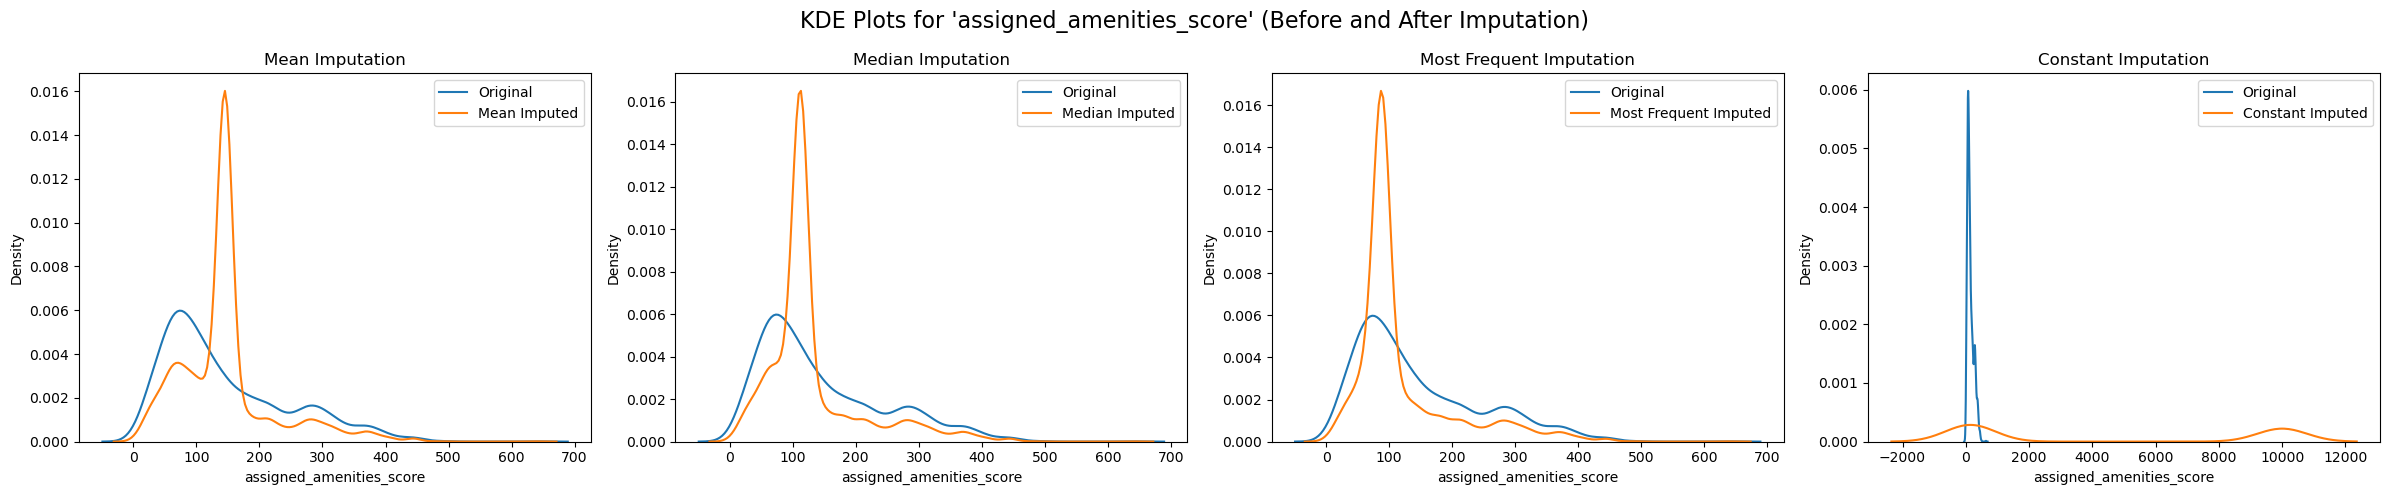

In [43]:
mean_imputed, median_imputed, most_frequent_imputed, constant_imputed = get_simple_imputations(X_train, 'assigned_amenities_score', constant_value=9999)
plot_kde_imputations(X_train, 'assigned_amenities_score')

`observation`
- After imputation distribution changes
- Use Advanced imputation techniques like KNN and Iterative imputer.

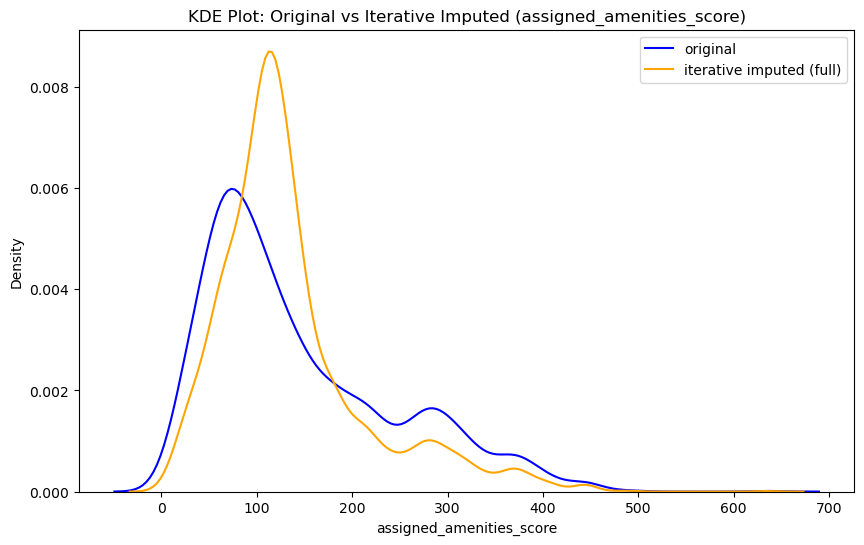

In [238]:
original_iter, data_iter_imputed = plot_iterative_imputation_kde(X_train, 'assigned_amenities_score')

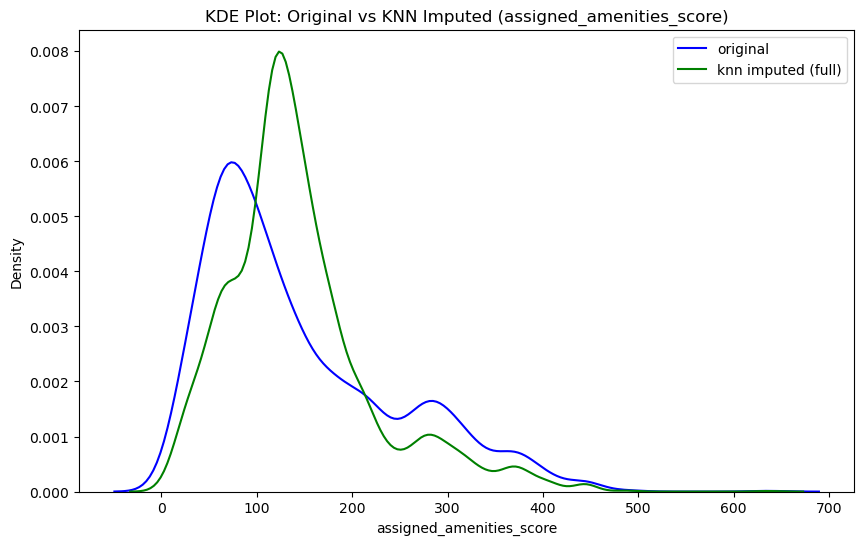

In [239]:
# Call function and capture output
original, data_knn_imputed = plot_knn_imputation_kde(X_train, 'assigned_amenities_score')

In [240]:
print("Original:\n", X_train['assigned_amenities_score'].dropna().describe(), "\n")
print("KNN Imputed:\n", data_knn_imputed['assigned_amenities_score'].describe(), "\n")
print("Iterative Imputed:\n", data_iter_imputed['assigned_amenities_score'].describe(), "\n")
print("Mean Imputed:\n", pd.Series(mean_imputed).describe(), "\n")
print("Median Imputed:\n", pd.Series(median_imputed).describe(), "\n")
print("Constant Imputed:\n", pd.Series(constant_imputed).describe(), "\n")
print("most_frequent Imputed:\n", pd.Series(most_frequent_imputed).describe(), "\n")

Original:
 count    5256.000000
mean      145.114726
std       100.362519
min         5.000000
25%        69.000000
50%       112.000000
75%       207.000000
max       635.000000
Name: assigned_amenities_score, dtype: float64 

KNN Imputed:
 count    9306.000000
mean      143.976424
std        78.212249
min         5.000000
25%        98.450000
50%       130.000000
75%       173.200000
max       635.000000
Name: assigned_amenities_score, dtype: float64 

Iterative Imputed:
 count    9306.000000
mean      135.586900
std        79.048770
min         5.000000
25%        88.000000
50%       117.938394
75%       156.351888
max       635.000000
Name: assigned_amenities_score, dtype: float64 

Mean Imputed:
 count    9306.000000
mean      145.114726
std        75.422292
min         5.000000
25%       101.000000
50%       145.114726
75%       145.114726
max       635.000000
dtype: float64 

Median Imputed:
 count    9306.000000
mean      130.703095
std        77.188685
min         5.000000
25%

`observation`

- Knn work slight better but KNN imputation distorting the original distribution hence use missing indicator and let the model learn from the missingness itself.
- use assign weightage and then missing indicator then keep the original col and apply KNN imputation and min max scaling  
- use models for imputation like Xgboost and LightGBM

## Analysis on ordinal_cat_cols

In [242]:
ordinal_cat_cols = ['status','construction','furnish']

#status : 'under construction < ongoing < ready to move'
#construction : 'under construction → new construction → less than 5 years → 5 to 10 years → 10 to 15 years → 15 to 20 years → above 20 years'
#furnish : 'unfurnished < semi-furnished < furnished'

### status

In [243]:
X_train['status'].value_counts()

status
ready to move         5787
under construction    3451
ongoing                  3
Name: count, dtype: int64

In [244]:
df['status'].isna().sum()

81

`observation`

- Imputation: Very few missing values and one dominant category ('ready to move'), hence we use mode.

In [245]:
# Mode imputation
X_train['status'] = X_train['status'].fillna(X_train['status'].mode()[0])

`observation`

- 1st apply mode and then ordinal encoding
- this is ordinal columns hence apply ordinal encoding or we can apply OHE  

### construction

In [246]:
X_train['construction'].isna().sum()

838

In [247]:
X_train['construction'].value_counts()

construction
under construction    3451
less than 5 years     1234
new construction      1180
5 to 10 years         1086
10 to 15 years         758
above 20 years         392
15 to 20 years         367
Name: count, dtype: int64

`observation`

- 'under construction' is the dominant category, but missing values are too many for mode imputation
- capture missingness by missing indicator by filling NaN values using 'missing' 

In [248]:
X_train["construction_missing"] = X_train["construction"].isna().astype(int)
X_train["construction"] = X_train["construction"].fillna("missing")

In [249]:
X_train[['construction_missing','construction']].head()

,construction_missing,construction
11624,1,missing
3102,0,new construction
2360,0,10 to 15 years
8978,0,new construction
11280,0,new construction


`observation`

- 1st apply missing indicator and then ordinal encoding
- this is ordinal columns hence apply ordinal encoding or we can apply OHE 

### furnish

In [250]:
X_train['furnish'].isna().sum()

31

In [251]:
X_train['furnish'].value_counts()

furnish
unfurnished       5797
semi-furnished    2546
furnished          932
Name: count, dtype: int64

`observation`

- Imputation: Very few missing values and one dominant category ('unfurnished'), hence we use mode.

In [252]:
# Mode imputation
X_train['furnish'] = X_train['furnish'].fillna(X_train['furnish'].mode()[0])

`observation`

- 1st apply mode and then ordinal encoding
- this is ordinal columns hence apply ordinal encoding or we can apply OHE 

# Imputation Pipeline 

so i have asked one question(on 23-7-25) to sir for clipping and once you get answer then make changes according to that and then ask chatgpt 
as which imputation is better by uploading graph and this also

this only a sample you have to put this below for orginal , KNN and iterative also    
 count    6512.000000  
mean        3.152906  
std         1.595011  
min         1.304996  
25%         2.621082  
50%         2.752291  
75%         3.100318  
max        15.646208  
Name: project_name, dtype: float64 


In [253]:
num_nominal_cols = ['project_in_acres','lattitude','longitude','area','costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km', 'transport_min_km',
                    'shopping_centre_mean_km', 'shopping_centre_min_km','commercial_hub_mean_km', 'commercial_hub_min_km','overall_min_mean_km', 'overall_avg_mean_km',
                    'overall_min_min_km', 'overall_avg_min_km','available_units','towers']

num_ordinal_cols = ['flat_on_floor','total_floor','bed','bath','balcony','lift','parking','education_within_2km','transport_within_2km','shopping_centre_within_2km',
                    'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

nominal_cat_cols = ['builder','project_name','location','city','property_type','ownership','overlooking','facing','flooring','extra_rooms','seller']

ordinal_cat_cols = ['status','construction','furnish']

`observation`
- one column has change from 'amenities' we make 'assigned_amenities_score' 

In [43]:
#sagregate columns as per all above imputations
features_to_fill_knn = ['project_in_acres','area','costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km',
                       'transport_min_km','shopping_centre_mean_km','shopping_centre_min_km','overall_min_mean_km', 'overall_avg_mean_km',
                       'overall_min_min_km', 'overall_avg_min_km','available_units','towers',
                       'flat_on_floor','total_floor','bath','parking',
                       'commercial_hub_mean_km','commercial_hub_min_km','balcony']
features_to_fill_iterative = ['lattitude','longitude']
features_to_fill_median = ['lift']
features_to_fill_mode = ['property_type','status','furnish']
features_to_fill_constant = ['ownership','facing','overlooking','extra_rooms']
features_to_add_missing_indicator = ['assigned_amenities_score','construction']

In [44]:
features_for_imputer_then_target_encoding = ['builder','project_name', 'location']
mode_and_then_OHE = ['property_type']
features_to_fill_constant_and_then_OHE = ['ownership','facing']
fillina_using_missing_and_then_use_MultiLabelBinarizer = ['overlooking','extra_rooms','flooring']
OHE = ['city','seller']
min_max_scaling = ['education_within_2km','transport_within_2km','shopping_centre_within_2km','commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

In [45]:
X_train.shape

(9306, 49)

In [46]:
for col in X_train.columns:
    print(col)

flooring
available_units
towers
construction
ownership
emi
bed
bath
parking
area
costpersqft
flat_on_floor
total_floor
lift
balcony
lattitude
longitude
project_in_acres
builder
project_name
furnish
city
location
property_type
status
extra_rooms
facing
seller
overlooking
education_mean_km
education_min_km
education_within_2km
transport_mean_km
transport_min_km
transport_within_2km
shopping_centre_mean_km
shopping_centre_min_km
shopping_centre_within_2km
commercial_hub_mean_km
commercial_hub_min_km
commercial_hub_within_2km
hospital_within_2km
tourist_within_2km
overall_min_mean_km
overall_avg_mean_km
overall_min_min_km
overall_avg_min_km
total_within_2km
assigned_amenities_score


In [47]:
# Custom transformer to keep top N categories, others → 'other'
class TopNCategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, top_n=200):
        self.top_n = top_n
        self.top_categories_ = None

    def fit(self, X, y=None):
        X_series = pd.Series(X.squeeze())
        self.top_categories_ = X_series.value_counts().nlargest(self.top_n).index
        return self

    def transform(self, X):
        X_series = pd.Series(X.squeeze())
        return X_series.apply(lambda x: x if x in self.top_categories_ else 'other').to_frame()

# Create preprocessing pipeline for one column
def get_categorical_pipeline():
    return Pipeline(steps=[
        ('impute_missing', SimpleImputer(strategy='constant', fill_value='missing')),
        ('top_200', TopNCategoricalEncoder(top_n=200)),
        ('target_encode', TargetEncoder())
    ])

# Define the columns to apply the pipeline on
cat_cols = ['builder', 'project_name', 'location']

# Create the column transformer
cat_transformer = ColumnTransformer(transformers=[
    (col + '_pipeline', get_categorical_pipeline(), [col]) for col in cat_cols
], remainder='passthrough')  # Set to 'drop' or 'passthrough' as needed


In [48]:
# define column groups
features_to_fill_knn = ['project_in_acres','area','costpersqft','emi', 'education_mean_km', 'education_min_km','transport_mean_km',
                       'transport_min_km','shopping_centre_mean_km','shopping_centre_min_km','overall_min_mean_km', 'overall_avg_mean_km',
                       'overall_min_min_km', 'overall_avg_min_km','available_units','towers',
                       'flat_on_floor','total_floor','bath','parking',
                       'commercial_hub_mean_km','commercial_hub_min_km','balcony']

features_to_fill_iterative = ['lattitude','longitude']

features_to_fill_median = ['lift']

features_to_fill_mode = ['property_type','status','furnish']

features_to_fill_constant = ['ownership','facing','overlooking','extra_rooms']

features_to_add_missing_indicator = ['assigned_amenities_score','construction']

# column transformer
preprocessor = ColumnTransformer(transformers=[
    ("knn_imputer", KNNImputer(n_neighbors=5), features_to_fill_knn),
    ("iterative_imputer", IterativeImputer(), features_to_fill_iterative),
    ("median_imputer", SimpleImputer(strategy="median"), features_to_fill_median),
    ("mode_imputer", SimpleImputer(strategy="most_frequent"), features_to_fill_mode),
    ("constant_imputer", SimpleImputer(strategy="constant", fill_value="missing"), features_to_fill_constant),
    ("missing_indicator", MissingIndicator(features="all"), features_to_add_missing_indicator),
    ("passthrough_indicated", "passthrough", features_to_add_missing_indicator)  # Keep original cols too
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

preprocessor

ColumnTransformer(n_jobs=-1, remainder='passthrough',
                  transformers=[('knn_imputer', KNNImputer(),
                                 ['project_in_acres', 'area', 'costpersqft',
                                  'emi', 'education_mean_km',
                                  'education_min_km', 'transport_mean_km',
                                  'transport_min_km', 'shopping_centre_mean_km',
                                  'shopping_centre_min_km',
                                  'overall_min_mean_km', 'overall_avg_mean_km',
                                  'overall_min_min_km', 'overall_avg_mi...
                                 SimpleImputer(strategy='most_frequent'),
                                 ['property_type', 'status', 'furnish']),
                                ('constant_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['ownership', 'facing', 'overlooking',
                                  'extra_rooms']),
                                ('missing_indicator',
                                 MissingIndicator(features='all'),
                                 ['construction']),
                                ('passthrough_indicated', 'passthrough',
                                 ['construction'])],
                  verbose_feature_names_out=False)

In [49]:
X_train.shape

(9306, 49)

In [51]:
X_train['construction'].isna().sum()

838

In [52]:
ordinal_cat_cols = ['status','furnish']

# Define explicit order for each ordinal column
ordinal_categories = [
    ['under construction', 'ongoing', 'ready to move'],  # status
    ['unfurnished', 'semi-furnished', 'furnished']  # furnish
]

ordinal_encoder = OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1)

ordinal_transformer = ColumnTransformer(transformers=[
    ("ordinal", ordinal_encoder, ordinal_cat_cols)
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

In [57]:
# Step 1: Column to encode
construction_ordinal_cat_col = ['construction']

# Step 2: Define order
ordinal_categories = [
    ['missing','under construction', 'new construction', 'less than 5 years', '5 to 10 years', '10 to 15 years', '15 to 20 years', 'above 20 years']
]

# Step 3: Pipeline for ordinal column
ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ordinal_encoder", OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Step 4: ColumnTransformer
construction_ordinal_transformer = ColumnTransformer(transformers=[
    ("construction_ordinal", ordinal_pipeline, construction_ordinal_cat_col)
], remainder="passthrough", n_jobs=-1, verbose_feature_names_out=False)

In [ ]:
# Step 1: Define the column
amenity_score_col = ['assigned_amenities_score']

# Step 2: Create imputation pipeline with constant -999
amenity_score_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=-999))
])

# Step 3: Create ColumnTransformer
amenity_score_transformer = ColumnTransformer(transformers=[
    ("assigned_amenity_imputer", amenity_score_pipeline, amenity_score_col)
], remainder="passthrough", verbose_feature_names_out=False, n_jobs=-1)

In [50]:
features_to_onehot_encode = ['property_type', 'ownership', 'facing', 'city', 'seller']

onehot_transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_to_onehot_encode)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

In [51]:
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoders = {}
        self.columns = []

    def fit(self, X, y=None):
        self.columns = X.columns
        for col in self.columns:
            mlb = MultiLabelBinarizer()
            split_data = X[col].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
            mlb.fit(split_data)
            self.encoders[col] = mlb
        return self

    def transform(self, X):
        output_parts = []
        for col in self.columns:
            mlb = self.encoders[col]
            split_data = X[col].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
            transformed = mlb.transform(split_data)
            col_names = [f"{col}_{cls}" for cls in mlb.classes_]
            output_parts.append(pd.DataFrame(transformed, columns=col_names, index=X.index))
        return pd.concat(output_parts, axis=1)

In [52]:
multilabel_cols = ['overlooking', 'extra_rooms','flooring']

multilabel_transformer = ColumnTransformer(
    transformers=[
        ('mlb', MultiLabelBinarizerTransformer(), multilabel_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)


In [53]:
min_max_scaling = ['education_within_2km','transport_within_2km','shopping_centre_within_2km','commercial_hub_within_2km','hospital_within_2km',
                   'tourist_within_2km','total_within_2km']


scaling_transformer = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), min_max_scaling)
    ],
    remainder='passthrough'  # optional: keep other columns unchanged
)


In [54]:
final_pipeline = Pipeline(steps=[
    ('target_encoding', target_encoder_transformer),
    ('imputation', preprocessor),
    ('ordinal encoding' , ordinal_transformer),
    ('construction ordinal encoding', construction_ordinal_transformer),
    ('amenities simpleimputer', amenity_score_transformer),
    ('onehot', onehot_transformer),
    ('multilabel', multilabel_transformer),
    ('minmaxscaler', scaling_transformer)
])
final_pipeline

Pipeline(steps=[('target_encoding',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('target_enc',
                                                  TargetEncoder(cols=['builder',
                                                                      'project_name',
                                                                      'location',
                                                                      'flooring'],
                                                                handle_missing='return_nan',
                                                                smoothing=0.3),
                                                  ['builder', 'project_name',
                                                   'location', 'flooring'])],
                                   verbose_feature_names_out=False)),
                ('imputation',
                 ColumnTransformer(n_jobs=-1, remaind...
                                                  MultiLabelBinarizerTransformer(),
                                                  ['overlooking',
                                                   'extra_rooms'])],
                                   verbose_feature_names_out=False)),
                ('minmaxscaler',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('minmax', MinMaxScaler(),
                                                  ['education_within_2km',
                                                   'transport_within_2km',
                                                   'shopping_centre_within_2km',
                                                   'commercial_hub_within_2km',
                                                   'hospital_within_2km',
                                                   'tourist_within_2km',
                                                   'total_within_2km'])]))])

In [55]:
# Fit-transform training data
X_train_trans = final_pipeline.fit_transform(X_train, y_train_trans)

In [58]:
X_train_trans.head()

,minmax__education_within_2km,minmax__transport_within_2km,minmax__shopping_centre_within_2km,minmax__commercial_hub_within_2km,minmax__hospital_within_2km,minmax__tourist_within_2km,minmax__total_within_2km,remainder__overlooking_garden/park,remainder__overlooking_main road,remainder__overlooking_missing,...,remainder__project_name,remainder__location,remainder__flooring,remainder__lattitude,remainder__longitude,remainder__lift,remainder__missingindicator_assigned_amenities_score,remainder__missingindicator_construction,remainder__assigned_amenities_score,remainder__bed
11624,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,0,1,...,8.683611e-13,-9.641945e-01,-0.000569,18.989401,73.117516,3.0,True,True,NaN,1.0
3102,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1,1,0,...,2.863244e-16,-1.506064e+00,-0.003361,19.399540,72.860416,3.0,False,False,157.0,1.0
2360,0.2,0.0,0.6,0.8,0.0,0.0,0.380952,0,0,1,...,2.863244e-16,-4.711468e-02,-0.003361,19.077063,72.884040,2.0,False,False,135.0,2.0
8978,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0,0,1,...,8.683611e-13,5.543158e-10,-0.003361,19.073199,72.863893,2.0,True,False,NaN,2.0
11280,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1,1,0,...,-2.100999e-02,7.403040e-01,-0.003361,19.119677,72.905081,3.0,True,False,NaN,1.0


In [61]:
print(X_train_trans.isna().sum()[X_train_trans.isna().sum() > 0])

remainder__assigned_amenities_score    4050
dtype: int64


In [56]:
from sklearn.linear_model import LinearRegression
# Model pipeline
model_pipe = Pipeline(steps=[
    ("preprocessing", final_pipeline),
    ("model", LinearRegression())
])

In [57]:
# Fit pipeline without error
model_pipe.fit(X_train, y_train_trans)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

# I have make total new format below 

In [32]:
X_train['id'].head()

KeyError: 'id'

In [43]:
# --- Custom MultiLabel Binarizer ---
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoders = {}
        self.columns = []

    def fit(self, X, y=None):
        self.columns = X.columns
        for col in self.columns:
            mlb = MultiLabelBinarizer()
            split_data = X[col].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
            mlb.fit(split_data)
            self.encoders[col] = mlb
        return self

    def transform(self, X):
        output_parts = []
        for col in self.columns:
            mlb = self.encoders[col]
            split_data = X[col].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
            transformed = mlb.transform(split_data)
            col_names = [f"{col}_{cls}" for cls in mlb.classes_]
            output_parts.append(pd.DataFrame(transformed, columns=col_names, index=X.index))
        return pd.concat(output_parts, axis=1)

In [44]:
# --- Custom Transformer: Top K Categories ---
class TopKCategoriesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, top_k=200):
        self.top_k = top_k
        self.top_categories_ = {}

    def fit(self, X, y=None):
        for col in X.columns:
            top = X[col].value_counts().nlargest(self.top_k).index
            self.top_categories_[col] = set(top)
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].where(X[col].isin(self.top_categories_[col]), other='__other__')
        return X

In [45]:
# --- Columns to Target Encode (after imputation and top-K) ---
target_encoding_cols = ['builder', 'project_name', 'location']

features_to_fill_knn = [
    'project_in_acres','area','costpersqft','emi', 'education_mean_km', 'education_min_km',
    'transport_mean_km','transport_min_km','shopping_centre_mean_km','shopping_centre_min_km',
    'overall_min_mean_km', 'overall_avg_mean_km','overall_min_min_km', 'overall_avg_min_km',
    'available_units','towers','flat_on_floor','total_floor','bath','parking',
    'commercial_hub_mean_km','commercial_hub_min_km','balcony'
] 

features_to_fill_iterative = ['lattitude','longitude']
features_to_fill_median = ['lift']
features_to_fill_mode = ['property_type','status','furnish']
features_to_fill_constant = ['ownership','facing','overlooking','extra_rooms','flooring']
features_to_add_missing_indicator = ['assigned_amenities_score','construction']

ordinal_cat_cols = ['status','furnish']
ordinal_categories = [
    ['under construction', 'ongoing', 'ready to move'],  # status
    ['unfurnished', 'semi-furnished', 'furnished']       # furnish
]

construction_ordinal_col = ['construction']
construction_categories = [['missing','under construction', 'new construction', 'less than 5 years',
                            '5 to 10 years', '10 to 15 years', '15 to 20 years', 'above 20 years']]

features_to_onehot_encode = ['property_type', 'ownership', 'facing', 'city', 'seller']
multilabel_cols = ['overlooking', 'extra_rooms','flooring']
min_max_scaling = ['education_within_2km','transport_within_2km','shopping_centre_within_2km',
                   'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

In [48]:
# --- Final Pipeline for Target Encoding Columns ---
builder_location_project_name_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ('top_k', TopKCategoriesTransformer(top_k=200)),
    ('target_encoder', TargetEncoder())
])

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

construction_ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ordinal_encoder", OrdinalEncoder(
        categories=construction_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

scaling_pipeline = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

# --- Unified Preprocessor ---
preprocessor = make_column_transformer(
    # Target Encoding
    (builder_location_project_name_pipeline, target_encoding_cols),

    # Imputation
    (KNNImputer(n_neighbors=5), features_to_fill_knn),
    (IterativeImputer(), features_to_fill_iterative),
    (SimpleImputer(strategy="median"), features_to_fill_median),
    (SimpleImputer(strategy="most_frequent"), features_to_fill_mode),
    (SimpleImputer(strategy="constant", fill_value="missing"), features_to_fill_constant),
    (MissingIndicator(features="all"), features_to_add_missing_indicator),
    ("passthrough", features_to_add_missing_indicator),

    # Ordinal Encoding
    (ordinal_encoder, ordinal_cat_cols),
    (construction_ordinal_pipeline, construction_ordinal_col),

    # One-hot Encoding
    (onehot_encoder, features_to_onehot_encode),
    
    # Multi-label Encoding
    (MultiLabelBinarizerTransformer(), multilabel_cols),

    # MinMax Scaling
    (scaling_pipeline, min_max_scaling),

    # Keep other columns
    remainder='passthrough',
    verbose_feature_names_out=False,
    n_jobs=-1
)

# --- Final Pipeline ---
final_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor)
])

In [49]:
# Fit-transform training data
X_train_trans = final_pipeline.fit_transform(X_train, y_train_trans)

ValueError: Duplicated feature names found before concatenating the outputs of the transformers: ['assigned_amenities_score', 'construction', 'furnish', 'status'].
Transformer simpleimputer-2 has conflicting columns names: ['furnish', 'status'].
Transformer passthrough has conflicting columns names: ['assigned_amenities_score', 'construction'].
Transformer ordinalencoder has conflicting columns names: ['furnish', 'status'].
Transformer pipeline-2 has conflicting columns names: ['construction'].
Transformer pipeline-3 has conflicting columns names: ['assigned_amenities_score'].
Either make sure that the transformers named above do not generate columns with conflicting names or set verbose_feature_names_out=True to automatically prefix to the output feature names with the name of the transformer to prevent any conflicting names.

In [ ]:
X_train_trans.head()

In [ ]:
print(X_train_trans.isna().sum()[X_train_trans.isna().sum() > 0])

In [47]:
from sklearn.linear_model import LinearRegression
# Model pipeline
model_pipe = Pipeline(steps=[
    ("preprocessing", final_pipeline),
    ("model", LinearRegression())
])

NameError: name 'final_pipeline' is not defined

In [48]:
# Fit pipeline without error
model_pipe.fit(X_train, y_train_trans)

NameError: name 'model_pipe' is not defined

# my own way 

'builder' - constant / top 200 / target encode   
'project_name' - constant / top 200 / target encode  
'location' - constant / top 200 / target encode  


'project_in_acres' - KNN Imputer    
'area' - KNN Imputer  
'costpersqft' - KNN Imputer  
'emi' - KNN Imputer  
'education_mean_km' - KNN Imputer  
'education_min_km' - KNN Imputer  
'transport_mean_km' - KNN Imputer  
'transport_min_km' - KNN Imputer  
'shopping_centre_mean_km' - KNN Imputer  
'shopping_centre_min_km' - KNN Imputer  
'overall_min_mean_km' - KNN Imputer  
'overall_avg_mean_km' - KNN Imputer  
'overall_min_min_km' - KNN Imputer  
'overall_avg_min_km' - KNN Imputer  
'available_units' - KNN Imputer  
'towers' - KNN Imputer  
'flat_on_floor' - KNN Imputer  
'total_floor' - KNN Imputer  
'bath' - KNN Imputer  
'parking' - KNN Imputer  
'commercial_hub_mean_km' - KNN Imputer  
'commercial_hub_min_km' - KNN Imputer  
'balcony' - KNN Imputer  

'lattitude' - iterative imputer   
'longitude' - iterative imputer   

'lift' - median  

'property_type' - mode / OHE  
'status' - mode / ordinal encoding  
'furnish' - mode / ordinal encoding  


'ownership' - constant / OHE  
'facing' - constant / OHE  
'overlooking' - constant / multilable  
'extra_rooms' - constant / multilable  
'flooring' - constant / multilable  


'assigned_amenities_score' -  missingindicator then KNNimputation and then min_max_scale
'construction' -  missingindicator and ordinal_encode

'city' - OHE  
'seller' - OHE  


'education_within_2km' - MinMax Scaling    
'transport_within_2km' - MinMax Scaling     
'shopping_centre_within_2km' - MinMax Scaling    
'commercial_hub_within_2km' - MinMax Scaling  
'hospital_within_2km' - MinMax Scaling  
'tourist_within_2km' - MinMax Scaling  
'total_within_2km' - MinMax Scaling  

In [33]:
# --- Custom MultiLabel Binarizer ---
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoders = {}
        self.columns = []

    def fit(self, X, y=None):
        self.columns = X.columns
        for col in self.columns:
            mlb = MultiLabelBinarizer()
            split_data = X[col].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
            mlb.fit(split_data)
            self.encoders[col] = mlb
        return self

    def transform(self, X):
        output_parts = []
        for col in self.columns:
            mlb = self.encoders[col]
            split_data = X[col].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
            transformed = mlb.transform(split_data)
            col_names = [f"{col}_{cls}" for cls in mlb.classes_]
            output_parts.append(pd.DataFrame(transformed, columns=col_names, index=X.index))
        return pd.concat(output_parts, axis=1)

In [34]:
# --- Custom Transformer: Top K Categories ---
class TopKCategoriesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, top_k=200):
        self.top_k = top_k
        self.top_categories_ = {}

    def fit(self, X, y=None):
        for col in X.columns:
            top = X[col].value_counts().nlargest(self.top_k).index
            self.top_categories_[col] = set(top)
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].where(X[col].isin(self.top_categories_[col]), other='__other__')
        return X

In [35]:
#final
amenities_weightages = {
    "sea facing": 10,
    "private pool": 10,
    "private jaccuzi": 10,
    "sky villa": 10,
    "helipad": 10,
    "wrap around balcony": 7,
    "infinity swimming pool": 10,
    "high ceiling": 9,
    "located in the heart of city": 10,
    "large open space": 10,
    "skyline view": 10,
    "private terrace/garden": 10,
    "private garage": 10,
    "mansion": 10,
    "club house": 9,
    "large clubhouse": 9,
    "modular kitchen": 9,
    "central ac": 9,
    "banquet hall": 6,
    "premium branded fittings": 9,
    "private garden": 9,
    "full glass wall": 9,
    "garden view": 9,
    "theme based architectures": 9,
    "grand entrance lobby": 9,
    "smart home": 9,
    "library and business centre": 9,
    "recreational pool": 9,
    "projector": 8,
    "swimming pool": 8,
    "gymnasium": 8,
    "indoor squash & badminton courts": 8,
    "outdoor tennis courts": 8,
    "cycling & jogging track": 8,
    "kids play pool with water slides": 8,
    "guest lobby in each floor": 8,
    "aesthetically designed landscape garden": 8,
    "health club with steam / jacuzzi": 8,
    "meditation area": 8,
    "pet park": 8,
    "visitor parking": 8,
    "badminton court": 8,
    "kids play area": 7,
    "community hall": 7,
    "power back up": 7,
    "cctv camera": 7,
    "rain water harvesting": 7,
    "internet/wi-fi connectivity": 7,
    "cycling track": 7,
    "art center": 7,
    "library": 7,
    "fire sprinklers": 7,
    "multipurpose hall": 7,
    "event space & amphitheatre": 7,
    "flower gardens": 6,
    "curated garden": 6,
    "multipurpose courts": 7,
    "dth television facility": 5,
    "fire fighting equipment": 6,
    "provision for power backup": 7,
    "sand pit": 6,
    "sewage treatment plant": 6,
    "solar energy": 7,
    "piped gas": 6,
    "kids club": 6,
    "waste disposal": 6,
    "lift": 5,
    "security": 5,
    "maintenance staff": 5,
    "reserved parking": 5,
    "ro water system": 5,
    "wheelchair accessibility": 5,
    "shopping center": 5,
    "laundry service": 5,
    "bank & atm": 5,
    "community entrance gate": 5,
    "canopy walk": 4,
    "entry exit gate": 4,
    "early learning centre": 4,
    "earth quake resistant": 7,
    "waste water recycling": 6,
    "whiteboard": 3,
    "printer": 3,
    "tea/coffee": 3,
    "house help accommodation": 7,
    "study room": 5,
    "ground water recharging": 5,
    "unknown": 0,
    "3 tier security system": 8,
    "ac in each room": 9,
    "activity deck4": 7,
    "aerobics room": 7,
    "air conditioned": 9,
    "all wooden flooring": 8,
    "arts & craft studio": 6,
    "bar/lounge": 7,
    "barbeque pit": 6,
    "barbeque space": 6,
    "cafeteria/food court": 7,
    "coffee lounge & restaurants": 7,
    "concierge services": 9,
    "conference room": 8,
    "cricket net practice": 6,
    "dance studio": 7,
    "downtown": 10,
    "fingerprint access": 8,
    "fireplace": 6,
    "golf course": 10,
    "hilltop": 10,
    "horticulture": 6,
    "indoor games room": 7,
    "island kitchen layout": 8,
    "jogging and strolling track": 7,
    "kids splash pool": 7,
    "lawn with pathway": 6,
    "guest accommodation":8,
    "marble flooring": 9,
    "mini cinema theatre": 9,
    "half basketball court":7,
    "park": 8,
    "pool with temperature control": 10,
    "intercom facility":6,
    "rentable community space": 6,
    "retail boulevard (retail shops)": 8,
    "service/goods lift": 6,
    "skydeck": 9,
    "vaastu compliant": 7,
    "volleyball court": 6,
    "water front": 10,
    "water storage": 5,
    "water treatment plant": 7,
    "wine cellar": 8
}

In [36]:
class AmenitiesScoreTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='amenities', weightages=None, output_column='assigned_amenities_score'):
        self.column = column
        self.weightages = weightages if weightages is not None else {}
        self.output_column = output_column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        def calculate_score(amenities_str):
            # if not isinstance(amenities_str, str):
            #     return 0
            # amenities_list = [a.strip().lower() for a in amenities_str.split(",")]
            # return round(sum(self.weightages.get(a, 0) for a in amenities_list), 2)
            amenities_types = [f.strip().lower() for f in amenities_str.split(",")]
            total_weight = sum(self.weightages.get(f, 0) for f in amenities_types)
            return round(total_weight, 2)

        # Calculate scores
        X[self.output_column] = X[self.column].apply(calculate_score)

        # Replace 0 with NaN
        X[self.output_column] = X[self.output_column].replace(0, pd.NA)
        X[self.output_column] = pd.to_numeric(X[self.output_column], errors='coerce')

        # Drop original amenities column
        X.drop(columns=[self.column], inplace=True)

        return X


In [37]:
# Add missing indicator
class MissingIndicatorAdder(BaseEstimator, TransformerMixin):
    def __init__(self, column='assigned_amenities_score'):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column + '_missing'] = X[self.column].isna().astype(int)
        return X

In [38]:
# KNN imputation + MinMax scaling
class ImputeAndScaleAmenity(BaseEstimator, TransformerMixin):
    def __init__(self, column='assigned_amenities_score', n_neighbors=5):
        self.column = column
        self.n_neighbors = n_neighbors
        self.imputer = KNNImputer(n_neighbors=n_neighbors)
        self.scaler = MinMaxScaler()

    def fit(self, X, y=None):
        # Fit on the original column
        self.imputer.fit(X[[self.column]])
        imputed = self.imputer.transform(X[[self.column]])
        self.scaler.fit(imputed)
        return self

    def transform(self, X):
        X = X.copy()
        # Impute and scale the column
        imputed = self.imputer.transform(X[[self.column]])
        scaled = self.scaler.transform(imputed)
        # Replace with scaled
        X[self.column] = scaled
        return X

In [39]:
# Custom Ordinal Encoder Wrapper (for single column)
class ConstructionOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, column='construction', categories=None):
        self.column = column
        self.categories = categories
        self.encoder = OrdinalEncoder(categories=self.categories, handle_unknown='use_encoded_value', unknown_value=-1)

    def fit(self, X, y=None):
        self.encoder.fit(X[[self.column]])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = self.encoder.transform(X[[self.column]])
        return X

In [40]:
impute_topk_target_encoding_cols = ['builder', 'project_name', 'location']

features_to_fill_knn = [
    'project_in_acres','area','costpersqft','emi', 'education_mean_km', 'education_min_km',
    'transport_mean_km','transport_min_km','shopping_centre_mean_km','shopping_centre_min_km',
    'overall_min_mean_km', 'overall_avg_mean_km','overall_min_min_km', 'overall_avg_min_km',
    'available_units','towers','flat_on_floor','total_floor','bath','parking',
    'commercial_hub_mean_km','commercial_hub_min_km','balcony'
] 

features_to_fill_iterative = ['lattitude','longitude']
features_to_fill_median = ['lift']

impute_mf_and_OHE = ['property_type']

impute_mf_and_ordinal_encode = ['status','furnish']
ordinal_categories = [
    ['under construction', 'ongoing', 'ready to move'],  # status
    ['unfurnished', 'semi-furnished', 'furnished']       # furnish
]

impute_missing_and_OHE = ['ownership', 'facing']

impute_missing_and_multilable = ['overlooking','extra_rooms','flooring']

assignweight_missingindicator_KNNimputation_minmaxscale = ['amenities']

missingindicator_ordinal_encode = ['construction']
construction_categories = [[
    'missing', 'under construction', 'new construction', 'less than 5 years',
    '5 to 10 years', '10 to 15 years', '15 to 20 years', 'above 20 years'
]]

onehotencode = ['city','seller']

min_max_scaling = ['education_within_2km','transport_within_2km','shopping_centre_within_2km',
                   'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

In [41]:
# --- Final Pipeline for Target Encoding Columns ---
builder_location_project_name_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ('top_k', TopKCategoriesTransformer(top_k=200)),
    ('target_encoder', TargetEncoder())
])

property_type_pipeline = Pipeline(steps=[
    ('impute' , SimpleImputer(strategy="most_frequent")),
    ('OHE', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


status_furnish_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('ordinal encode', OrdinalEncoder(categories=ordinal_categories,handle_unknown='use_encoded_value',unknown_value=-1 ))
])


ownership_facing_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="constant", fill_value="missing")),
    ('OHE', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

overlooking_extra_rooms_flooring_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="constant", fill_value="missing")),
    ('multilable', MultiLabelBinarizerTransformer())
])

assigned_amenities_pipeline = Pipeline(steps=[
    ('calculate_score', AmenitiesScoreTransformer(
        column='amenities',
        weightages=amenities_weightages,
        output_column='assigned_amenities_score'
    )),
    ('add_missing_indicator', MissingIndicatorAdder(column='assigned_amenities_score')),
    ('impute_and_scale', ImputeAndScaleAmenity(column='assigned_amenities_score', n_neighbors=5))
])

construction_pipeline = Pipeline(steps=[
    ('add_missing_indicator', MissingIndicatorAdder(column='construction')),
    ('ordinal_encode', ConstructionOrdinalEncoder(column='construction', categories=construction_categories))
])

city_seller_pipeline = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

within2km_pipeline = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

# --- Unified Preprocessor ---
preprocessor = make_column_transformer(
    # impute_constant=missing, topK and Target Encoding
    (builder_location_project_name_pipeline, impute_topk_target_encoding_cols),

    # Imputation
    (KNNImputer(n_neighbors=5), features_to_fill_knn),
    (IterativeImputer(), features_to_fill_iterative),
    (SimpleImputer(strategy="median"), features_to_fill_median),

    # impute = most_frequent and OHE 
    (property_type_pipeline, impute_mf_and_OHE),

    #impute = most_frequent and ordinal encoding
    (status_furnish_pipeline, impute_mf_and_ordinal_encode),

    #impute_constant=missing and OHE
    (ownership_facing_pipeline, impute_missing_and_OHE),

    #impute_constant=missing and multilable
    (overlooking_extra_rooms_flooring_pipeline, impute_missing_and_multilable),

    #missingindicator then KNNimputation and then min_max_scale
    (assigned_amenities_pipeline, assignweight_missingindicator_KNNimputation_minmaxscale),

    #missingindicator and ordinal_encode
    (construction_pipeline, missingindicator_ordinal_encode),

    # onehot_encoder
    (city_seller_pipeline, onehotencode),

    # MinMax Scaling
    (within2km_pipeline, min_max_scaling),

    # Keep other columns
    remainder='passthrough',
    verbose_feature_names_out=False,
    n_jobs=-1
)

# --- Final Pipeline ---
final_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor)
])

In [42]:
# Fit-transform training data
X_train_trans = final_pipeline.fit_transform(X_train, y_train_trans)

In [43]:
X_train_trans.head()

,builder,project_name,location,project_in_acres,area,costpersqft,emi,education_mean_km,education_min_km,transport_mean_km,...,seller_person,seller_realestateagent,education_within_2km,transport_within_2km,shopping_centre_within_2km,commercial_hub_within_2km,hospital_within_2km,tourist_within_2km,total_within_2km,bed
11624,-0.278303,-0.329628,-0.964194,2.8000,638.0,5016.0,0.14,6.942000,6.44,0.66002,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0
3102,-0.203338,-0.047929,-1.253073,1.5941,408.0,8885.0,0.16,10.200000,10.20,11.50000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0
2360,0.082545,-0.047929,-0.025938,34.0000,657.0,30441.0,0.90,4.533333,0.70,3.74001,...,0.0,1.0,0.2,0.0,0.6,0.8,0.0,0.0,0.380952,2.0
8978,-0.278303,-0.329628,0.095295,4.2000,730.0,35616.0,1.17,2.996000,2.16,3.19002,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2.0
11280,-0.278303,-0.329628,0.740304,14.4000,405.0,20000.0,0.37,3.650000,1.60,1.07004,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0


In [44]:
print(X_train_trans.isna().sum()[X_train_trans.isna().sum() > 0])

Series([], dtype: int64)


In [45]:
from sklearn.linear_model import LinearRegression
# Model pipeline
model_pipe = Pipeline(steps=[
    ("preprocessing", final_pipeline),
    ("model", LinearRegression())
])

In [46]:
# Fit pipeline without error
model_pipe.fit(X_train, y_train_trans)

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('preprocessing',
                                  ColumnTransformer(n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(fill_value='missing',
                                                                                                  strategy='constant')),
                                                                                   ('top_k',
                                                                                    TopKCategoriesTransformer()),
                                                                                   ('target_encoder',
                                                                                    TargetEncoder())]),
                                                                   ['builder',
                                                                    'project_name',
                                                                    'location']),
                                                                  ('knni...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False),
                                                                   ['city',
                                                                    'seller']),
                                                                  ('pipeline-8',
                                                                   Pipeline(steps=[('scaler',
                                                                                    MinMaxScaler())]),
                                                                   ['education_within_2km',
                                                                    'transport_within_2km',
                                                                    'shopping_centre_within_2km',
                                                                    'commercial_hub_within_2km',
                                                                    'hospital_within_2km',
                                                                    'tourist_within_2km',
                                                                    'total_within_2km'])],
                                                    verbose_feature_names_out=False))])),
                ('model', LinearRegression())])

In [47]:
# get the predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred_test)

2.8592558502253858

In [49]:
X_test.head()

,flooring,available_units,towers,construction,ownership,emi,bed,bath,parking,area,...,commercial_hub_min_km,commercial_hub_within_2km,hospital_within_2km,tourist_within_2km,overall_min_mean_km,overall_avg_mean_km,overall_min_min_km,overall_avg_min_km,total_within_2km,amenities
3264,vitrified,100.0,1.0,under construction,freehold,2.28,5.0,5.0,4.0,1687.0,...,9.4,0,0,0,7.5,8.844444,1.6,4.933333,1,"cafeteria/food court, jogging and strolling tr..."
11493,"granite, marble, vitrified",NaN,NaN,under construction,freehold,1.80,4.0,4.0,2.0,1408.0,...,NaN,0,0,0,NaN,NaN,NaN,NaN,0,
9845,NaN,250.0,8.0,5 to 10 years,freehold,1.42,3.0,3.0,NaN,1150.0,...,NaN,0,0,0,NaN,NaN,NaN,NaN,0,"club house, swimming pool, lift, security, fir..."
9331,vitrified,148.0,2.0,5 to 10 years,co-operative society,0.50,2.0,2.0,1.0,700.0,...,10.7,0,1,0,0.9,6.433333,0.9,4.980000,3,"lift, park, reserved parking, maintenance staf..."
4087,NaN,NaN,NaN,NaN,NaN,0.09,1.0,1.0,NaN,550.0,...,NaN,0,0,0,NaN,NaN,NaN,NaN,0,


# This code is to be used in a VS Code script

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split



from sklearn.preprocessing import PowerTransformer, OneHotEncoder, MultiLabelBinarizer, OrdinalEncoder, MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer, MissingIndicator
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import make_column_transformer

In [2]:
#Here, I used the data saved using VS Code. This data has 184 columns, which means it is the result of merging df and am_df.
df = pd.read_csv(r'C:\Users\ABC\Desktop/bhushan/property_project/files_vscode/data/py_cleaned_data.csv')

C:\Users\ABC\AppData\Local\Temp\ipykernel_9628\610101231.py:2: DtypeWarning: Columns (106,128,134,135,136,137,138,139) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\ABC\Desktop/bhushan/property_project/files_vscode/data/py_cleaned_data.csv')


In [3]:
# drop columns not required for model input 
columns_to_drop = ['id','price_category']

df.drop(columns = columns_to_drop , inplace = True)

In [4]:
# combine all amenities and make one column
# Step 1: Filter columns that start with 'am_'
am_cols = [col for col in df.columns if col.startswith('am_')]

# Step 2: Combine values row-wise into a comma-separated string (not a list)
df['amenities'] = df[am_cols].apply(
    lambda row: ', '.join([str(val).strip() for val in row if isinstance(val, str) and val.strip() != ""]),
    axis=1
)

In [5]:
# Step 3: Drop original 'am_' columns
df.drop(columns=am_cols, inplace=True)

In [6]:
#drop duplicate rows 
df.drop_duplicates(inplace=True)

# Data preparation 

In [7]:
temp_df = df.copy()

In [8]:
# split data 

X = temp_df.drop(columns = 'price')
y = temp_df['price']

In [9]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (9306, 49)
The shape of test data is (2327, 49)


`lets categorized the columns`

# Transform Target column

In [11]:
pt = PowerTransformer(method='yeo-johnson')
y_train_trans = pd.Series(
    pt.fit_transform(y_train.values.reshape(-1, 1)).ravel(),
    index=y_train.index
)
y_test_trans = pd.Series(
    pt.transform(y_test.values.reshape(-1, 1)).ravel(),
    index=y_test.index
)

In [12]:
#o/p in daraframe
from sklearn import set_config
set_config(transform_output="pandas")

In [13]:
# --- Custom MultiLabel Binarizer ---
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoders = {}
        self.columns = []

    def fit(self, X, y=None):
        self.columns = X.columns
        for col in self.columns:
            mlb = MultiLabelBinarizer()
            split_data = X[col].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
            mlb.fit(split_data)
            self.encoders[col] = mlb
        return self

    def transform(self, X):
        output_parts = []
        for col in self.columns:
            mlb = self.encoders[col]
            split_data = X[col].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
            transformed = mlb.transform(split_data)
            col_names = [f"{col}_{cls}" for cls in mlb.classes_]
            output_parts.append(pd.DataFrame(transformed, columns=col_names, index=X.index))
        return pd.concat(output_parts, axis=1)

In [14]:
# --- Custom Transformer: Top K Categories ---
class TopKCategoriesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, top_k=200):
        self.top_k = top_k
        self.top_categories_ = {}

    def fit(self, X, y=None):
        for col in X.columns:
            top = X[col].value_counts().nlargest(self.top_k).index
            self.top_categories_[col] = set(top)
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            X[col] = X[col].where(X[col].isin(self.top_categories_[col]), other='__other__')
        return X

In [15]:
#final
amenities_weightages = {
    "sea facing": 10,
    "private pool": 10,
    "private jaccuzi": 10,
    "sky villa": 10,
    "helipad": 10,
    "wrap around balcony": 7,
    "infinity swimming pool": 10,
    "high ceiling": 9,
    "located in the heart of city": 10,
    "large open space": 10,
    "skyline view": 10,
    "private terrace/garden": 10,
    "private garage": 10,
    "mansion": 10,
    "club house": 9,
    "large clubhouse": 9,
    "modular kitchen": 9,
    "central ac": 9,
    "banquet hall": 6,
    "premium branded fittings": 9,
    "private garden": 9,
    "full glass wall": 9,
    "garden view": 9,
    "theme based architectures": 9,
    "grand entrance lobby": 9,
    "smart home": 9,
    "library and business centre": 9,
    "recreational pool": 9,
    "projector": 8,
    "swimming pool": 8,
    "gymnasium": 8,
    "indoor squash & badminton courts": 8,
    "outdoor tennis courts": 8,
    "cycling & jogging track": 8,
    "kids play pool with water slides": 8,
    "guest lobby in each floor": 8,
    "aesthetically designed landscape garden": 8,
    "health club with steam / jacuzzi": 8,
    "meditation area": 8,
    "pet park": 8,
    "visitor parking": 8,
    "badminton court": 8,
    "kids play area": 7,
    "community hall": 7,
    "power back up": 7,
    "cctv camera": 7,
    "rain water harvesting": 7,
    "internet/wi-fi connectivity": 7,
    "cycling track": 7,
    "art center": 7,
    "library": 7,
    "fire sprinklers": 7,
    "multipurpose hall": 7,
    "event space & amphitheatre": 7,
    "flower gardens": 6,
    "curated garden": 6,
    "multipurpose courts": 7,
    "dth television facility": 5,
    "fire fighting equipment": 6,
    "provision for power backup": 7,
    "sand pit": 6,
    "sewage treatment plant": 6,
    "solar energy": 7,
    "piped gas": 6,
    "kids club": 6,
    "waste disposal": 6,
    "lift": 5,
    "security": 5,
    "maintenance staff": 5,
    "reserved parking": 5,
    "ro water system": 5,
    "wheelchair accessibility": 5,
    "shopping center": 5,
    "laundry service": 5,
    "bank & atm": 5,
    "community entrance gate": 5,
    "canopy walk": 4,
    "entry exit gate": 4,
    "early learning centre": 4,
    "earth quake resistant": 7,
    "waste water recycling": 6,
    "whiteboard": 3,
    "printer": 3,
    "tea/coffee": 3,
    "house help accommodation": 7,
    "study room": 5,
    "ground water recharging": 5,
    "unknown": 0,
    "3 tier security system": 8,
    "ac in each room": 9,
    "activity deck4": 7,
    "aerobics room": 7,
    "air conditioned": 9,
    "all wooden flooring": 8,
    "arts & craft studio": 6,
    "bar/lounge": 7,
    "barbeque pit": 6,
    "barbeque space": 6,
    "cafeteria/food court": 7,
    "coffee lounge & restaurants": 7,
    "concierge services": 9,
    "conference room": 8,
    "cricket net practice": 6,
    "dance studio": 7,
    "downtown": 10,
    "fingerprint access": 8,
    "fireplace": 6,
    "golf course": 10,
    "hilltop": 10,
    "horticulture": 6,
    "indoor games room": 7,
    "island kitchen layout": 8,
    "jogging and strolling track": 7,
    "kids splash pool": 7,
    "lawn with pathway": 6,
    "guest accommodation":8,
    "marble flooring": 9,
    "mini cinema theatre": 9,
    "half basketball court":7,
    "park": 8,
    "pool with temperature control": 10,
    "intercom facility":6,
    "rentable community space": 6,
    "retail boulevard (retail shops)": 8,
    "service/goods lift": 6,
    "skydeck": 9,
    "vaastu compliant": 7,
    "volleyball court": 6,
    "water front": 10,
    "water storage": 5,
    "water treatment plant": 7,
    "wine cellar": 8
}

In [16]:
class AmenitiesScoreTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='amenities', weightages=None, output_column='assigned_amenities_score'):
        self.column = column
        self.weightages = weightages if weightages is not None else {}
        self.output_column = output_column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        def calculate_score(amenities_str):
            # if not isinstance(amenities_str, str):
            #     return 0
            # amenities_list = [a.strip().lower() for a in amenities_str.split(",")]
            # return round(sum(self.weightages.get(a, 0) for a in amenities_list), 2)
            amenities_types = [f.strip().lower() for f in amenities_str.split(",")]
            total_weight = sum(self.weightages.get(f, 0) for f in amenities_types)
            return round(total_weight, 2)

        # Calculate scores
        X[self.output_column] = X[self.column].apply(calculate_score)

        # Replace 0 with NaN
        X[self.output_column] = X[self.output_column].replace(0, pd.NA)
        X[self.output_column] = pd.to_numeric(X[self.output_column], errors='coerce')

        # Drop original amenities column
        X.drop(columns=[self.column], inplace=True)

        return X


In [17]:
# Add missing indicator
class MissingIndicatorAdder(BaseEstimator, TransformerMixin):
    def __init__(self, column='assigned_amenities_score'):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column + '_missing'] = X[self.column].isna().astype(int)
        return X

In [18]:
# KNN imputation + MinMax scaling
class ImputeAndScaleAmenity(BaseEstimator, TransformerMixin):
    def __init__(self, column='assigned_amenities_score', n_neighbors=5):
        self.column = column
        self.n_neighbors = n_neighbors
        self.imputer = KNNImputer(n_neighbors=n_neighbors)
        self.scaler = MinMaxScaler()

    def fit(self, X, y=None):
        # Fit on the original column
        self.imputer.fit(X[[self.column]])
        imputed = self.imputer.transform(X[[self.column]])
        self.scaler.fit(imputed)
        return self

    def transform(self, X):
        X = X.copy()
        # Impute and scale the column
        imputed = self.imputer.transform(X[[self.column]])
        scaled = self.scaler.transform(imputed)
        # Replace with scaled
        X[self.column] = scaled
        return X

In [19]:
# Custom Ordinal Encoder Wrapper (for single column)
class ConstructionOrdinalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, column='construction', categories=None):
        self.column = column
        self.categories = categories
        self.encoder = OrdinalEncoder(categories=self.categories, handle_unknown='use_encoded_value', unknown_value=-1)

    def fit(self, X, y=None):
        self.encoder.fit(X[[self.column]])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = self.encoder.transform(X[[self.column]])
        return X

In [20]:
impute_topk_target_encoding_cols = ['builder', 'project_name', 'location']

features_to_fill_knn = [
    'project_in_acres','area','costpersqft','emi', 'education_mean_km', 'education_min_km',
    'transport_mean_km','transport_min_km','shopping_centre_mean_km','shopping_centre_min_km',
    'overall_min_mean_km', 'overall_avg_mean_km','overall_min_min_km', 'overall_avg_min_km',
    'available_units','towers','flat_on_floor','total_floor','bath','parking',
    'commercial_hub_mean_km','commercial_hub_min_km','balcony'
] 

features_to_fill_iterative = ['lattitude','longitude']
features_to_fill_median = ['lift']

impute_mf_and_OHE = ['property_type']

impute_mf_and_ordinal_encode = ['status','furnish']
ordinal_categories = [
    ['under construction', 'ongoing', 'ready to move'],  # status
    ['unfurnished', 'semi-furnished', 'furnished']       # furnish
]

impute_missing_and_OHE = ['ownership', 'facing']

impute_missing_and_multilable = ['overlooking','extra_rooms','flooring']

assignweight_missingindicator_KNNimputation_minmaxscale = ['amenities']

missingindicator_ordinal_encode = ['construction']
construction_categories = [[
    'missing', 'under construction', 'new construction', 'less than 5 years',
    '5 to 10 years', '10 to 15 years', '15 to 20 years', 'above 20 years'
]]

onehotencode = ['city','seller']

min_max_scaling = ['education_within_2km','transport_within_2km','shopping_centre_within_2km',
                   'commercial_hub_within_2km','hospital_within_2km','tourist_within_2km','total_within_2km']

In [21]:
# --- Final Pipeline for Target Encoding Columns ---
builder_location_project_name_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ('top_k', TopKCategoriesTransformer(top_k=200)),
    ('target_encoder', TargetEncoder())
])

property_type_pipeline = Pipeline(steps=[
    ('impute' , SimpleImputer(strategy="most_frequent")),
    ('OHE', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


status_furnish_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('ordinal encode', OrdinalEncoder(categories=ordinal_categories,handle_unknown='use_encoded_value',unknown_value=-1 ))
])


ownership_facing_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="constant", fill_value="missing")),
    ('OHE', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

overlooking_extra_rooms_flooring_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="constant", fill_value="missing")),
    ('multilable', MultiLabelBinarizerTransformer())
])

assigned_amenities_pipeline = Pipeline(steps=[
    ('calculate_score', AmenitiesScoreTransformer(
        column='amenities',
        weightages=amenities_weightages,
        output_column='assigned_amenities_score'
    )),
    ('add_missing_indicator', MissingIndicatorAdder(column='assigned_amenities_score')),
    ('impute_and_scale', ImputeAndScaleAmenity(column='assigned_amenities_score', n_neighbors=5))
])

construction_pipeline = Pipeline(steps=[
    ('add_missing_indicator', MissingIndicatorAdder(column='construction')),
    ('ordinal_encode', ConstructionOrdinalEncoder(column='construction', categories=construction_categories))
])

city_seller_pipeline = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

within2km_pipeline = Pipeline(steps=[
    ("scaler", MinMaxScaler())
])

# --- Unified Preprocessor ---
preprocessor = make_column_transformer(
    # impute_constant=missing, topK and Target Encoding
    (builder_location_project_name_pipeline, impute_topk_target_encoding_cols),

    # Imputation
    (KNNImputer(n_neighbors=5), features_to_fill_knn),
    (IterativeImputer(), features_to_fill_iterative),
    (SimpleImputer(strategy="median"), features_to_fill_median),

    # impute = most_frequent and OHE 
    (property_type_pipeline, impute_mf_and_OHE),

    #impute = most_frequent and ordinal encoding
    (status_furnish_pipeline, impute_mf_and_ordinal_encode),

    #impute_constant=missing and OHE
    (ownership_facing_pipeline, impute_missing_and_OHE),

    #impute_constant=missing and multilable
    (overlooking_extra_rooms_flooring_pipeline, impute_missing_and_multilable),

    #missingindicator then KNNimputation and then min_max_scale
    (assigned_amenities_pipeline, assignweight_missingindicator_KNNimputation_minmaxscale),

    #missingindicator and ordinal_encode
    (construction_pipeline, missingindicator_ordinal_encode),

    # onehot_encoder
    (city_seller_pipeline, onehotencode),

    # MinMax Scaling
    (within2km_pipeline, min_max_scaling),

    # Keep other columns
    remainder='passthrough',
    verbose_feature_names_out=False,
    n_jobs=-1
)

# --- Final Pipeline ---
final_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor)
])

In [22]:
# Fit-transform training data
X_train_trans = final_pipeline.fit_transform(X_train, y_train_trans)

In [23]:
X_train_trans.head()

,builder,project_name,location,project_in_acres,area,costpersqft,emi,education_mean_km,education_min_km,transport_mean_km,...,seller_person,seller_realestateagent,education_within_2km,transport_within_2km,shopping_centre_within_2km,commercial_hub_within_2km,hospital_within_2km,tourist_within_2km,total_within_2km,bed
11624,-0.278303,-0.329628,-0.964194,2.8000,638.0,5016.0,0.14,6.942000,6.44,0.66002,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0
3102,-0.203338,-0.047929,-1.253073,1.5941,408.0,8885.0,0.16,10.200000,10.20,11.50000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0
2360,0.082545,-0.047929,-0.025938,34.0000,657.0,30441.0,0.90,4.533333,0.70,3.74001,...,0.0,1.0,0.2,0.0,0.6,0.8,0.0,0.0,0.380952,2.0
8978,-0.278303,-0.329628,0.095295,4.2000,730.0,35616.0,1.17,2.996000,2.16,3.19002,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2.0
11280,-0.278303,-0.329628,0.740304,14.4000,405.0,20000.0,0.37,3.650000,1.60,1.07004,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0


In [24]:
print(X_train_trans.isna().sum()[X_train_trans.isna().sum() > 0])

Series([], dtype: int64)


In [31]:
from sklearn.linear_model import LinearRegression
# Model pipeline
model_pipe = Pipeline(steps=[
    ("preprocessing", final_pipeline),
    ("model", LinearRegression())
])

In [32]:
# Fit pipeline without error
model_pipe.fit(X_train, y_train_trans)

C:\Users\ABC\AppData\Roaming\Python\Python312\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('preprocessing',
                                  ColumnTransformer(n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('pipeline-1',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(fill_value='missing',
                                                                                                  strategy='constant')),
                                                                                   ('top_k',
                                                                                    TopKCategoriesTransformer()),
                                                                                   ('target_encoder',
                                                                                    TargetEncoder())]),
                                                                   ['builder',
                                                                    'project_name',
                                                                    'location']),
                                                                  ('knni...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False),
                                                                   ['city',
                                                                    'seller']),
                                                                  ('pipeline-8',
                                                                   Pipeline(steps=[('scaler',
                                                                                    MinMaxScaler())]),
                                                                   ['education_within_2km',
                                                                    'transport_within_2km',
                                                                    'shopping_centre_within_2km',
                                                                    'commercial_hub_within_2km',
                                                                    'hospital_within_2km',
                                                                    'tourist_within_2km',
                                                                    'total_within_2km'])],
                                                    verbose_feature_names_out=False))])),
                ('model', LinearRegression())])

In [33]:
# get the predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [34]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test,y_pred_test)

2.8592558502253858

In [30]:
X_test.head()

,flooring,available_units,towers,construction,ownership,emi,bed,bath,parking,area,...,commercial_hub_min_km,commercial_hub_within_2km,hospital_within_2km,tourist_within_2km,overall_min_mean_km,overall_avg_mean_km,overall_min_min_km,overall_avg_min_km,total_within_2km,amenities
3264,vitrified,100.0,1.0,under construction,freehold,2.28,5.0,5.0,4.0,1687.0,...,9.4,0,0,0,7.5,8.844444,1.6,4.933333,1,"cafeteria/food court, jogging and strolling tr..."
11493,"granite, marble, vitrified",NaN,NaN,under construction,freehold,1.80,4.0,4.0,2.0,1408.0,...,NaN,0,0,0,NaN,NaN,NaN,NaN,0,
9845,NaN,250.0,8.0,5 to 10 years,freehold,1.42,3.0,3.0,NaN,1150.0,...,NaN,0,0,0,NaN,NaN,NaN,NaN,0,"club house, swimming pool, lift, security, fir..."
9331,vitrified,148.0,2.0,5 to 10 years,co-operative society,0.50,2.0,2.0,1.0,700.0,...,10.7,0,1,0,0.9,6.433333,0.9,4.980000,3,"lift, park, reserved parking, maintenance staf..."
4087,NaN,NaN,NaN,NaN,NaN,0.09,1.0,1.0,NaN,550.0,...,NaN,0,0,0,NaN,NaN,NaN,NaN,0,
